<b>Student Name:</b> Leung Chi Wah<br>
<b>Student ID:</b> S4126658<br>
<b>Course:</b> Case Studies in Data Science<br>
<b>Assignment:</b> Individual Task Part 1</br>

## 0. System Requirements

Environment: Python 3 and Jupyter notebook

Libraries used: 
* pandas
* re
* numpy
* os
* Path
* RegexpTokenizer
* sent_tokenize
* chain
* nltk.probability

In [1]:
# importing relevant libraries to complete all tasks
import pandas as pd
import numpy as np
import re
import os
import math
from pathlib import Path
import matplotlib.pyplot as plt 
import seaborn as sns
import ipaddress
from pandas.plotting import scatter_matrix 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle
from sklearn.tree import DecisionTreeClassifier 
from sklearn import metrics 
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
import time
from xgboost import XGBClassifier

## 1. Abstract


## 2. Research Question

Given that this job is a Data Scientist in Risk Manamgement Department from a banking industry, finanical crime domain is a common topic, especially fraud identification. Yet, in reality, the amount of transactions in one bank is huge while the tranasctions classified as fraud are extremely few. Also, different machine learning algorithms have different performance in terms of efficiency and accurancy. In order to balance statistical performance against the operational speed required to catch a transaction in near real-time, the research question is "What is the trade-off between computational efficiency (training/inference time) and classification accuracy when deploying Decision Tree versus XGBoost for fraud detection with handling extreme class imbalance?"

## 3. Identify and Retrieve Data

Twoo open-source data sets are found from Kaggle that are suitable for this research question.

<b>Data Set 1: Financial Transactions Dataset for Fraud Detection</b>
<br>Link: https://www.kaggle.com/datasets/aryan208/financial-transactions-dataset-for-fraud-detection
<br>This data set consists of 5,000,000 system-generated financial transactions that simulate real-world financial behaviour. Each row refers to a single transaction mapped across 18 columns, which can be categorized into 4 types, including transaction details , behavioural features, metadata and fraud indicator. There are no real user data and all is anonymous. Fraud indicators are determined based on the realistic rules inspired by common fraud detection patterns. For instance, a possible laundering case is customer having a large amount of transfer plus geographical shift

<b>Data Set 2: Banking Fraud Detection Dataset</b>
<br>Link: https://www.kaggle.com/datasets/zahranusratt/banking-fraud-detection-dataset
<br>This data set consists of 50,000 banking transactions which aims to support fraud detection and financial risk analysis in the banking industry. Each row refers to a single transaction with 25 columns, which can also be categorized into 4 types, including transaction details, behavioural features, metadata and fraud indicator.  Even though customer ID is included, they consist of randomized numerical strings to maintain total anonymity. From the initial checking without any data pre-processing, around 95.2% of data consists of normal transactions while around 4.8% data is classified as fraud transactions. Similar to Dataset 1, this matches with real-world situation with imbalance class distribution as well.


### 3.1 Retrieving Data

<b> Assumption: </b>
- Two datasets are downloaded from the Kaggle and stored in the same folder with Jupyter Notebook for execution.

In [2]:
# Get the current notebook's directory
notebook_dir = Path().resolve() 

In [3]:
# csv file name declaration
data_file_1 = 'financial_fraud_detection_dataset.csv'
data_file_2 = 'FraudShield_Banking_Data (1).csv'

In [4]:
# Build the relative path to the CSV file
csv_file_path_1 = os.path.join(notebook_dir, data_file_1)
csv_file_path_2 = os.path.join(notebook_dir, data_file_2)

In [5]:
finanical_data_raw = pd.read_csv(csv_file_path_1, sep=',', decimal='.', header=0)

In [6]:
banking_data_raw = pd.read_csv(csv_file_path_2, sep=',', decimal='.', header=0)

### 3.2 Overview Data

Upon loading, dimension of dataset, column name, data type are checked. Also, verification if there are any missing values is performed. Besides, first 5 rows data is previewed to have a look if there are any abnormal. 

#### 3.2.1 Dimension of Data Set

In [7]:
# Dimension of the dataset 1
print("Number of rows: ", str(finanical_data_raw.shape[0]))
print("Number of columns: ", str(finanical_data_raw.shape[1]))

Number of rows:  5000000
Number of columns:  18


Result: Per inspected, 5,000,000 observations with 18 columns are returned after loading, which matches with the data dictionary for Data Set 1.

In [8]:
# Dimension of the dataset 2
print("Number of rows: ", str(banking_data_raw.shape[0]))
print("Number of columns: ", str(banking_data_raw.shape[1]))

Number of rows:  50000
Number of columns:  25


Result: Per inspected, 50000 observations with 25 columns are returned after loading, which matches with the data dictionary for Data Set 2.

#### 3.2.2 Preview of loaded data

In [9]:
# Preview of some data on the first 5 rows
finanical_data_raw.head(5)

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


Per inspected, first 5 rows of data look fine.

In [10]:
# Preview of some data on the first 5 rows
banking_data_raw.head(5)

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal
3,145626.0,92041.0,1.0,14:11,2025-02-21,Online,10501.0,Grocery,London,Karachi,...,6.0,18.0,5.0,1.0,No,Yes,2.0,Yes,1.0,Normal
4,414637.0,71578.0,1.0,04:12,2025-04-11,Online,53569.0,Electronics,Singapore,Islamabad,...,3.0,18.0,4.0,3.0,No,Yes,1.0,No,1.0,Normal


Per inspected, first 5 rows of data look fine.

#### 3.2.2 Data Type and Column Names

In [11]:
# Column Name, Data Type of each columns and any non-null counts for Data Set 1
finanical_data_raw.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   transaction_id               5000000 non-null  object 
 1   timestamp                    5000000 non-null  object 
 2   sender_account               5000000 non-null  object 
 3   receiver_account             5000000 non-null  object 
 4   amount                       5000000 non-null  float64
 5   transaction_type             5000000 non-null  object 
 6   merchant_category            5000000 non-null  object 
 7   location                     5000000 non-null  object 
 8   device_used                  5000000 non-null  object 
 9   is_fraud                     5000000 non-null  bool   
 10  fraud_type                   179553 non-null   object 
 11  time_since_last_transaction  4103487 non-null  float64
 12  spending_deviation_score     5000000 non-n

Result: Per inspected, all column names are matched with the data dictionary. 

Below columns are identifiers with loaded data type as object, which are matched with the data dictionary

- `transaction_id`: Unique identifier for each transaction. (Primary key of the data set)
- `sender_account`: Account ID of the transaction initiator.
- `receiver_account`: Account ID of the transaction recipient.
- `ip_address`: Simulated IPv4 address of the transaction source.
- `device_hash`: Anonymized hash representing the user’s device fingerprint.

Below columns are categorical norminal variables with loaded data type as object, which are matched with the data dictionary

- `transaction_type`: Type of transaction: deposit, withdrawal, transfer, or payment.
- `merchant_category`: Business category involved in the transaction (e.g., retail, utilities).
- `location`: Location from where the transaction was initiated.
- `device_used`: Device type used: mobile, web, atm, pos.
- `fraud_type`: Type of fraud (e.g., money_laundering, account_takeover); null if not fraudulent.
- `payment_channel`: Channel used: card, ACH, wire_transfer, UPI.

Below columns are numerical continuous variables with loaded data type as float64, which are matched with the data dictionary

- `amount`: Transaction amount in USD.
- `time_since_last_transaction`: Hours since the user's previous transaction.
- `spending_deviation_score`: Deviation from normal spending pattern (Gaussian-distributed).
- `geo_anomaly_score `: Measure of unusual geographic transaction behavior (0-1).

Below column is numerical discrete variable with loaded data type as int64, which is matched with the data dictionary

- `velocity_score`: Number of transactions over a recent period (proxy for velocity-based fraud).

Below column is binary variable with loaded data type as bool, which is matched with the data dictionary

- `is_fraud`: Boolean flag indicating whether the transaction was fraudulent.



Below columns is categorical norminal variable with loaded data type as object, which is <b>NOT</b> matched with the data dictionary. 

- `timestamp`: ISO-format timestamp when the transaction occurred.

<b>Data Format Conversion from object to datatime: </b><br>
Based on the preview inspection results in 3.2.3, the date and time data is "2023-08-22T09:22:43.516168", which is likely as YYYY-MM-DDTHH:MM:SS.ffffff. To verify if format is aligned for all data, Regex pattern is adopted to verify before conversion.

In [12]:
# Before the data preparation, whole set of data will be cloned for further processing
finanical_data_process = finanical_data_raw.copy()

In [13]:
# Regex pattern matching YYYY-MM-DDTHH:MM:SS.ffffff
pattern = r'^\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d{6}$'

# Check if ALL rows match the pattern
all_matched = finanical_data_process['timestamp'].str.match(pattern).all()

if all_matched:
    print("All rows match the correct format.")
else:
    print("Attention: Some rows do not match the format.")
    # Show rows that failed the format check
    mismatched = finanical_data_process[~finanical_data_process['timestamp'].str.match(pattern)]
    print(f"Number of malformed rows: {len(mismatched)}")
    print(mismatched['timestamp'].head())

Attention: Some rows do not match the format.
Number of malformed rows: 3
1891874    2023-07-06T21:04:01
2833396    2023-01-03T20:12:23
3214871    2023-12-20T05:49:37
Name: timestamp, dtype: object


From the results, 3 observations have different date and time format as YYYY-MM-DDTHH:MM:SS. But both is under ISO standard, 'ISO8601' will be selected as format parameter for conversion.

In [14]:
finanical_data_process['timestamp'] = pd.to_datetime(
    finanical_data_process['timestamp'], 
    format='ISO8601', 
    errors='coerce'
)

In [15]:
# Verify the results after conversion
finanical_data_process['timestamp'].head()

0   2023-08-22 09:22:43.516168
1   2023-08-04 01:58:02.606711
2   2023-05-12 11:39:33.742963
3   2023-10-10 06:04:43.195112
4   2023-09-24 08:09:02.700162
Name: timestamp, dtype: datetime64[ns]

In [16]:
finanical_data_process.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Non-Null Count    Dtype         
---  ------                       --------------    -----         
 0   transaction_id               5000000 non-null  object        
 1   timestamp                    5000000 non-null  datetime64[ns]
 2   sender_account               5000000 non-null  object        
 3   receiver_account             5000000 non-null  object        
 4   amount                       5000000 non-null  float64       
 5   transaction_type             5000000 non-null  object        
 6   merchant_category            5000000 non-null  object        
 7   location                     5000000 non-null  object        
 8   device_used                  5000000 non-null  object        
 9   is_fraud                     5000000 non-null  bool          
 10  fraud_type                   179553 non-null   object        
 11  time_since_

<b>Results:</b><br>
Upon verification, `timestamp` now is datetime64 in the data set 1 and does not have missing value

In [17]:
# Column Name, Data Type of each columns and any non-null counts for Data Set 2
banking_data_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_ID                         49997 non-null  float64
 1   Customer_ID                            49990 non-null  float64
 2   Transaction_Amount (in Million)        49991 non-null  float64
 3   Transaction_Time                       49991 non-null  object 
 4   Transaction_Date                       49997 non-null  object 
 5   Transaction_Type                       49996 non-null  object 
 6   Merchant_ID                            49993 non-null  float64
 7   Merchant_Category                      49991 non-null  object 
 8   Transaction_Location                   49994 non-null  object 
 9   Customer_Home_Location                 49996 non-null  object 
 10  Distance_From_Home                     49998 non-null  float64
 11  De

Per inspected, all column names are matched with the Kaggle page. 

Given that the Data Set 2 does not have the data dictionary from the Kaggle, below data type inpsection and likely meaning is based on the column names, actual data and domain reasoning. 

Below columns are identifiers with loaded data type as object, which is correct data type

- `IP_Address`: Simulated IP address of the transaction source.

Below columns are categorical norminal variables with loaded data type as object, which is correct data type

- `Transaction_Type`: Channel of transaction: POS, ATM, Online
- `Merchant_Category`: Merchant sector: ATM, Electronics, Grocery, Fuel, Restaurant, Clothing
- `Transaction_Location`: Location from where the transaction was initiated.
- `Customer_Home_Location`: Location of customer's home
- `Card_Type`: Type of card used for that transaction: Debit, Credit
- `Fraud_Label`: Label indicating whether the transaction was fraudulent: Normal, Fraud
- `Is_International_Transaction`: Flag indicating whether ther transaction was international: Yes, No
- `Is_New_Merchant`: Flag indicating whether ther transaction was involved with new merchant: Yes, No
- `Unusual_Time_Transaction`Flag indicating whether ther transaction initiated under unusual time Yes, No

Below columns are numerical continuous variables with loaded data type as float64, which is correct data type

- `Transaction_Amount (in Million)`: Transaction amount in milion scale
- `Distance_From_Home`: Distance between transaction location and customer home's location
- `Account_Balance (in Million)`: Account balance in milion scale
- `Avg_Transaction_Amount (in Million) `: Average Transaction amount in milion scale
- `Max_Transaction_Last_24h (in Million)`: Maximum Transaction amount in milion scale from last 24 hours

Below columns are identifiers with loaded data type as float64, which are <b>NOT</b> matched usual practice given that these identifiers are not numerical. Conversion from float64 to object is required.

- `Transaction_ID`: identifier for each transaction.
- `Customer_ID`: identifier for a customer
- `Merchant_ID`: identifier for a merchant
- `Device_ID`: identifier for a device


<b>Data Format Conversion from float64 to object: </b><br>

In [18]:
# Before the data preparation, whole set of data will be cloned for further processing
banking_data_process = banking_data_raw.copy()

In [19]:
# Define the impacted float columns 
columns_to_validate = ['Transaction_ID', 'Customer_ID', 'Merchant_ID', 'Device_ID']

for col in columns_to_validate:
    # Filter out NaN values for the specific column
    col_non_na = banking_data_process[banking_data_process[col].notna()]
    
    # Find rows where the value is NOT a whole number
    invalid_rows = col_non_na[col_non_na[col] % 1 != 0]
    
    # Check if any invalid data exists
    if invalid_rows.empty:
        # Convert to nullable integer type safely
        banking_data_process[col] = banking_data_process[col].astype('Int64').astype('object')
        print(f"Column '{col}': All values are whole numbers. Converted to object.")
    else:
        print(f"Column '{col}': Found values that are not whole numbers!")
        # Print the invalid data along with its index/DataFrame context
        print(invalid_rows[[col]])
        print("-" * 50)

Column 'Transaction_ID': All values are whole numbers. Converted to object.
Column 'Customer_ID': All values are whole numbers. Converted to object.
Column 'Merchant_ID': All values are whole numbers. Converted to object.
Column 'Device_ID': All values are whole numbers. Converted to object.


In [20]:
banking_data_process[columns_to_validate].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Transaction_ID  49997 non-null  object
 1   Customer_ID     49990 non-null  object
 2   Merchant_ID     49993 non-null  object
 3   Device_ID       49991 non-null  object
dtypes: object(4)
memory usage: 1.5+ MB


In [21]:
banking_data_process[columns_to_validate].head()

,Transaction_ID,Customer_ID,Merchant_ID,Device_ID
0,431438,24239,97028,363229
1,902451,77250,27515,480487
2,223410,34294,13810,297313
3,145626,92041,10501,948506
4,414637,71578,53569,954201


<b>Results</b><br>
Per inspected, `Transaction_ID`, `Customer_ID`, `Merchant_ID`, `Device_ID` are converted to object successfully.

Below columns are numerical discrete variable with loaded data type as float64, which are <b>NOT</b> matched usual practice. Further conversion from float64 to int64 is required in next step.

- `Daily_Transaction_Count`: Number of transactions initiated daily
- `Weekly_Transaction_Count`: Number of transactions initiated weekly
- `Failed_Transaction_Count`: Number of transactions failed
- `Previous_Fraud_Count`: Historical number of fraud transactions identified 
 

<b>Data Format Conversion from float64 to int64: </b><br>

In [22]:
# Define the impacted float columns 
columns_to_validate = ['Daily_Transaction_Count', 'Weekly_Transaction_Count', 'Failed_Transaction_Count', 'Previous_Fraud_Count']

for col in columns_to_validate:
    # Filter out NaN values for the specific column
    col_non_na = banking_data_process[banking_data_process[col].notna()]
    
    # Find rows where the value is NOT a whole number
    invalid_rows = col_non_na[col_non_na[col] % 1 != 0]
    
    # Check if any invalid data exists
    if invalid_rows.empty:
        # Convert to nullable integer type safely
        banking_data_process[col] = banking_data_process[col].astype('Int64')
        print(f"Column '{col}': All values are whole numbers. Converted to Int64.")
    else:
        print(f"Column '{col}': Found values that are not whole numbers!")
        # Print the invalid data along with its index/DataFrame context
        print(invalid_rows[[col]])
        print("-" * 50)

Column 'Daily_Transaction_Count': All values are whole numbers. Converted to Int64.
Column 'Weekly_Transaction_Count': All values are whole numbers. Converted to Int64.
Column 'Failed_Transaction_Count': All values are whole numbers. Converted to Int64.
Column 'Previous_Fraud_Count': All values are whole numbers. Converted to Int64.


In [23]:
banking_data_process[columns_to_validate].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Daily_Transaction_Count   49991 non-null  Int64
 1   Weekly_Transaction_Count  49995 non-null  Int64
 2   Failed_Transaction_Count  49989 non-null  Int64
 3   Previous_Fraud_Count      49997 non-null  Int64
dtypes: Int64(4)
memory usage: 1.7 MB


In [24]:
banking_data_process[columns_to_validate].head()

,Daily_Transaction_Count,Weekly_Transaction_Count,Failed_Transaction_Count,Previous_Fraud_Count
0,4,17,0,1
1,4,9,1,1
2,5,18,0,1
3,6,18,2,1
4,3,18,1,1


<b>Results</b><br>
Per inspected, `Daily_Transaction_Count`, `Weekly_Transaction_Count`, `Failed_Transaction_Count	`, `Previous_Fraud_Count` are converted to integer (Int64) successfully.

Below columns are categorical norminal variables with loaded data type as object, which are <b>NOT</b> matched usual practice. Further conversion from object to datetime is required in next step.

- `Transaction_Time`: timestamp when the transaction occurred.
- `Transaction_Date`: date when the transaction occurred.

<b>Data Format Conversion from object to datetime64: </b><br>

In [25]:
# Filter out NaN values for the specific column
col_non_na = banking_data_process[banking_data_process['Transaction_Date'].notna()]

# Regex pattern matching YYYY-MM-DD
pattern = r'^\d{4}-\d{2}-\d{2}$'

# Check if ALL rows match the pattern
all_matched = col_non_na['Transaction_Date'].str.match(pattern).all()

if all_matched:
    print("All rows match the correct format.")
else:
    print("Attention: Some rows do not match the format.")
    # Show rows that failed the format check
    mismatched = col_non_na[~col_non_na['Transaction_Date'].str.match(pattern)]
    print(f"Number of malformed rows: {len(mismatched)}")
    print(mismatched['Transaction_Date'].head())

All rows match the correct format.


In [26]:
# Filter out NaN values for the specific column
col_non_na = banking_data_process[banking_data_process['Transaction_Time'].notna()]

# Regex pattern matching HH:MM
pattern = r'^\d{2}:\d{2}$'

# Check if ALL rows match the pattern
all_matched = col_non_na['Transaction_Time'].str.match(pattern).all()

if all_matched:
    print("All rows match the correct format.")
else:
    print("Attention: Some rows do not match the format.")
    # Show rows that failed the format check
    mismatched = col_non_na[~col_non_na['Transaction_Time'].str.match(pattern)]
    print(f"Number of malformed rows: {len(mismatched)}")
    print(mismatched['Transaction_Time'].head())

All rows match the correct format.


In [27]:
# Combine Date and Time strings with a separating space
combined_series = banking_data_process['Transaction_Date'] + ' ' + banking_data_process['Transaction_Time']

# Convert to datetime format specifying the explicit layout
banking_data_process['Transaction_DateTime'] = pd.to_datetime(
    combined_series, 
    format='%Y-%m-%d %H:%M', 
    errors='coerce'
)

In [28]:
# Verify the new column type
banking_data_process.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Transaction_ID                         49997 non-null  object        
 1   Customer_ID                            49990 non-null  object        
 2   Transaction_Amount (in Million)        49991 non-null  float64       
 3   Transaction_Time                       49991 non-null  object        
 4   Transaction_Date                       49997 non-null  object        
 5   Transaction_Type                       49996 non-null  object        
 6   Merchant_ID                            49993 non-null  object        
 7   Merchant_Category                      49991 non-null  object        
 8   Transaction_Location                   49994 non-null  object        
 9   Customer_Home_Location                 49996 non-null  object

In [29]:
# Display sample data
banking_data_process[['Transaction_Date', 'Transaction_Time', 'Transaction_DateTime']].head()

,Transaction_Date,Transaction_Time,Transaction_DateTime
0,2025-03-08,10:54,2025-03-08 10:54:00
1,2025-01-17,19:23,2025-01-17 19:23:00
2,2025-04-30,10:20,2025-04-30 10:20:00
3,2025-02-21,14:11,2025-02-21 14:11:00
4,2025-04-11,04:12,2025-04-11 04:12:00


In [30]:
banking_data_process[banking_data_process['Transaction_DateTime'].isnull()]

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label,Transaction_DateTime
3406,169660,34460,1.0,NaN,2025-04-24,ATM,18398,Fuel,Bangkok,Lahore,...,23,1.0,4.0,No,No,2,Yes,1,Normal,NaT
4902,673542,22283,8.0,NaN,2025-02-14,ATM,64626,Clothing,Singapore,Lahore,...,23,1.0,6.0,No,No,2,Yes,1,Normal,NaT
8493,185227,14121,2.0,NaN,2025-01-19,ATM,76911,Fuel,London,Karachi,...,20,3.0,4.0,No,Yes,1,Yes,0,Normal,NaT
12272,908191,23438,4.0,14:22,NaN,ATM,72029,ATM,Karachi,Islamabad,...,11,3.0,3.0,No,Yes,1,Yes,0,Normal,NaT
12292,700008,89393,3.0,NaN,2025-01-14,POS,48374,Clothing,Dubai,Islamabad,...,3,3.0,3.0,Yes,No,0,Yes,1,Normal,NaT
17673,748719,77270,2.0,NaN,2025-02-06,Online,42175,Grocery,Lahore,Islamabad,...,12,2.0,4.0,No,No,2,Yes,0,Normal,NaT
22577,399592,49069,4.0,NaN,2025-03-26,Online,77067,ATM,Karachi,Faisalabad,...,10,5.0,5.0,Yes,Yes,0,Yes,1,Normal,NaT
26599,729376,86843,8.0,NaN,2025-03-13,ATM,18907,Electronics,Lahore,Lahore,...,24,4.0,5.0,Yes,Yes,1,Yes,1,Normal,NaT
28705,770906,94401,1.0,NaN,2025-02-04,Online,86252,Fuel,Faisalabad,Multan,...,16,4.0,7.0,No,No,1,No,0,Normal,NaT
35175,562710,46467,4.0,NaN,2025-03-01,Online,12417,Electronics,Kuala Lumpur,Lahore,...,2,5.0,4.0,No,Yes,2,Yes,0,Normal,NaT


In [31]:
banking_data_process = banking_data_process.drop(columns=['Transaction_Date', 'Transaction_Time'])

<b>Results</b><br>
Per inspected, `Transaction_Date` and `Transaction_Time` are combined as `Transaction_DateTime` with correct data type as datetime. Yet, 12 missing values existed in `Transaction_DateTime` due to the original missing values in `Transaction_Date` and `Transaction_Time`. 

#### 3.2.5 Missing Values

In [32]:
# Show the total number of null values in each column
finanical_data_process.isnull().sum()

transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
dtype: int64

Per inspected, below columns contain null values

- `fraud_type`: `fraud_type` is missing when `is_fraud` is True (i.e. normal transaction). Thus, missing value is acceptable cases and all will be kept in the dataset without further actions
- `time_since_last_transaction`: `time_since_last_transaction` is missing, which means this is likely the customer's first transaction. Thus, all will be kept in the dataset without further actions. Imputation is not applicable since other values have different interpretation. Yet, flag missingness explicitly rather than imputing a value that would give a signal.

For `time_since_last_transaction`, another new numerical column (`time_since_last_txn_missing`) is created to indicate which is missing.

In [33]:
finanical_data_process["time_since_last_txn_missing"] = finanical_data_process["time_since_last_transaction"].isna().astype('Int64')

In [34]:
# Show the total number of null values in each column
banking_data_process.isnull().sum()

Transaction_ID                            3
Customer_ID                              10
Transaction_Amount (in Million)           9
Transaction_Type                          4
Merchant_ID                               7
Merchant_Category                         9
Transaction_Location                      6
Customer_Home_Location                    4
Distance_From_Home                        2
Device_ID                                 9
IP_Address                                6
Card_Type                                 3
Account_Balance (in Million)              9
Daily_Transaction_Count                   9
Weekly_Transaction_Count                  5
Avg_Transaction_Amount (in Million)       9
Max_Transaction_Last_24h (in Million)     4
Is_International_Transaction              4
Is_New_Merchant                           5
Failed_Transaction_Count                 11
Unusual_Time_Transaction                  3
Previous_Fraud_Count                      3
Fraud_Label                     

Per inspected, ALL columns contain null values, which will be further investigated in next step one by one.

<b>Case 1: missing value will be kept</b>

1a. Below below columns of missing values will be kept since all is identifiers, which will not be selected in data modeling stage. 
  * `Transaction_ID`
  * `Customer_ID`
  * `Merchant_ID`
  * `Device_ID`
  * `IP_Address`

1b. Below below columns of missing values will be kept since all is numeric values since the Decision Tree and XGBoost models can accept these np.nan values during model.fit() as long as the data type is float/int.

  * `Transaction_Amount (in Million)`
  * `Distance_From_Home`
  * `Account_Balance (in Million)`
  * `Daily_Transaction_Count`
  * `Weekly_Transaction_Count`
  * `Avg_Transaction_Amount (in Million)`
  * `Max_Transaction_Last_24h (in Million)`
  * `Failed_Transaction_Count`
  * `Previous_Fraud_Count`


<b>Case 2: imputation of missing values </b>

Below columns of missing values will be imputed as "Unknown" since all is categorical norminal variables because this can be easily encoded as distinct categories.

* `Transaction_Type`
* `Merchant_Category`
* `Transaction_Location`
* `Customer_Home_Location`
* `Card_Type`
* `Is_International_Transaction`
* `Is_New_Merchant`
* `Unusual_Time_Transaction`

In [35]:
# Convert categorical nulls to an explicit 'Unknown' category
categorical_cols = ['Transaction_Type', 'Merchant_Category', 'Transaction_Location', 
                    'Customer_Home_Location', 'Card_Type', 'Is_International_Transaction', 
                   'Is_New_Merchant', 'Unusual_Time_Transaction']

In [36]:
for col in categorical_cols:
    banking_data_process[col] = banking_data_process[col].fillna('Unknown')

In [37]:
# Show the total number of null values in each column
banking_data_process[categorical_cols].isnull().sum()

Transaction_Type                0
Merchant_Category               0
Transaction_Location            0
Customer_Home_Location          0
Card_Type                       0
Is_International_Transaction    0
Is_New_Merchant                 0
Unusual_Time_Transaction        0
dtype: int64

<b>Results:</b><br>
Per inspected, there are no more missing values for below categrical columns.

* `Transaction_Type`
* `Merchant_Category`
* `Transaction_Location`
* `Customer_Home_Location`
* `Card_Type`
* `Is_International_Transaction`
* `Is_New_Merchant`
* `Unusual_Time_Transaction`

<b>Case 3: remove the entire record</b>

3a. `Fraud_Label` is target label. Removing the 4 unlabeled records aims to make the entire dataset completely clean. Also, percentage of missing values on `Fraud_Label` is only 0.008%, which is tiny fraction from the dataset. 

In [38]:
banking_data_process = banking_data_process.dropna(subset=['Fraud_Label'])

In [39]:
# Show the total number of null values in each column
banking_data_process['Fraud_Label'].isnull().sum()

0

<b>Results</b><br>
Per inspected, there are no more missing value under `Fraud_Label`.

3b. `Transaction_DateTime` will be dropped provided they are not fraud transactions. since there are only 12 rows that represent a tiny fraction for 0.024% of 50000 data. So, dropping them will have zero negative impact on the models' statistical performance.

In [40]:
print(banking_data_process[banking_data_process['Transaction_DateTime'].isnull()]['Fraud_Label'].value_counts())

Fraud_Label
Normal    12
Name: count, dtype: int64


In [41]:
banking_data_process = banking_data_process.dropna(subset=['Transaction_DateTime'])

In [42]:
# Verify the total number of null values for Transaction_DateTime
banking_data_process['Transaction_DateTime'].isnull().sum()

0

<b>Results</b><br>
Per inspected, there are no more missing value under `Transaction_DateTime`.

#### 3.2.6 White spacing for string columns

In [43]:
def white_space_checking (string_cols, dataset):
    # Define Optimized pattern matching leading or trailing whitespaces
    # ^\s+ matches leading spaces; \s+$ matches trailing spaces
    redundant_space_pattern = r'^\s+|\s+$'

# Check all columns efficiently
    for col in string_cols:
        # Use vectorized .str.contains() which runs in optimized ccode
        # na=False handles any potential null/NaN values safely
        has_spaces = dataset[col].str.contains(redundant_space_pattern, regex=True, na=False)
        
        space_count = has_spaces.sum()
        
        if space_count == 0:
            print(f"{col}: No redundant spaces identified.")
        else:
            print(f"{col}: Found {space_count} rows with redundant spaces!")

In [44]:
# Define the list of string columns you from data set 1
string_columns = [
    'transaction_id', 'sender_account', 'receiver_account', 
    'transaction_type', 'merchant_category', 'location', 
    'device_used', 'fraud_type', 'payment_channel', 'ip_address'
]

In [45]:
# Identify if any extra white space before and after the values for Data Set 1
white_space_checking(string_columns, finanical_data_raw)

transaction_id: No redundant spaces identified.
sender_account: No redundant spaces identified.
receiver_account: No redundant spaces identified.
transaction_type: No redundant spaces identified.
merchant_category: No redundant spaces identified.
location: No redundant spaces identified.
device_used: No redundant spaces identified.
fraud_type: No redundant spaces identified.
payment_channel: No redundant spaces identified.
ip_address: No redundant spaces identified.


<b>Results:</b><br>
Per inspected, there are no extra white space before and after the values for below string columns.

* `transaction_id`
* `sender_account`
* `receiver_account`
* `transaction_type`
* `merchant_category`
* `location`
* `device_used`
* `fraud_type`
* `payment_channel`
* `ip_address`

In [46]:
# Define the list of string columns you from data set 2
string_columns = [
    'IP_Address', 'Transaction_Type', 'Merchant_Category', 
    'Transaction_Location', 'Customer_Home_Location', 'Card_Type', 
    'Fraud_Label', 'Is_International_Transaction', 'Is_New_Merchant', 'Unusual_Time_Transaction'
]

# Identify if any extra white space before and after the values for Data Set 1
white_space_checking(string_columns, banking_data_raw)

IP_Address: No redundant spaces identified.
Transaction_Type: No redundant spaces identified.
Merchant_Category: No redundant spaces identified.
Transaction_Location: No redundant spaces identified.
Customer_Home_Location: No redundant spaces identified.
Card_Type: No redundant spaces identified.
Fraud_Label: No redundant spaces identified.
Is_International_Transaction: No redundant spaces identified.
Is_New_Merchant: No redundant spaces identified.
Unusual_Time_Transaction: No redundant spaces identified.


<b>Results:</b><br>
Per inspected, there are no extra white space before and after the values for below string columns.

* `IP_Address`
* `Transaction_Type`
* `Merchant_Category`
* `Transaction_Location`
* `Customer_Home_Location`
* `Card_Type`
* `device_used`
* `Fraud_Label`
* `Is_International_Transaction`
* `Is_New_Merchant`
* `Unusual_Time_Transaction`

#### 3.2.7 Fully duplication records checking

In [47]:
### check duplication
duplicates = finanical_data_raw[finanical_data_raw.duplicated(keep=False)] # showing all duplicated records
print ("There are "+ str(len(duplicates)) + " fully duplicate records found")

There are 0 fully duplicate records found


<b>Results:</b><br>
Per inspected, there are fully duplicated records in Dataset 1

In [48]:
### check duplication
duplicates = banking_data_raw[banking_data_raw.duplicated(keep=False)] # showing all duplicated records
print ("There are "+ str(len(duplicates)) + " fully duplicate records found")

There are 0 fully duplicate records found


<b>Results:</b><br>
Per inspected, there are fully duplicated records in Dataset 2

#### 3.2.8 Descriptive Summary for numeric columns

In [49]:
finanical_data_process.describe()

,timestamp,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,time_since_last_txn_missing
count,5000000,5.000000e+06,4.103487e+06,5.000000e+06,5.000000e+06,5.000000e+06,5000000.0
mean,2023-07-03 00:10:10.313955328,3.589343e+02,1.525799e+00,-3.881160e-04,1.050132e+01,5.000293e-01,0.179303
min,2023-01-01 00:09:26.241974,1.000000e-02,-8.777814e+03,-5.260000e+00,1.000000e+00,0.000000e+00,0.0
25%,2023-04-02 17:32:38.491611136,2.657000e+01,-2.562376e+03,-6.800000e-01,5.000000e+00,2.500000e-01,0.0
50%,2023-07-03 01:27:27.591657472,1.386700e+02,8.442747e-01,0.000000e+00,1.100000e+01,5.000000e-01,0.0
75%,2023-10-02 05:43:06.554326784,5.038900e+02,2.568339e+03,6.700000e-01,1.600000e+01,7.500000e-01,0.0
max,2024-01-01 22:58:30.131850,3.520570e+03,8.757758e+03,5.020000e+00,2.000000e+01,1.000000e+00,1.0
std,NaN,4.699333e+02,3.576569e+03,1.000807e+00,5.766842e+00,2.886349e-01,0.383606


<b>Results</b><br>
Per inspected, here are some highlight from the above results

* For `time_since_last_transaction`, there are some negative values but negative time duration is physically impossible, which indicates serious clock synchronization issues.
* `spending_deviation_score` is standard normal with mean at centre with value 0 and standard deviation as exactly 1.
* `geo_anomaly_score` is uniformly distribute with percentiles matching values perfectly

In [50]:
banking_data_process.describe()

,Transaction_Amount (in Million),Distance_From_Home,Account_Balance (in Million),Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Failed_Transaction_Count,Previous_Fraud_Count,Transaction_DateTime
count,49975.00000,49982.000000,49975.000000,49975.0,49979.0,49975.000000,49980.000000,49973.0,49981.0,49984
mean,5.00016,300.109019,20.993897,3.99958,12.519638,2.989095,5.016867,0.992716,0.50013,2025-03-02 15:37:06.807378432
min,1.00000,1.000000,3.000000,1.0,1.0,1.000000,1.000000,0.0,0.0,2025-01-01 00:03:00
25%,3.00000,150.000000,12.000000,2.0,7.0,2.000000,3.000000,0.0,0.0,2025-01-31 12:46:30
50%,5.00000,301.000000,21.000000,4.0,13.0,3.000000,5.000000,1.0,1.0,2025-03-02 15:48:30
75%,7.00000,449.000000,30.000000,6.0,18.0,4.000000,7.000000,2.0,1.0,2025-04-01 23:13:00
max,9.00000,599.000000,39.000000,7.0,24.0,5.000000,9.000000,2.0,1.0,2025-05-01 23:59:00
std,2.58195,172.848423,10.685292,2.002685,6.910554,1.413457,2.573106,0.816088,0.500005,NaN


<b>Results</b><br>
Per inspected, here are some highlight from the above results

* `Transaction_Amount (in Million)` is perfectly uniform from 1 to 9. And Mean and median values match exactly.
* `Distance_From_Home` ranges from 1 to 599. Given that unit is not provided, there are no glues to justify if the range is realistic
* `Failed_Transaction_Count` is capped at 2 with 75th percentile as 2 too

## 4. Data Preparation

In this section, santiy check, data cleansing and data transformation are applied to two data sets from individual columns.

### 4.1 Data Set 1 - Auditing individual columns

#### 4.1.1 transaction_id

Given that data dictionary stated it is unique identifier, below is checking whether transaction_id is unique

In [51]:
# Check 'transaction_id' column for uniqueness
print("Is transaction_id unique? ",finanical_data_process['transaction_id'].is_unique)

Is transaction_id unique?  True


<b>Results:</b><br>
Upon inspected, `transaction_id` is unique in the data set 1 and has no abnormal behvaior, including no missing value, no redundant spaces and matching with data dictionary.

#### 4.1.2 timestamp

In [52]:
print(f"timestamp range: [{finanical_data_process['timestamp'].min()} to {finanical_data_process['timestamp'].max()}]")

timestamp range: [2023-01-01 00:09:26.241974 to 2024-01-01 22:58:30.131850]


<b>Results:</b><br>
Upon inspected, `timestamp` consists of 1 year data from 2023-01-01 to 2024-01-01 and has no abnormal behavior, including no missing value and matching with data dictionary.

#### 4.1.3 sender_account

In [53]:
finanical_data_process['sender_account'].value_counts()

sender_account
ACC983922    20
ACC854997    19
ACC862649    19
ACC407908    19
ACC931649    19
             ..
ACC626077     1
ACC776150     1
ACC493574     1
ACC172971     1
ACC793517     1
Name: count, Length: 896513, dtype: int64

In [54]:
finanical_data_process['sender_account'].value_counts(normalize=True) * 100

sender_account
ACC983922    0.00040
ACC854997    0.00038
ACC862649    0.00038
ACC407908    0.00038
ACC931649    0.00038
              ...   
ACC626077    0.00002
ACC776150    0.00002
ACC493574    0.00002
ACC172971    0.00002
ACC793517    0.00002
Name: proportion, Length: 896513, dtype: float64

<b>Results:</b><br>
Upon inspected, `sender_account` has no abnormal behvaior, including no missing value, no redundant spaces and matching with data dictionary.

#### 4.1.4 receiver_account

In [55]:
finanical_data_process['receiver_account'].value_counts()

receiver_account
ACC400278    23
ACC804655    20
ACC719493    19
ACC452312    19
ACC992780    19
             ..
ACC306954     1
ACC109917     1
ACC927686     1
ACC227245     1
ACC388210     1
Name: count, Length: 896639, dtype: int64

In [56]:
finanical_data_process['receiver_account'].value_counts(normalize=True) * 100

receiver_account
ACC400278    0.00046
ACC804655    0.00040
ACC719493    0.00038
ACC452312    0.00038
ACC992780    0.00038
              ...   
ACC306954    0.00002
ACC109917    0.00002
ACC927686    0.00002
ACC227245    0.00002
ACC388210    0.00002
Name: proportion, Length: 896639, dtype: float64

<b>Results:</b><br>
Upon inspected, `receiver_account` has no abnormal behvaior, including no missing value, no redundant spaces and matching with data dictionary.

#### 4.1.5 amount

In [57]:
finanical_data_process['amount'].describe()

count    5.000000e+06
mean     3.589343e+02
std      4.699333e+02
min      1.000000e-02
25%      2.657000e+01
50%      1.386700e+02
75%      5.038900e+02
max      3.520570e+03
Name: amount, dtype: float64

In [58]:
print(f"amount range: [{finanical_data_process['amount'].min()} to {finanical_data_process['amount'].max()}]")

amount range: [0.01 to 3520.57]


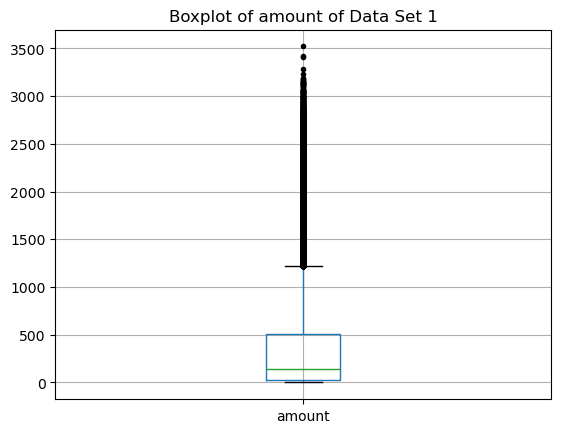

In [59]:
_,bp = finanical_data_process.boxplot(column='amount', sym='k.', return_type ='both')
outliers = [flier.get_ydata() for flier in bp["fliers"]]
plt.title('Boxplot of amount of Data Set 1')
plt.show()

In [60]:
outliers

[array([2773.86, 1666.22, 1237.07, ..., 1263.16, 1785.69, 1525.78],
       dtype=object)]

In [61]:
print(f"Total number of outliers under amount: {str(len(outliers[0]))}")

Total number of outliers under amount: 412449


<b>Results:</b><br>
Upon inspected, `amount` ranges from 0.01 to 3520.57, with no missing values but having 412,449 outliers. Yet, all ouliers are kept since the large amount of values are possible results for fraud cases. 

#### 4.1.6 transaction_type

In [62]:
finanical_data_process['transaction_type'].value_counts()

transaction_type
deposit       1250593
payment       1250438
transfer      1250334
withdrawal    1248635
Name: count, dtype: int64

In [63]:
finanical_data_process['transaction_type'].value_counts(normalize=True) * 100

transaction_type
deposit       25.01186
payment       25.00876
transfer      25.00668
withdrawal    24.97270
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `transaction_type` consists of 4 types and has no abnormal behvaior, including no missing value, no redundant spaces and matching with data dictionary.

#### 4.1.7 merchant_category

In [64]:
finanical_data_process['merchant_category'].value_counts()

merchant_category
retail           626319
travel           625656
restaurant       625483
entertainment    625332
grocery          624954
other            624589
utilities        624086
online           623581
Name: count, dtype: int64

In [65]:
finanical_data_process['merchant_category'].value_counts(normalize=True) * 100

merchant_category
retail           12.52638
travel           12.51312
restaurant       12.50966
entertainment    12.50664
grocery          12.49908
other            12.49178
utilities        12.48172
online           12.47162
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `merchant_category` consists of 8 types and has no abnormal behvaior, including no missing value, no redundant spaces and matching with data dictionary.

#### 4.1.8 location

In [66]:
finanical_data_process['location'].value_counts()

location
Tokyo        625994
New York     625354
Singapore    625313
Berlin       625289
Sydney       625125
Toronto      624349
Dubai        624320
London       624256
Name: count, dtype: int64

In [67]:
finanical_data_process['location'].value_counts(normalize=True) * 100

location
Tokyo        12.51988
New York     12.50708
Singapore    12.50626
Berlin       12.50578
Sydney       12.50250
Toronto      12.48698
Dubai        12.48640
London       12.48512
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `location` consists of 8 different locations and has no abnormal behvaior, including no missing value, no redundant spaces and matching with data dictionary.

#### 4.1.9 device_used

In [68]:
finanical_data_process['device_used'].value_counts()

device_used
mobile    1251131
web       1250071
atm       1249640
pos       1249158
Name: count, dtype: int64

In [69]:
finanical_data_process['device_used'].value_counts(normalize=True) * 100

device_used
mobile    25.02262
web       25.00142
atm       24.99280
pos       24.98316
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `device_used` consists of 4 types and has no abnormal behvaior, including no missing value, no redundant spaces and matching with data dictionary.

#### 4.1.10 is_fraud

In [70]:
finanical_data_process['is_fraud'].value_counts()

is_fraud
False    4820447
True      179553
Name: count, dtype: int64

In [71]:
finanical_data_process['is_fraud'].value_counts(normalize=True) * 100

is_fraud
False    96.40894
True      3.59106
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `is_fraud` is boolean flag with True as Fraud Transaction and False as Normal transaction. and has no abnormal behvaior, including no missing value and matching with data dictionary.

#### 4.1.11 fraud_type

In [72]:
finanical_data_process['fraud_type'].value_counts()

fraud_type
card_not_present    179553
Name: count, dtype: int64

In [73]:
finanical_data_process['fraud_type'].value_counts(normalize=True) * 100

fraud_type
card_not_present    100.0
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `fraud_type` consists of 1 type with missing values. Yet, `fraud_type` exists when `is_fraud` is True. Thus, this is normal behavior.Thus, there are no other abnormal behvaior, including no redundant spaces and matching with data dictionary.

#### 4.1.12 time_since_last_transaction

In [74]:
finanical_data_process['time_since_last_transaction'].describe()

count    4.103487e+06
mean     1.525799e+00
std      3.576569e+03
min     -8.777814e+03
25%     -2.562376e+03
50%      8.442747e-01
75%      2.568339e+03
max      8.757758e+03
Name: time_since_last_transaction, dtype: float64

In [75]:
print(f"time_since_last_transaction range: [{finanical_data_process['time_since_last_transaction'].min()} to {finanical_data_process['time_since_last_transaction'].max()}]")

time_since_last_transaction range: [-8777.814181944444 to 8757.758483437501]


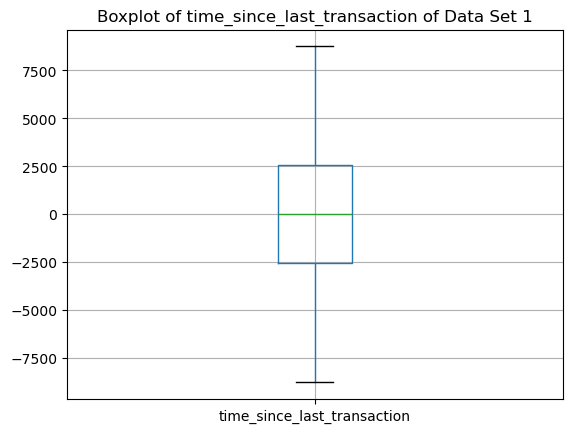

In [76]:
_,bp = finanical_data_process.boxplot(column='time_since_last_transaction', sym='k.', return_type ='both')
outliers = [flier.get_ydata() for flier in bp["fliers"]]
plt.title('Boxplot of time_since_last_transaction of Data Set 1')
plt.show()

In [77]:
print(f"Total number of outliers under time_since_last_transaction: {str(len(outliers[0]))}")

Total number of outliers under time_since_last_transaction: 0


<b>Results:</b><br>
Upon inspected, `time_since_last_transaction` ranges from  -8777.81 to 8757.75 with missing values. As mentioned before, negative values are physically impossible but we have no clue to impute with other values with justification. Also, missing values are possible as this may be the first time of transaction from customer. Thus, all negative values and missing values are kept without change. Besides, there are no outliers identified.

#### 4.1.13 spending_deviation_score

In [78]:
finanical_data_process['spending_deviation_score'].describe()

count    5.000000e+06
mean    -3.881160e-04
std      1.000807e+00
min     -5.260000e+00
25%     -6.800000e-01
50%      0.000000e+00
75%      6.700000e-01
max      5.020000e+00
Name: spending_deviation_score, dtype: float64

In [79]:
print(f"spending_deviation_score range: [{finanical_data_process['spending_deviation_score'].min()} to {finanical_data_process['spending_deviation_score'].max()}]")

spending_deviation_score range: [-5.26 to 5.02]


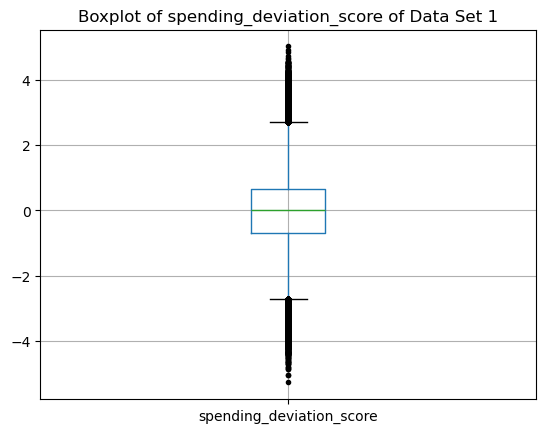

In [80]:
_,bp = finanical_data_process.boxplot(column='spending_deviation_score', sym='k.', return_type ='both')
outliers = [flier.get_ydata() for flier in bp["fliers"]]
plt.title('Boxplot of spending_deviation_score of Data Set 1')
plt.show()

In [81]:
outliers

[array([-2.8, -2.73, -3.01, ..., 2.89, 2.76, 2.7], dtype=object)]

In [82]:
print(f"Total number of outliers under spending_deviation_score: {str(len(outliers[0]))}")

Total number of outliers under spending_deviation_score: 35075


<b>Results:</b><br>
Upon inspected, `spending_deviation_score` ranges from -5.26 to 5.02 with having 35075 outliers. As this is the calculated score, the outliers are possible observations. Thus, all is kept in the dataset. Apart from outliers, there are no other abnormal behavior, including no missing values and matching with data dictionary. 

#### 4.1.14 velocity_score

In [83]:
finanical_data_process['velocity_score'].describe()

count    5.000000e+06
mean     1.050132e+01
std      5.766842e+00
min      1.000000e+00
25%      5.000000e+00
50%      1.100000e+01
75%      1.600000e+01
max      2.000000e+01
Name: velocity_score, dtype: float64

In [84]:
print(f"velocity_score range: [{finanical_data_process['velocity_score'].min()} to {finanical_data_process['velocity_score'].max()}]")

velocity_score range: [1 to 20]


In [85]:
finanical_data_process['velocity_score'].value_counts()

velocity_score
18    250777
13    250612
10    250405
14    250362
17    250353
1     250178
4     250150
3     250145
20    250050
7     250039
5     249956
11    249904
9     249858
19    249834
6     249818
15    249797
2     249714
12    249695
16    249288
8     249065
Name: count, dtype: int64

In [86]:
finanical_data_process['velocity_score'].value_counts(normalize=True) * 100

velocity_score
18    5.01554
13    5.01224
10    5.00810
14    5.00724
17    5.00706
1     5.00356
4     5.00300
3     5.00290
20    5.00100
7     5.00078
5     4.99912
11    4.99808
9     4.99716
19    4.99668
6     4.99636
15    4.99594
2     4.99428
12    4.99390
16    4.98576
8     4.98130
Name: proportion, dtype: float64

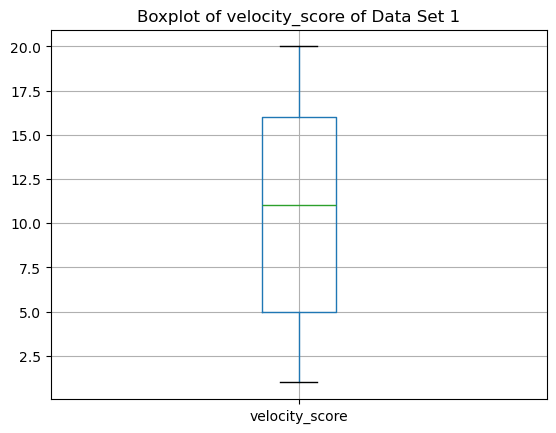

In [87]:
_,bp = finanical_data_process.boxplot(column='velocity_score', sym='k.', return_type ='both')
outliers = [flier.get_ydata() for flier in bp["fliers"]]
plt.title('Boxplot of velocity_score of Data Set 1')
plt.show()

In [88]:
print(f"Total number of outliers under velocity_score: {str(len(outliers[0]))}")

Total number of outliers under velocity_score: 0


<b>Results:</b><br>
Upon inspected, `velocity_score` ranges from 1 to 20 and has no abnormal behavior, including no missing values, no outliers and matching with data dictionary. 

#### 4.1.15 geo_anomaly_score

In [89]:
finanical_data_process['geo_anomaly_score'].describe()

count    5.000000e+06
mean     5.000293e-01
std      2.886349e-01
min      0.000000e+00
25%      2.500000e-01
50%      5.000000e-01
75%      7.500000e-01
max      1.000000e+00
Name: geo_anomaly_score, dtype: float64

In [90]:
print(f"geo_anomaly_score range: [{finanical_data_process['geo_anomaly_score'].min()} to {finanical_data_process['geo_anomaly_score'].max()}]")

geo_anomaly_score range: [0.0 to 1.0]


In [91]:
finanical_data_process['geo_anomaly_score'].value_counts()

geo_anomaly_score
0.21    50450
0.65    50445
0.14    50439
0.76    50438
0.87    50410
        ...  
0.01    49455
0.16    49428
0.86    49286
0.00    24904
1.00    24621
Name: count, Length: 101, dtype: int64

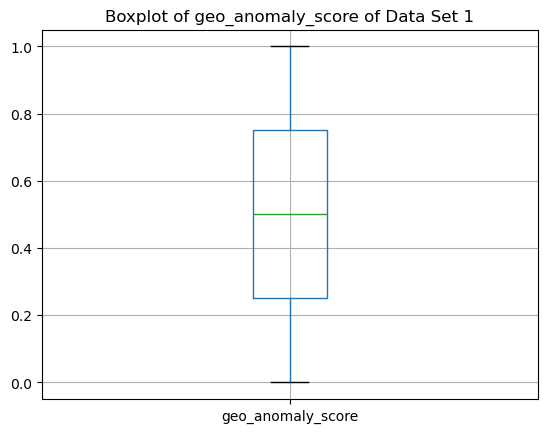

In [92]:
_,bp = finanical_data_process.boxplot(column='geo_anomaly_score', sym='k.', return_type ='both')
outliers = [flier.get_ydata() for flier in bp["fliers"]]
plt.title('Boxplot of geo_anomaly_score of Data Set 1')
plt.show()

In [93]:
print(f"Total number of outliers under geo_anomaly_score: {str(len(outliers[0]))}")

Total number of outliers under geo_anomaly_score: 0


<b>Results:</b><br>
Upon inspected, `geo_anomaly_score` ranges from 0 to 1 and has no abnormal behavior, including no missing values, no outliers and matching with data dictionary. 

#### 4.1.16 payment_channel

In [94]:
finanical_data_process['payment_channel'].value_counts()

payment_channel
wire_transfer    1251219
ACH              1250241
card             1249693
UPI              1248847
Name: count, dtype: int64

In [95]:
finanical_data_process['payment_channel'].value_counts(normalize=True) * 100

payment_channel
wire_transfer    25.02438
ACH              25.00482
card             24.99386
UPI              24.97694
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `payment_channel` consists of 4 types and has no abnormal behvaior, including no missing value, no redundant spaces and matching with data dictionary.

#### 4.1.17 ip_address

In [96]:
finanical_data_process['ip_address'].value_counts()

ip_address
135.227.29.146     2
224.135.117.129    2
199.74.155.181     2
179.45.237.171     2
137.20.124.68      2
                  ..
231.45.100.123     1
129.210.184.211    1
189.77.89.197      1
44.81.58.110       1
246.68.126.184     1
Name: count, Length: 4997068, dtype: int64

In [97]:
finanical_data_process['ip_address'].value_counts(normalize=True) * 100

ip_address
135.227.29.146     0.00004
224.135.117.129    0.00004
199.74.155.181     0.00004
179.45.237.171     0.00004
137.20.124.68      0.00004
                    ...   
231.45.100.123     0.00002
129.210.184.211    0.00002
189.77.89.197      0.00002
44.81.58.110       0.00002
246.68.126.184     0.00002
Name: proportion, Length: 4997068, dtype: float64

In [98]:
def is_valid_ip(ip):
    # Handle missing or null values safely
    if pd.isna(ip):
        return False
    try:
        ipaddress.ip_address(str(ip).strip())
        return True
    except ValueError:
        return False

In [99]:
# Apply the validation function to your IP column
# Replace 'ip_address' with your actual column name if different
finanical_data_process['is_valid_ip'] = finanical_data_process['ip_address'].apply(is_valid_ip)

# Separate valid and invalid data
invalid_ips = finanical_data_process[~finanical_data_process['is_valid_ip']]
valid_ips_count = finanical_data_process['is_valid_ip'].sum()

# Prin out the results summary
print(f"Valid IP addresses found: {valid_ips_count:,}")
print(f"Invalid IP addresses found: {len(invalid_ips):,}")

# Display the invalid rows to check what went wrong if any
if not invalid_ips.empty:
    print("\n--- Sample of Invalid IP Addresses ---")
    print(invalid_ips[['ip_address']].head(10))


Valid IP addresses found: 5,000,000
Invalid IP addresses found: 0


In [100]:
finanical_data_process = finanical_data_process.drop(columns=['is_valid_ip'])

<b>Results:</b><br>
Upon inspected, `ip_address` has no abnormal behvaior, including valid IP address, no missing value, no redundant spaces and matching with data dictionary.

#### 4.1.18 device_hash

In [101]:
finanical_data_process['device_hash'].value_counts()

device_hash
D7441961    9
D4187649    8
D9601073    8
D1728922    8
D2769885    7
           ..
D2732315    1
D7573572    1
D3142039    1
D2103366    1
D6333607    1
Name: count, Length: 3835723, dtype: int64

In [102]:
finanical_data_process['device_hash'].value_counts(normalize=True) * 100

device_hash
D7441961    0.00018
D4187649    0.00016
D9601073    0.00016
D1728922    0.00016
D2769885    0.00014
             ...   
D2732315    0.00002
D7573572    0.00002
D3142039    0.00002
D2103366    0.00002
D6333607    0.00002
Name: proportion, Length: 3835723, dtype: float64

<b>Results:</b><br>
Upon inspected, `device_hash` has no abnormal behvaior, including no missing value, no redundant spaces and matching with data dictionary.

### 4.2 Dataset 2 - banking_data_process

#### 4.2.1 Transaction_ID

In [103]:
# Check 'transaction_id' column for uniqueness
print("Is Transaction_ID unique? ",banking_data_process['Transaction_ID'].is_unique)

Is Transaction_ID unique?  False


In [104]:
banking_data_process['Transaction_ID'].value_counts()

Transaction_ID
803470    3
200476    3
571656    3
839324    3
232025    3
         ..
713605    1
836333    1
529988    1
250561    1
121538    1
Name: count, Length: 48623, dtype: int64

In [105]:
# Filter and display all duplicated Transaction IDs (excluding the first occurrence)
duplicated_ids = banking_data_process[banking_data_process['Transaction_ID'].duplicated()]

In [106]:
duplicated_ids

,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,Distance_From_Home,Device_ID,...,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label,Transaction_DateTime
625,108721,69001,5.0,Online,30895,ATM,Islamabad,Islamabad,160.0,619471,...,24,3.0,1.0,No,No,0,No,0,Normal,2025-01-03 04:54:00
1838,761828,37653,4.0,ATM,22456,Restaurant,Faisalabad,Multan,157.0,393492,...,1,5.0,4.0,Yes,No,1,Yes,1,Normal,2025-01-02 06:28:00
2474,382847,39118,1.0,Online,88171,Restaurant,Kuala Lumpur,Multan,40.0,475406,...,19,1.0,6.0,Yes,Yes,1,No,1,Normal,2025-02-28 04:05:00
2753,295662,97671,3.0,Online,44257,Grocery,Kuala Lumpur,Islamabad,307.0,963540,...,2,3.0,9.0,No,No,1,Yes,1,Normal,2025-01-26 12:55:00
2960,409154,77452,6.0,ATM,93212,Grocery,Kuala Lumpur,Karachi,91.0,679226,...,5,2.0,3.0,Yes,No,1,Yes,0,Normal,2025-03-23 10:22:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49827,821003,59979,9.0,POS,85337,Grocery,Kuala Lumpur,Islamabad,351.0,698125,...,2,3.0,1.0,Yes,Yes,1,No,0,Normal,2025-01-28 08:33:00
49876,431430,48595,7.0,ATM,69373,Fuel,Dubai,Islamabad,301.0,237619,...,22,2.0,1.0,Yes,Yes,1,No,1,Normal,2025-02-20 18:43:00
49891,333691,38810,6.0,Online,32908,Grocery,Kuala Lumpur,Islamabad,198.0,944628,...,14,3.0,9.0,No,No,0,Yes,1,Normal,2025-03-25 01:11:00
49902,649770,65432,8.0,POS,76080,ATM,London,Lahore,399.0,453648,...,22,3.0,7.0,Yes,No,0,Yes,1,Fraud,2025-03-03 08:46:00


<b>Results:</b><br>
Upon inspected, `Transaction_ID` contains 3 missing values with correct converted data type. Yet, this is not a primary key where 1360 duplicated records are identified.

#### 4.2.2 Customer_ID

In [107]:
# Check 'Customer_ID' column for uniqueness
print("Is Customer_ID unique? ",banking_data_process['Customer_ID'].is_unique)

Is Customer_ID unique?  False


In [108]:
banking_data_process['Customer_ID'].value_counts()

Customer_ID
43223    6
15303    6
88220    6
10985    6
51780    5
        ..
19978    1
23514    1
66999    1
45926    1
14318    1
Name: count, Length: 38346, dtype: int64

In [109]:
# Filter and display all duplicated Transaction IDs (excluding the first occurrence)
duplicated_customer_ids = banking_data_process[banking_data_process['Customer_ID'].duplicated()]

duplicated_customer_ids

<b>Results:</b><br>
Upon inspected, `Transaction_ID` contains 10 missing values with correct converted data type. Yet, this is not a primary key where 11637 duplicated records are identified.

#### 4.2.3 Transaction_Amount (in Million)

In [110]:
print(f"Transaction_Amount (in Million) range: [{banking_data_process['Transaction_Amount (in Million)'].min()} to {banking_data_process['Transaction_Amount (in Million)'].max()}]")

Transaction_Amount (in Million) range: [1.0 to 9.0]


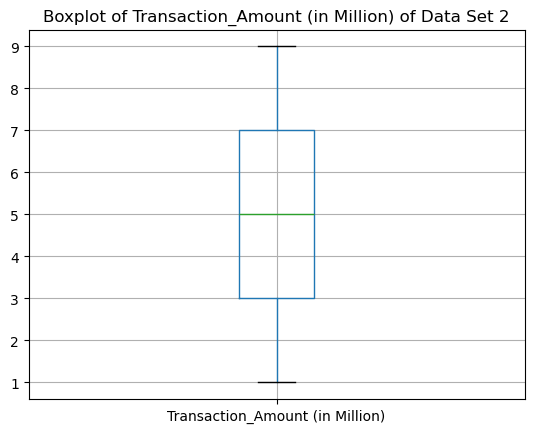

In [111]:
_,bp = banking_data_process.boxplot(column='Transaction_Amount (in Million)', sym='k.', return_type ='both')
outliers = [flier.get_ydata() for flier in bp["fliers"]]
plt.title('Boxplot of Transaction_Amount (in Million) of Data Set 2')
plt.show()

In [112]:
print(f"Total number of outliers under Transaction_Amount (in Million): {str(len(outliers[0]))}")

Total number of outliers under Transaction_Amount (in Million): 0


<b>Results:</b><br>
Upon inspected, `Transaction_Amount (in Million)` ranges from 1 to 9 with 9 missing values. Besides, there are no outliers identified. 

#### 4.2.4 Transaction_Type

In [113]:
banking_data_process['Transaction_Type'].value_counts()

Transaction_Type
Online     16707
ATM        16674
POS        16599
Unknown        4
Name: count, dtype: int64

In [114]:
banking_data_process['Transaction_Type'].value_counts(normalize=True) * 100

Transaction_Type
Online     33.424696
ATM        33.358675
POS        33.208627
Unknown     0.008003
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `Transaction_Type` consists of 4 type and has no abnormal behavior, including no missing value (imputed as Unknown) and no reducdant space.

#### 4.2.5 Merchant_ID

In [115]:
banking_data_process['Merchant_ID'].value_counts()

Merchant_ID
43566    6
43845    6
26375    5
50253    5
22673    5
        ..
45709    1
83011    1
86492    1
69774    1
69446    1
Name: count, Length: 38302, dtype: int64

In [116]:
banking_data_process['Merchant_ID'].value_counts(normalize=True) * 100

Merchant_ID
43566    0.012006
43845    0.012006
26375    0.010005
50253    0.010005
22673    0.010005
           ...   
45709    0.002001
83011    0.002001
86492    0.002001
69774    0.002001
69446    0.002001
Name: proportion, Length: 38302, dtype: float64

<b>Results:</b><br>
Upon inspected, `Merchant_ID` has 7 missing values with correct converted data type.

#### 4.2.6 Merchant_Category

In [117]:
banking_data_process['Merchant_Category'].value_counts()

Merchant_Category
Restaurant     8481
ATM            8398
Fuel           8354
Clothing       8278
Grocery        8251
Electronics    8213
Unknown           9
Name: count, dtype: int64

In [118]:
banking_data_process['Merchant_Category'].value_counts(normalize=True) * 100

Merchant_Category
Restaurant     16.967430
ATM            16.801376
Fuel           16.713348
Clothing       16.561300
Grocery        16.507282
Electronics    16.431258
Unknown         0.018006
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `Transaction_Type` consists of 7 types and has no abnormal behavior, including no missing value (imputed as Unknown) and no reducdant space.

### 4.2.7 Transaction_Location

In [119]:
banking_data_process['Transaction_Location'].value_counts()

Transaction_Location
Multan          5080
Kuala Lumpur    5070
Lahore          5048
Singapore       5023
Islamabad       5019
Faisalabad      5016
Bangkok         4985
Karachi         4928
Dubai           4915
London          4894
Unknown            6
Name: count, dtype: int64

In [120]:
banking_data_process['Transaction_Location'].value_counts(normalize=True) * 100

Transaction_Location
Multan          10.163252
Kuala Lumpur    10.143246
Lahore          10.099232
Singapore       10.049216
Islamabad       10.041213
Faisalabad      10.035211
Bangkok          9.973191
Karachi          9.859155
Dubai            9.833147
London           9.791133
Unknown          0.012004
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `Transaction_Location` consists of 11 types and has no abnormal behavior, including no missing value (imputed as Unknown) and no reducdant space.

### 4.2.8 Customer_Home_Location

In [121]:
banking_data_process['Customer_Home_Location'].value_counts()

Customer_Home_Location
Lahore        10114
Islamabad     10013
Karachi       10006
Multan         9944
Faisalabad     9903
Unknown           4
Name: count, dtype: int64

In [122]:
banking_data_process['Customer_Home_Location'].value_counts(normalize=True) * 100

Customer_Home_Location
Lahore        20.234475
Islamabad     20.032410
Karachi       20.018406
Multan        19.894366
Faisalabad    19.812340
Unknown        0.008003
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `Customer_Home_Location` consists of 6 types and has no abnormal behavior, including no missing value (imputed as Unknown) and no reducdant space.

#### 4.2.9 Distance_From_Home

In [123]:
print(f"Distance_From_Home range: [{banking_data_process['Distance_From_Home'].min()} to {banking_data_process['Distance_From_Home'].max()}]")

Distance_From_Home range: [1.0 to 599.0]


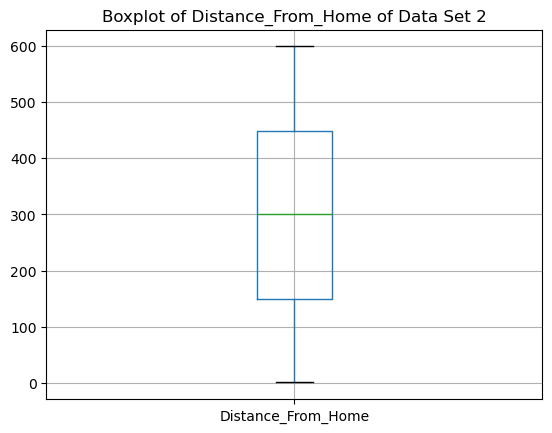

In [124]:
_,bp = banking_data_process.boxplot(column='Distance_From_Home', sym='k.', return_type ='both')
outliers = [flier.get_ydata() for flier in bp["fliers"]]
plt.title('Boxplot of Distance_From_Home of Data Set 2')
plt.show()

In [125]:
print(f"Total number of outliers under Distance_From_Home: {str(len(outliers[0]))}")

Total number of outliers under Distance_From_Home: 0


<b>Results:</b><br>
Upon inspected, `Distance_From_Home` ranges from 1 to 599 with 2 missing values. Besides, there are no outliers identified.

#### 4.2.10 Device_ID

In [126]:
banking_data_process['Device_ID'].value_counts()

Device_ID
753471    4
849760    4
746074    3
950353    3
853118    3
         ..
938676    1
773063    1
645627    1
825181    1
535196    1
Name: count, Length: 48617, dtype: int64

In [127]:
banking_data_process['Device_ID'].value_counts(normalize=True) * 100

Device_ID
753471    0.008004
849760    0.008004
746074    0.006003
950353    0.006003
853118    0.006003
            ...   
938676    0.002001
773063    0.002001
645627    0.002001
825181    0.002001
535196    0.002001
Name: proportion, Length: 48617, dtype: float64

<b>Results:</b><br>
Upon inspected, `Device_ID` has 9 missing values with correct converted data type.

#### 4.2.11 IP_Address

In [128]:
banking_data_process['IP_Address'].value_counts()

IP_Address
231.92.159.84     1
12.198.193.47     1
80.44.136.156     1
220.191.48.128    1
189.128.9.233     1
                 ..
38.188.241.170    1
240.35.173.65     1
127.215.147.21    1
8.96.213.144      1
69.168.33.58      1
Name: count, Length: 49978, dtype: int64

In [129]:
banking_data_process['IP_Address'].value_counts(normalize=True) * 100

IP_Address
231.92.159.84     0.002001
12.198.193.47     0.002001
80.44.136.156     0.002001
220.191.48.128    0.002001
189.128.9.233     0.002001
                    ...   
38.188.241.170    0.002001
240.35.173.65     0.002001
127.215.147.21    0.002001
8.96.213.144      0.002001
69.168.33.58      0.002001
Name: proportion, Length: 49978, dtype: float64

In [130]:
# Apply the validation function to your IP column
# Replace 'ip_address' with your actual column name if different
banking_data_process['is_valid_ip'] = banking_data_process['IP_Address'].apply(is_valid_ip)

# Separate valid and invalid data
invalid_ips = banking_data_process[~banking_data_process['is_valid_ip']]
valid_ips_count = banking_data_process['is_valid_ip'].sum()

# Print out the results summary
print(f"Valid IP addresses found: {valid_ips_count:,}")
print(f"Invalid IP addresses found: {len(invalid_ips):,}")

# Display the invalid rows to check what went wrong
if not invalid_ips.empty:
    print("\n--- Sample of Invalid IP Addresses ---")
    print(invalid_ips[['IP_Address']].head(10))


Valid IP addresses found: 49,978
Invalid IP addresses found: 6

--- Sample of Invalid IP Addresses ---
      IP_Address
3128         NaN
11630        NaN
16831        NaN
31903        NaN
34869        NaN
35645        NaN


In [131]:
banking_data_process = banking_data_process.drop(columns=['is_valid_ip'])

<b>Results:</b><br>
Upon inspected, `IP_Address` has 6 missing values which is treated as Invalid IP Addresses. Apart from this, all other IP addresses are valid IP addresses.

#### 4.2.12 Card_Type

In [132]:
banking_data_process['Card_Type'].value_counts()

Card_Type
Debit      25096
Credit     24885
Unknown        3
Name: count, dtype: int64

In [133]:
banking_data_process['Card_Type'].value_counts(normalize=True) * 100

Card_Type
Debit      50.208067
Credit     49.785931
Unknown     0.006002
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `Card_Type` consists of 3 types and has no abnormal behavior, including no missing value (imputed as Unknown) and no reducdant space.

#### 4.2.13 Account_Balance (in Million)

In [134]:
print(f"Account_Balance (in Million) range: [{banking_data_process['Account_Balance (in Million)'].min()} to {banking_data_process['Account_Balance (in Million)'].max()}]")

Account_Balance (in Million) range: [3.0 to 39.0]


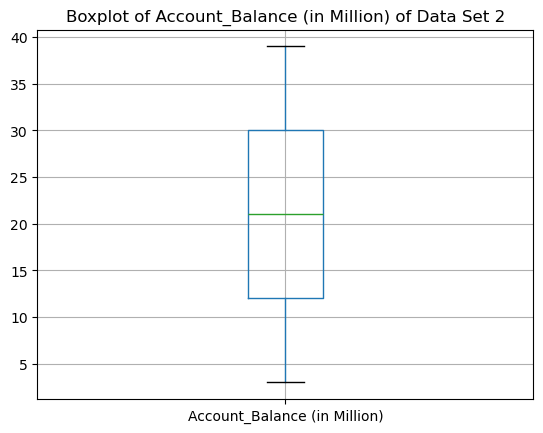

In [135]:
_,bp = banking_data_process.boxplot(column='Account_Balance (in Million)', sym='k.', return_type ='both')
outliers = [flier.get_ydata() for flier in bp["fliers"]]
plt.title('Boxplot of Account_Balance (in Million) of Data Set 2')
plt.show()

In [136]:
print(f"Total number of outliers under Account_Balance (in Million): {str(len(outliers[0]))}")

Total number of outliers under Account_Balance (in Million): 0


<b>Results:</b><br>
Upon inspected, `Account_Balance (in Million)` ranges from 3 to 39 with 9 missing values. Besides, there are no outliers identified.

#### 4.2.14 Daily_Transaction_Count

In [137]:
banking_data_process['Daily_Transaction_Count'].value_counts()

Daily_Transaction_Count
2    7219
6    7185
7    7163
1    7129
3    7122
4    7090
5    7067
Name: count, dtype: Int64

In [138]:
banking_data_process['Daily_Transaction_Count'].value_counts(normalize=True) * 100

Daily_Transaction_Count
2    14.445223
6    14.377189
7    14.333167
1    14.265133
3    14.251126
4    14.187094
5    14.141071
Name: proportion, dtype: Float64

In [139]:
print(f"Daily_Transaction_Count range: [{banking_data_process['Daily_Transaction_Count'].min()} to {banking_data_process['Daily_Transaction_Count'].max()}]")

Daily_Transaction_Count range: [1 to 7]


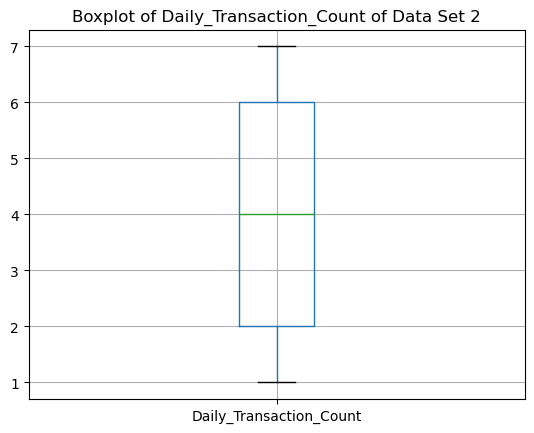

In [140]:
_,bp = banking_data_process.boxplot(column='Daily_Transaction_Count', sym='k.', return_type ='both')
outliers = [flier.get_ydata() for flier in bp["fliers"]]
plt.title('Boxplot of Daily_Transaction_Count of Data Set 2')
plt.show()

In [141]:
print(f"Total number of outliers under Daily_Transaction_Count: {str(len(outliers[0]))}")

Total number of outliers under Daily_Transaction_Count: 0


<b>Results:</b><br>
Upon inspected, `Daily_Transaction_Count` ranges from 1 to 7 with 9 missing values. Besides, there are no outliers identified.

#### 4.2.15 Weekly_Transaction_Count

In [142]:
banking_data_process['Weekly_Transaction_Count'].value_counts()

Weekly_Transaction_Count
18    2170
14    2155
13    2154
20    2136
8     2114
24    2110
3     2109
10    2101
6     2094
23    2086
17    2085
9     2077
12    2075
2     2073
5     2061
7     2058
16    2054
22    2054
11    2043
4     2038
19    2038
1     2037
15    2032
21    2025
Name: count, dtype: Int64

In [143]:
banking_data_process['Weekly_Transaction_Count'].value_counts(normalize=True) * 100

Weekly_Transaction_Count
18    4.341824
14    4.311811
13     4.30981
20    4.273795
8     4.229777
24    4.221773
3     4.219772
10    4.203766
6      4.18976
23    4.173753
17    4.171752
9     4.155745
12    4.151744
2     4.147742
5     4.123732
7     4.117729
16    4.109726
22    4.109726
11    4.087717
4     4.077713
19    4.077713
1     4.075712
15    4.065708
21    4.051702
Name: proportion, dtype: Float64

In [144]:
print(f"Weekly_Transaction_Count range: [{banking_data_process['Weekly_Transaction_Count'].min()} to {banking_data_process['Weekly_Transaction_Count'].max()}]")

Weekly_Transaction_Count range: [1 to 24]


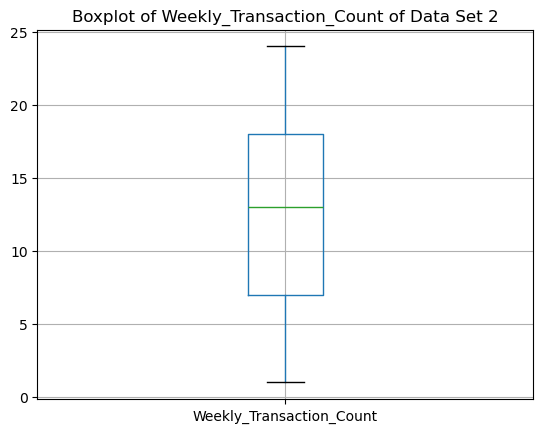

In [145]:
_,bp = banking_data_process.boxplot(column='Weekly_Transaction_Count', sym='k.', return_type ='both')
outliers = [flier.get_ydata() for flier in bp["fliers"]]
plt.title('Boxplot of Weekly_Transaction_Count of Data Set 2')
plt.show()

In [146]:
print(f"Total number of outliers under Weekly_Transaction_Count: {str(len(outliers[0]))}")

Total number of outliers under Weekly_Transaction_Count: 0


<b>Results:</b><br>
Upon inspected, `Daily_Transaction_Count` ranges from 1 to 24 with 5 missing values. Besides, there are no outliers identified.

#### 4.2.16 Avg_Transaction_Amount (in Million)

In [147]:
print(f"Avg_Transaction_Amount (in Million) range: [{banking_data_process['Avg_Transaction_Amount (in Million)'].min()} to {banking_data_process['Avg_Transaction_Amount (in Million)'].max()}]")

Avg_Transaction_Amount (in Million) range: [1.0 to 5.0]


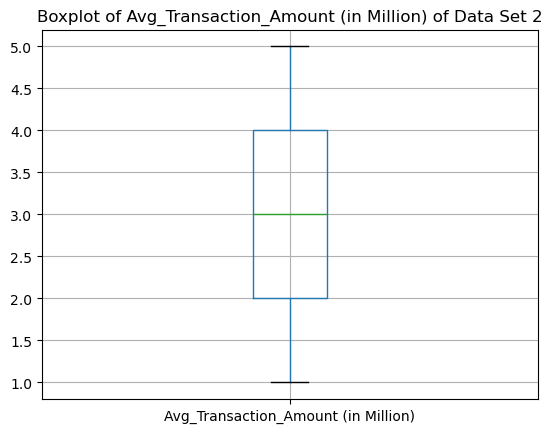

In [148]:
_,bp = banking_data_process.boxplot(column='Avg_Transaction_Amount (in Million)', sym='k.', return_type ='both')
outliers = [flier.get_ydata() for flier in bp["fliers"]]
plt.title('Boxplot of Avg_Transaction_Amount (in Million) of Data Set 2')
plt.show()

In [149]:
print(f"Total number of outliers under Avg_Transaction_Amount (in Million): {str(len(outliers[0]))}")

Total number of outliers under Avg_Transaction_Amount (in Million): 0


<b>Results:</b><br>
Upon inspected, `Avg_Transaction_Amount (in Million)` ranges from 1 to 5 with 9 missing values. Besides, there are no outliers identified.

#### 4.2.17 Max_Transaction_Last_24h (in Million)

In [150]:
print(f"Max_Transaction_Last_24h (in Million) range: [{banking_data_process['Max_Transaction_Last_24h (in Million)'].min()} to {banking_data_process['Max_Transaction_Last_24h (in Million)'].max()}]")

Max_Transaction_Last_24h (in Million) range: [1.0 to 9.0]


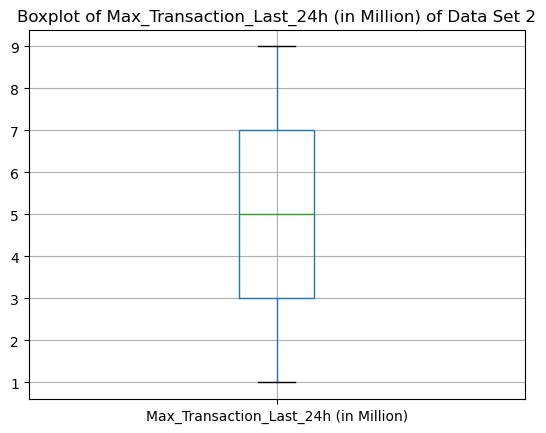

In [151]:
_,bp = banking_data_process.boxplot(column='Max_Transaction_Last_24h (in Million)', sym='k.', return_type ='both')
outliers = [flier.get_ydata() for flier in bp["fliers"]]
plt.title('Boxplot of Max_Transaction_Last_24h (in Million) of Data Set 2')
plt.show()

In [152]:
print(f"Total number of outliers under Max_Transaction_Last_24h (in Million): {str(len(outliers[0]))}")

Total number of outliers under Max_Transaction_Last_24h (in Million): 0


<b>Results:</b><br>
Upon inspected, `Max_Transaction_Last_24h (in Million)` ranges from 1 to 9 with 4 missing values. Besides, there are no outliers identified.

#### 4.2.18 Is_International_Transaction

In [153]:
banking_data_process['Is_International_Transaction'].value_counts()

Is_International_Transaction
Yes        25056
No         24924
Unknown        4
Name: count, dtype: int64

In [154]:
banking_data_process['Is_International_Transaction'].value_counts(normalize=True) * 100

Is_International_Transaction
Yes        50.128041
No         49.863956
Unknown     0.008003
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `Is_International_Transaction` consists of Yes, No, Unkonwn (which is imputed from missing values) and has no abnormal behavior, including no missing value (imputed as Unknown) and no reducdant space.

#### 4.2.19 Is_New_Merchant

In [155]:
banking_data_process['Is_New_Merchant'].value_counts()

Is_New_Merchant
Yes        25048
No         24931
Unknown        5
Name: count, dtype: int64

In [156]:
banking_data_process['Is_New_Merchant'].value_counts(normalize=True) * 100

Is_New_Merchant
Yes        50.112036
No         49.877961
Unknown     0.010003
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `Is_New_Merchant` consists of Yes, No, Unkonwn (which is imputed from missing values) and has no abnormal behavior, including no missing value (imputed as Unknown) and no reducdant space.

#### 4.2.20 Failed_Transaction_Count

In [157]:
banking_data_process['Failed_Transaction_Count'].value_counts()

Failed_Transaction_Count
0    16824
1    16689
2    16460
Name: count, dtype: Int64

In [158]:
banking_data_process['Failed_Transaction_Count'].value_counts(normalize=True) * 100

Failed_Transaction_Count
0     33.66618
1    33.396034
2    32.937786
Name: proportion, dtype: Float64

In [159]:
print(f"Failed_Transaction_Count range: [{banking_data_process['Failed_Transaction_Count'].min()} to {banking_data_process['Failed_Transaction_Count'].max()}]")

Failed_Transaction_Count range: [0 to 2]


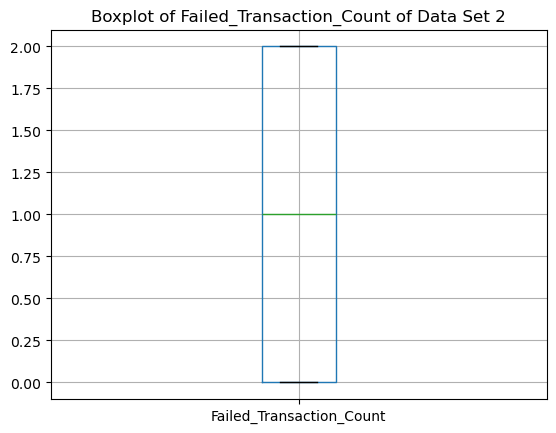

In [160]:
_,bp = banking_data_process.boxplot(column='Failed_Transaction_Count', sym='k.', return_type ='both')
outliers = [flier.get_ydata() for flier in bp["fliers"]]
plt.title('Boxplot of Failed_Transaction_Count of Data Set 2')
plt.show()

In [161]:
print(f"Total number of outliers under Failed_Transaction_Count: {str(len(outliers[0]))}")

Total number of outliers under Failed_Transaction_Count: 0


<b>Results:</b><br>
Upon inspected, `Failed_Transaction_Count` ranges from 0 to 2 with 11 missing values. Besides, there are no outliers identified.

#### 4.2.21 Unusual_Time_Transaction

In [162]:
banking_data_process['Unusual_Time_Transaction'].value_counts()

Unusual_Time_Transaction
No         25108
Yes        24873
Unknown        3
Name: count, dtype: int64

In [163]:
banking_data_process['Unusual_Time_Transaction'].value_counts(normalize=True) * 100

Unusual_Time_Transaction
No         50.232074
Yes        49.761924
Unknown     0.006002
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `Unusual_Time_Transaction` consists of Yes, No, Unkonwn (which is imputed from missing values) and has no abnormal behavior, including no missing value (imputed as Unknown) and no reducdant space.

#### 4.2.22 Previous_Fraud_Count

In [164]:
banking_data_process['Previous_Fraud_Count'].value_counts()

Previous_Fraud_Count
1    24997
0    24984
Name: count, dtype: Int64

In [165]:
banking_data_process['Previous_Fraud_Count'].value_counts(normalize=True) * 100

Previous_Fraud_Count
1    50.013005
0    49.986995
Name: proportion, dtype: Float64

In [166]:
print(f"Previous_Fraud_Count range: [{banking_data_process['Previous_Fraud_Count'].min()} to {banking_data_process['Previous_Fraud_Count'].max()}]")

Previous_Fraud_Count range: [0 to 1]


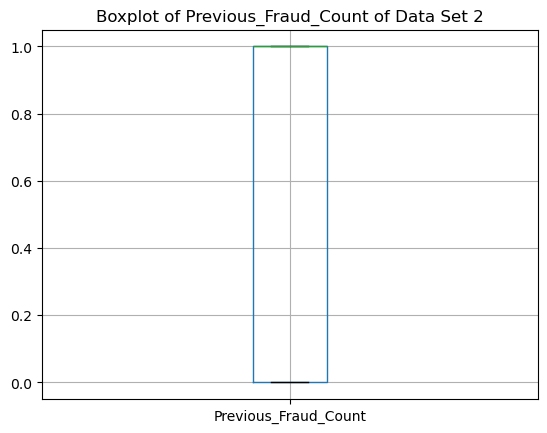

In [167]:
_,bp = banking_data_process.boxplot(column='Previous_Fraud_Count', sym='k.', return_type ='both')
outliers = [flier.get_ydata() for flier in bp["fliers"]]
plt.title('Boxplot of Previous_Fraud_Count of Data Set 2')
plt.show()

In [168]:
print(f"Total number of outliers under Previous_Fraud_Count: {str(len(outliers[0]))}")

Total number of outliers under Previous_Fraud_Count: 0


<b>Results:</b><br>
Upon inspected, `Failed_Transaction_Count` ranges from 0 to 1 with 2 missing values. Besides, there are no outliers identified.

#### 4.2.23 Fraud_Label

In [169]:
banking_data_process['Fraud_Label'].value_counts()

Fraud_Label
Normal    47561
Fraud      2423
Name: count, dtype: int64

In [170]:
banking_data_process['Fraud_Label'].value_counts(normalize=True) * 100

Fraud_Label
Normal    95.152449
Fraud      4.847551
Name: proportion, dtype: float64

For data modeling, this target label is recommended to change from object to boolean. 

In [171]:
banking_data_process['Fraud_Label'] = banking_data_process['Fraud_Label'].map({'Fraud': True, 'Normal': False})

In [172]:
banking_data_process['Fraud_Label'].value_counts()

Fraud_Label
False    47561
True      2423
Name: count, dtype: int64

In [173]:
banking_data_process['Fraud_Label'].value_counts(normalize=True) * 100

Fraud_Label
False    95.152449
True      4.847551
Name: proportion, dtype: float64

<b>Results:</b><br>
Upon inspected, `Fraud_Label` consists of True (which is Fraud transaction) and False (which is Normal transaction) and has no abnormal behavior, including no missing value and no reducdant space.

#### 4.2.24 Duplication checking based on primary key(s)

In [174]:
total_duplicates = banking_data_process.duplicated(subset=['Transaction_ID', 'Customer_ID']).sum()
print(f"Total duplicate rows based on the Transaction_ID and Customer_ID: {total_duplicates}")

Total duplicate rows based on the Transaction_ID and Customer_ID: 0


<b>Results:</b><br>
Upon inspected, there are no duplication identified based on the composite primary keys `Transaction_ID` and `Customer_ID`.

## 5. Data Exploration

To further understand the data sets, data visualization will be applied.

### 5.1 Data Set 1

#### 5.1.1 timestamp

In [175]:
# 1. Monthly components
finanical_data_process['Month'] = finanical_data_process['timestamp'].dt.to_period('M').astype(str)
# 2. Daily components (Day Name ensures a clean order: Monday, Tuesday, etc.)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
finanical_data_process['Day_of_Week'] = finanical_data_process['timestamp'].dt.day_name()
finanical_data_process['Day_of_Week'] = pd.Categorical(finanical_data_process['Day_of_Week'], categories=day_order, ordered=True)
finanical_data_process["txn_day_of_week"] = finanical_data_process["timestamp"].dt.dayofweek.astype('Int64')
finanical_data_process["is_weekend"] = finanical_data_process["txn_day_of_week"].isin([5, 6]).astype('Int64')
# 3. Hourly components
finanical_data_process['Hour'] = finanical_data_process['timestamp'].dt.hour.astype('Int64')
finanical_data_process["is_night"] = finanical_data_process["Hour"].between(0, 5).astype('Int64')

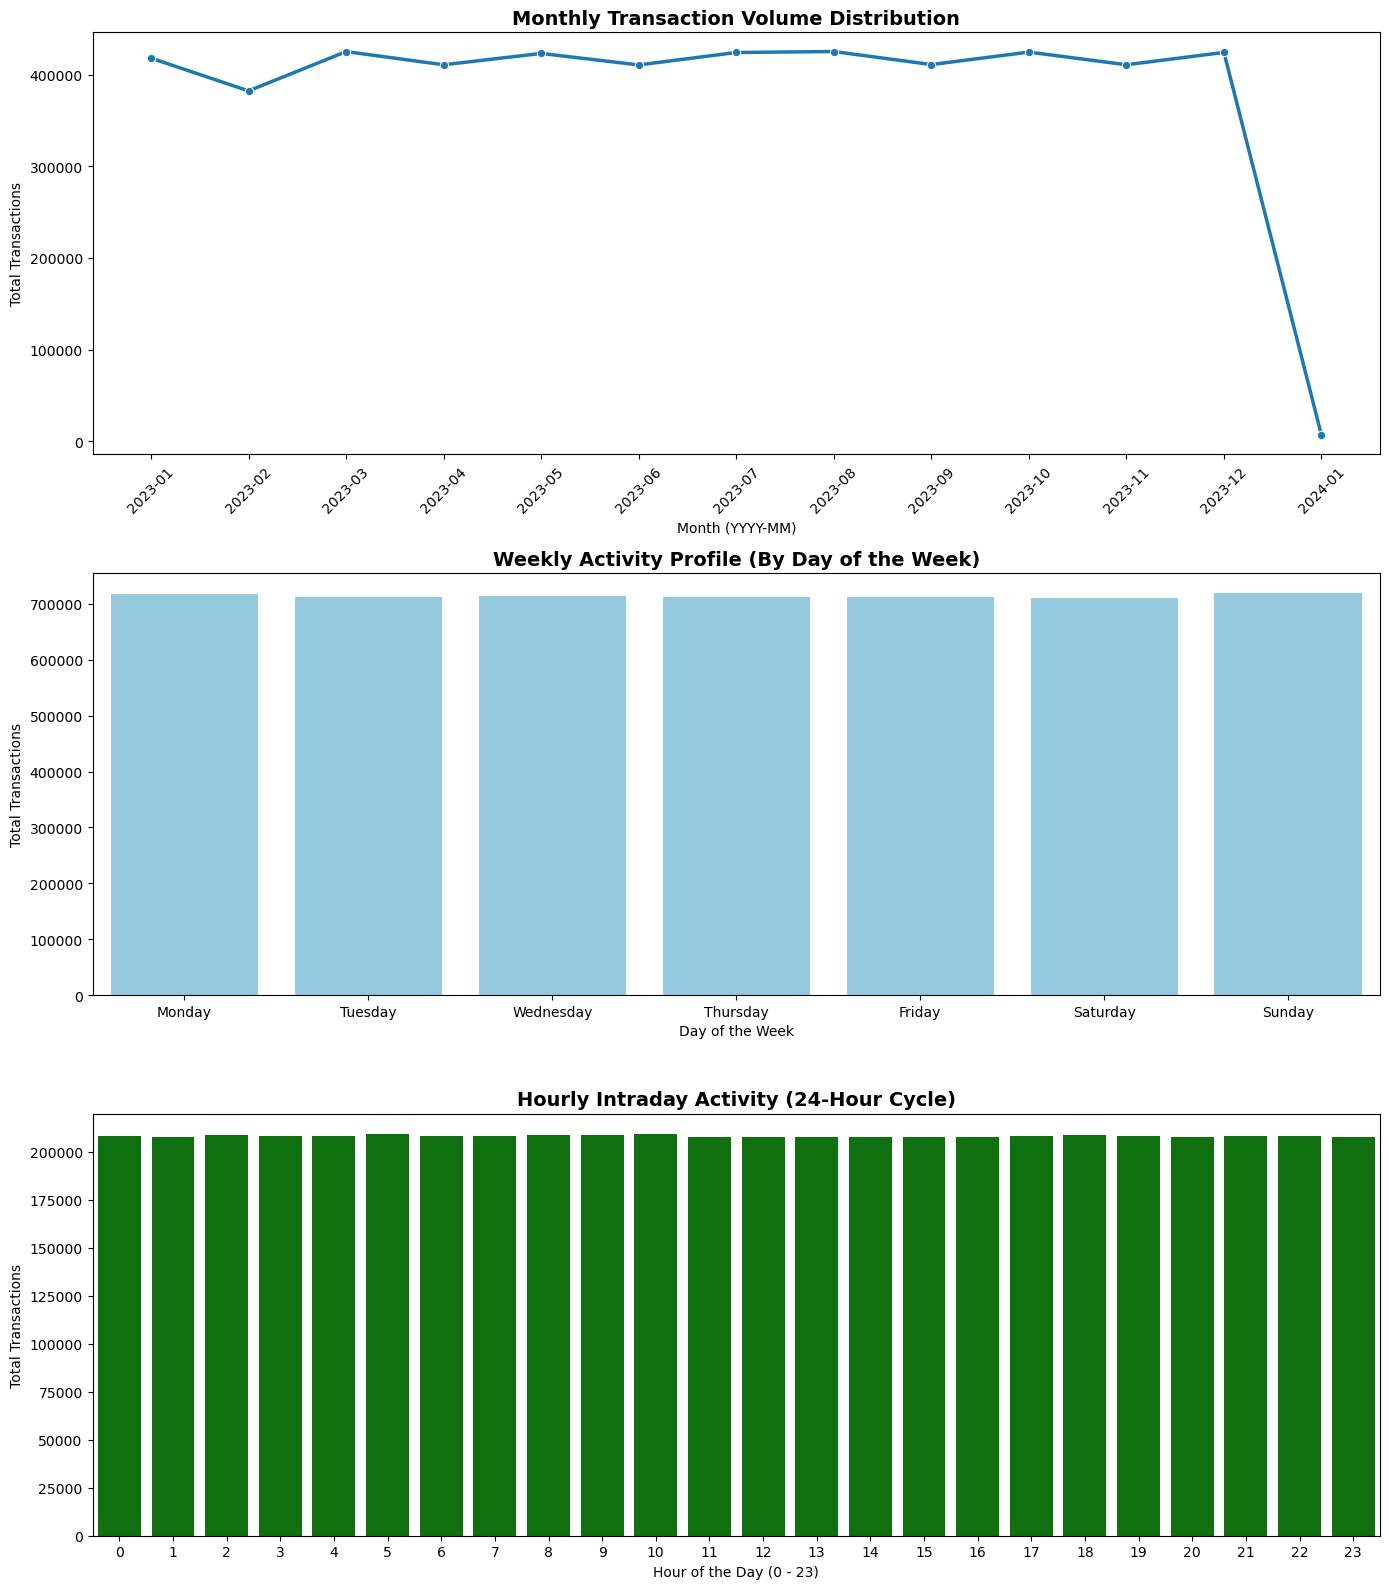

In [176]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# Monthly Trends (Line Chart)
monthly_counts = finanical_data_process.groupby('Month').size().reset_index(name='Count')
sns.lineplot(ax=axes[0], data=monthly_counts, x='Month', y='Count', marker='o', color='#1f77b4', linewidth=2.5)
axes[0].set_title('Monthly Transaction Volume Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month (YYYY-MM)')
axes[0].set_ylabel('Total Transactions')
axes[0].tick_params(axis='x', rotation=45)

# Daily Trends (Bar Chart)
daily_counts = finanical_data_process.groupby('Day_of_Week', observed=False).size().reset_index(name='Count')
sns.barplot(ax=axes[1], data=daily_counts, x='Day_of_Week', y='Count', color='skyblue')
axes[1].set_title('Weekly Activity Profile (By Day of the Week)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of the Week')
axes[1].set_ylabel('Total Transactions')

# Hourly Trends (Bar Chart)
hourly_counts = finanical_data_process.groupby('Hour').size().reset_index(name='Count')
sns.barplot(ax=axes[3 if False else 2], data=hourly_counts, x='Hour', y='Count', color='green')
axes[2].set_title('Hourly Intraday Activity (24-Hour Cycle)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Hour of the Day (0 - 23)')
axes[2].set_ylabel('Total Transactions')

plt.tight_layout()
plt.show()


Prelim insight:

- Transaction volume remains exceptionally flat and consistent from January 2023 through December 2023 from both monthly, weekly and hourly basis.
- There is a severe and near-vertical drop-off in transaction volume in January 2024. This likely indicates incomplete data for that month (e.g., pulling data on Jan 1st or 2nd) rather than a real business crash.
- There is zero drop-off on Saturday and Sunday, probably due to an automated system with 24-hours global service, or e-commerce processing that also works over weekends.
- Human behavior naturally creates peaks during daytime hours and drops during sleep hours (1 AM – 5 AM). Yet, this hourly chart is perfectly uniform given that this is a system generated data.

#### 5.1.2 amount

<Figure size 640x480 with 0 Axes>

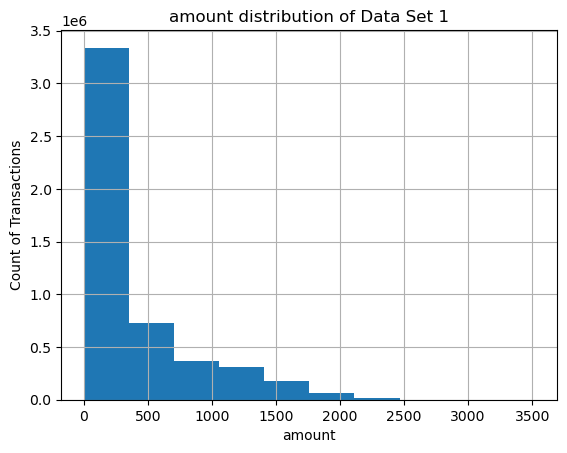

In [177]:
# Histogram of the amount
fig = plt.figure()
finanical_data_process.hist('amount', bins = 10)
plt.title('amount distribution of Data Set 1')
plt.xlabel('amount')
plt.ylabel('Count of Transactions')
plt.show()

Since the histogram of `amount` is heavily right-skewed, data transaction with log-transform is applied to help the decision tree model in the next step.

In [178]:
# Log-transform amount (heavily right-skewed) to help the Decision Tree
# find cleaner splits; XGBoost is scale-invariant but this is harmless.
finanical_data_process["log_amount"] = np.log1p(finanical_data_process["amount"])

<Figure size 640x480 with 0 Axes>

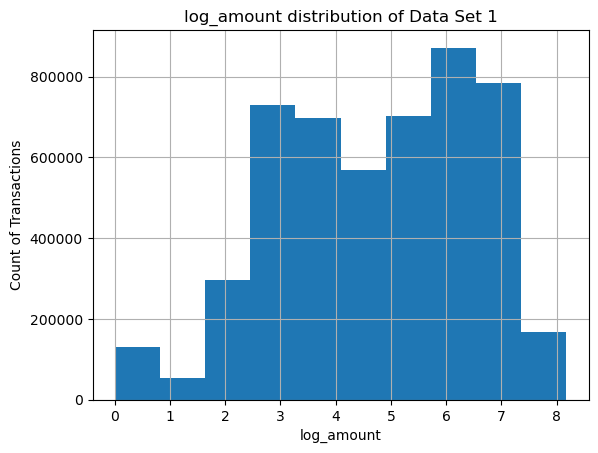

In [179]:
# Histogram of the amount after applying log transformation
fig = plt.figure()
finanical_data_process.hist('log_amount', bins = 10)
plt.title('log_amount distribution of Data Set 1')
plt.xlabel('log_amount')
plt.ylabel('Count of Transactions')
plt.show()

<b>Results</b><br>
Per inspected, after log-transformation is applied, the histogram becomes bimodal distribution.

#### 5.1.3 transaction_type

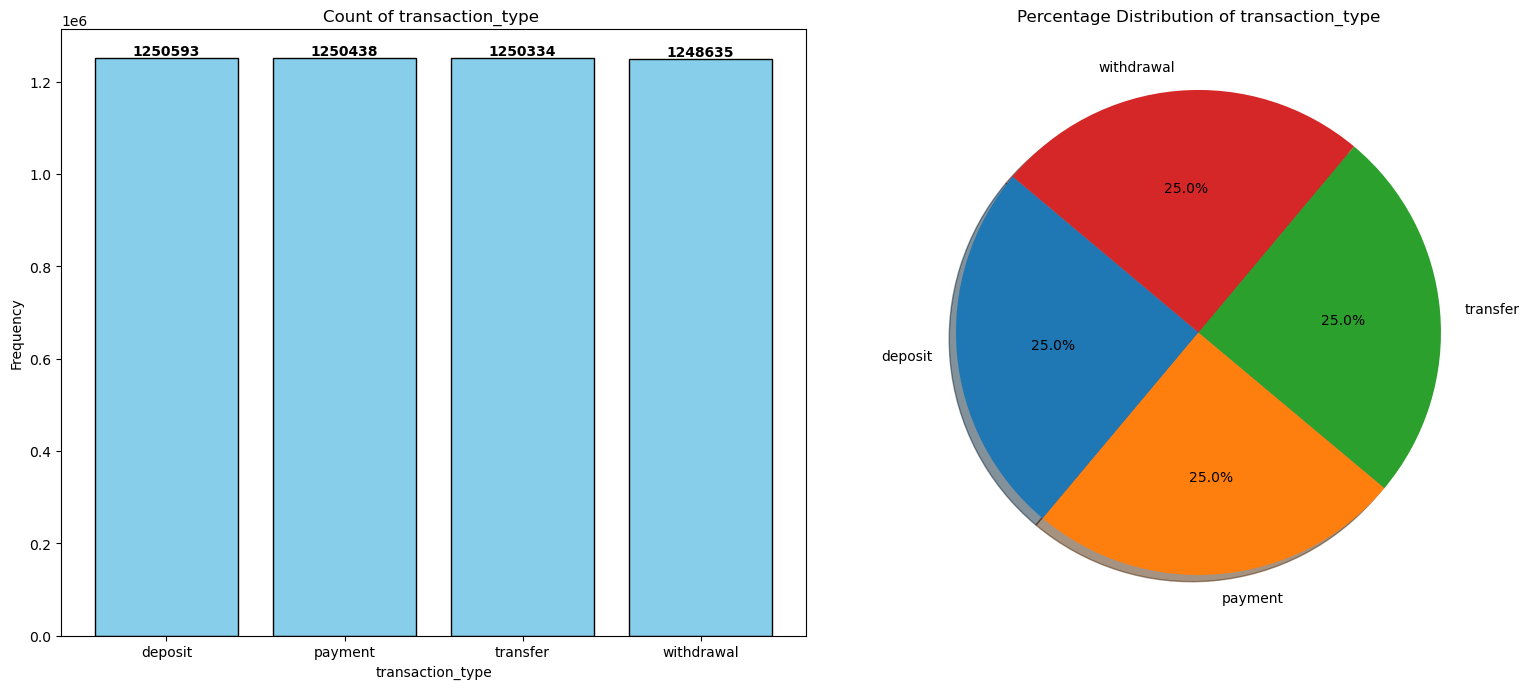

In [180]:
counts = finanical_data_process['transaction_type'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of transaction_type ')
ax[0].set_xlabel('transaction_type')
ax[0].set_ylabel('Frequency')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of transaction_type')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, each type of `transaction_type` is evenly distributed given that this is system generated data.

#### 5.1.4 merchant_category

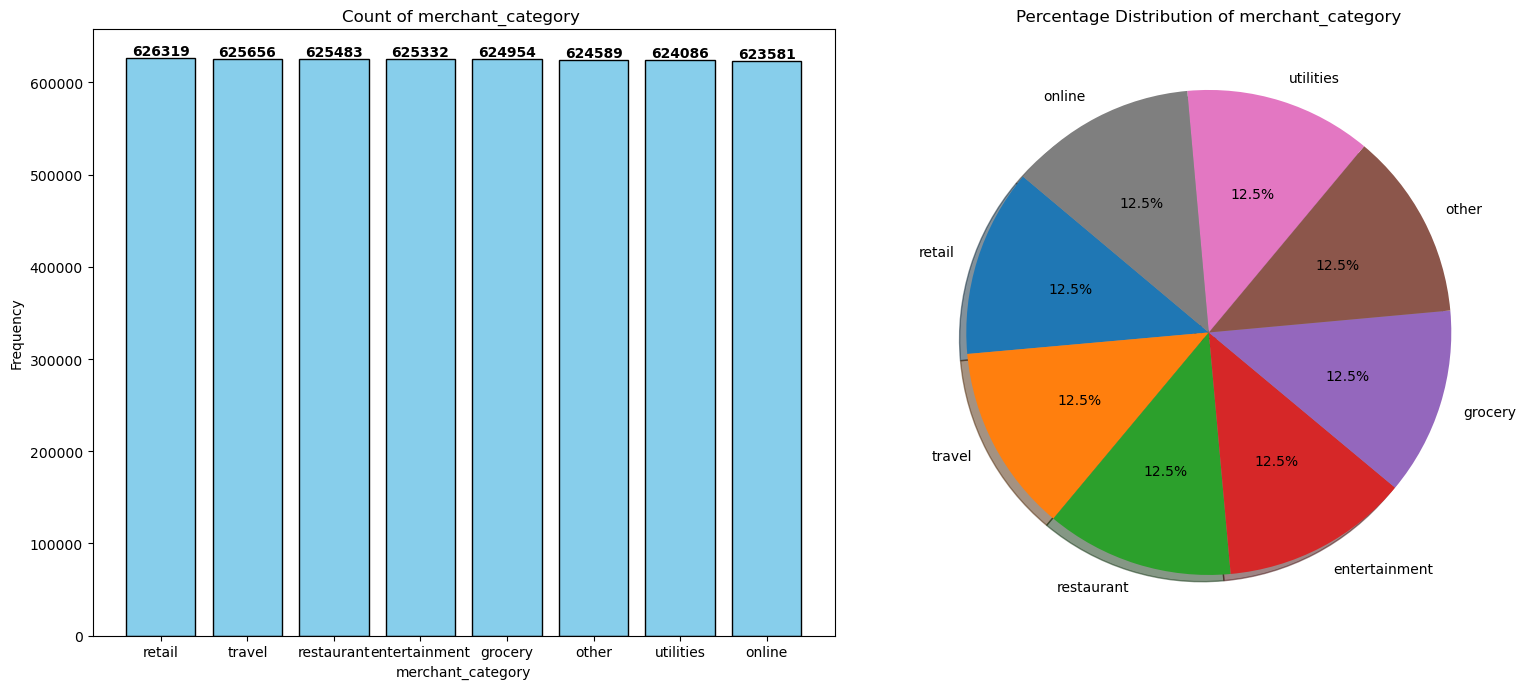

In [181]:
counts = finanical_data_process['merchant_category'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of merchant_category ')
ax[0].set_xlabel('merchant_category')
ax[0].set_ylabel('Frequency')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of merchant_category')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, each type of `merchant_category` is evenly distributed given that this is system generated data.

#### 5.1.4 location

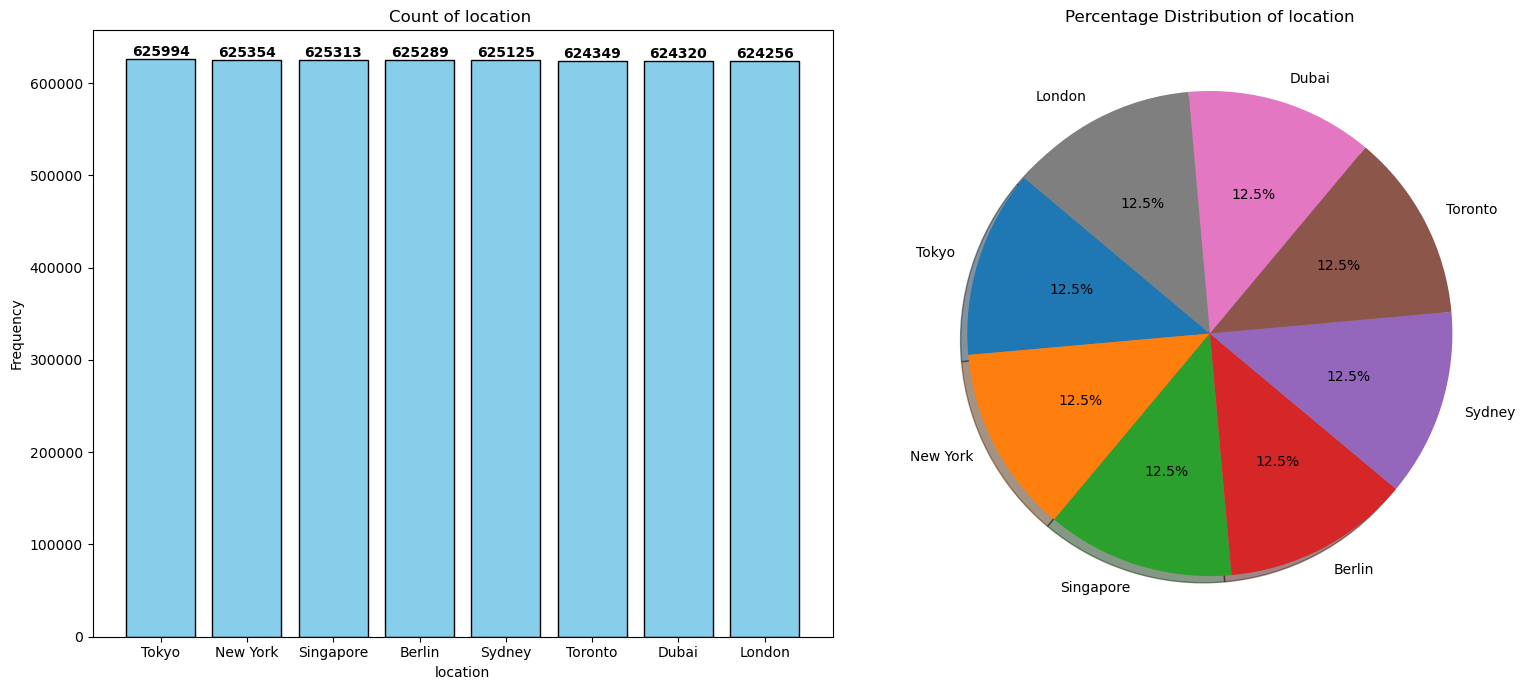

In [182]:
counts = finanical_data_process['location'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of location ')
ax[0].set_xlabel('location')
ax[0].set_ylabel('Frequency')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of location')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, each type of `location` is evenly distributed given that this is system generated data.

#### 5.1.5 device_used

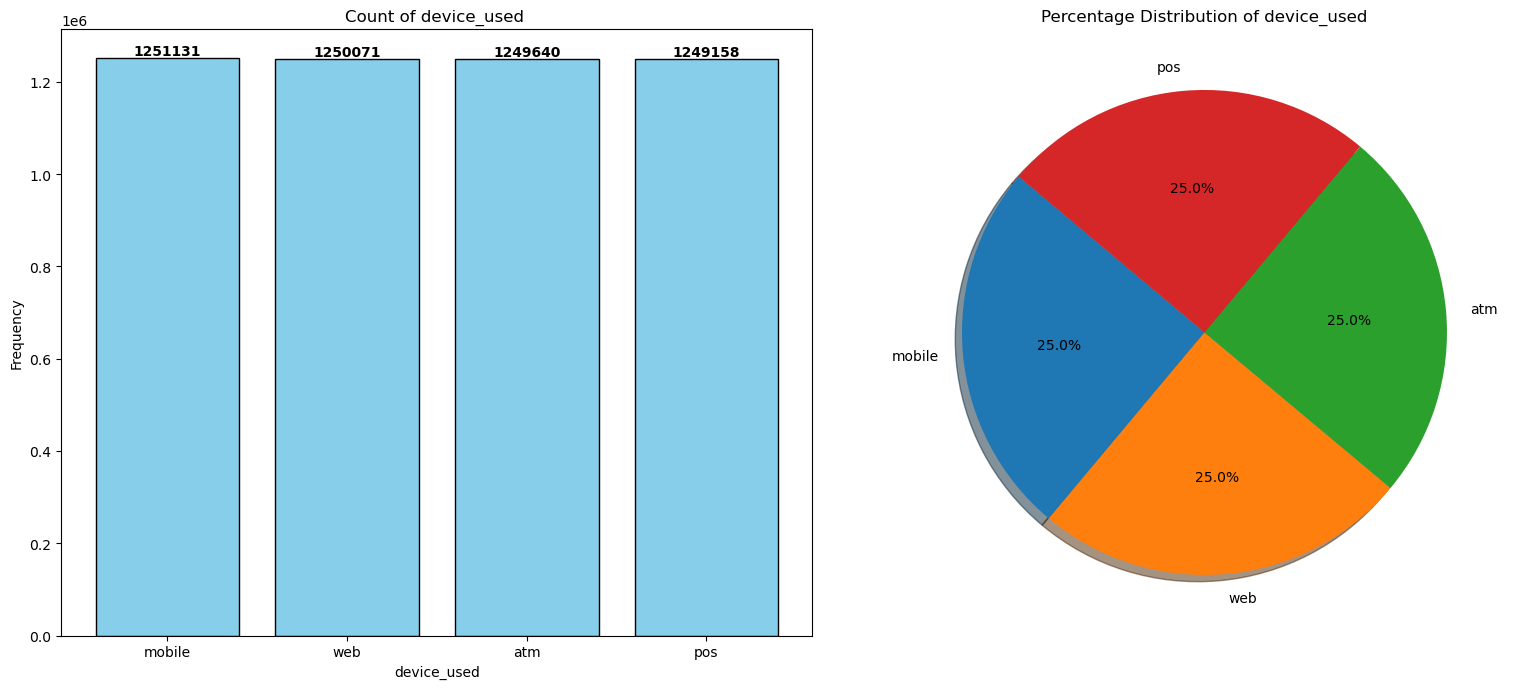

In [183]:
counts = finanical_data_process['device_used'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of device_used ')
ax[0].set_xlabel('device_used')
ax[0].set_ylabel('Frequency')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of device_used')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, each type of `device_used` is evenly distributed given that this is system generated data.

#### 5.1.6 is_fraud

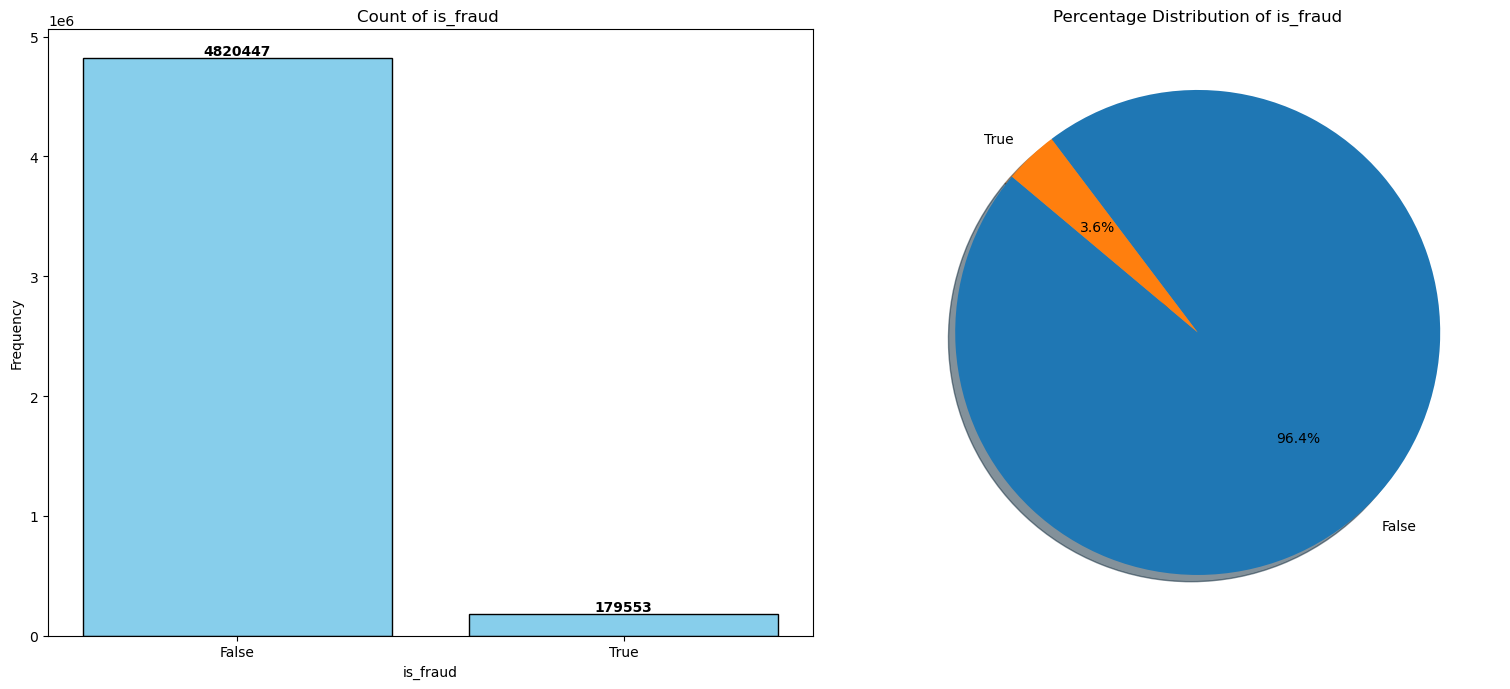

In [184]:
counts = finanical_data_process['is_fraud'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of is_fraud ')
ax[0].set_xlabel('is_fraud')
ax[0].set_ylabel('Frequency')
ax[0].set_xticks(range(len(counts)))
ax[0].set_xticklabels(counts.index.astype(str))

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of is_fraud')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `is_fraud` shows the class imbalance situation that only 3.6% of data is Fraud transactions while 96.4% of data is Normal transaction.

#### 5.1.7 time_since_last_transaction

<Figure size 640x480 with 0 Axes>

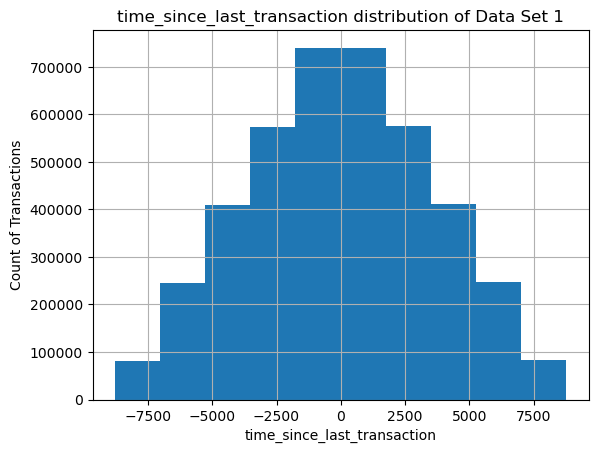

In [185]:
# Histogram of the time_since_last_transaction
fig = plt.figure()
finanical_data_process.hist('time_since_last_transaction', bins = 10)
plt.title('time_since_last_transaction distribution of Data Set 1')
plt.xlabel('time_since_last_transaction')
plt.ylabel('Count of Transactions')
plt.show()

<b>Results</b><br>
Per inspected, `time_since_last_transaction` shows a normal distribution.

#### 5.1.8 spending_deviation_score

<Figure size 640x480 with 0 Axes>

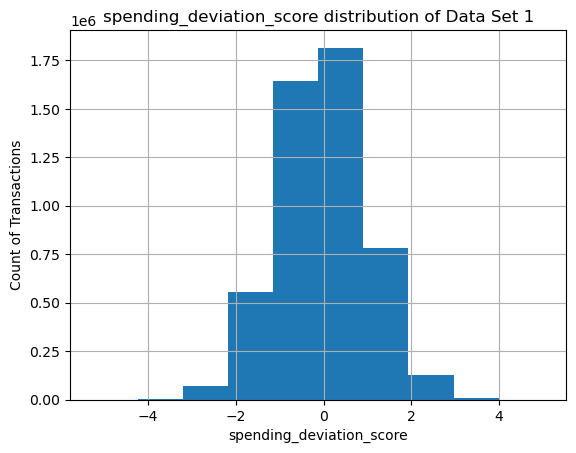

In [186]:
# Histogram of the spending_deviation_score
fig = plt.figure()
finanical_data_process.hist('spending_deviation_score', bins = 10)
plt.title('spending_deviation_score distribution of Data Set 1')
plt.xlabel('spending_deviation_score')
plt.ylabel('Count of Transactions')
plt.show()

<b>Results</b><br>
Per inspected, `spending_deviation_score` shows a normal distribution.

#### 5.1.9 velocity_score

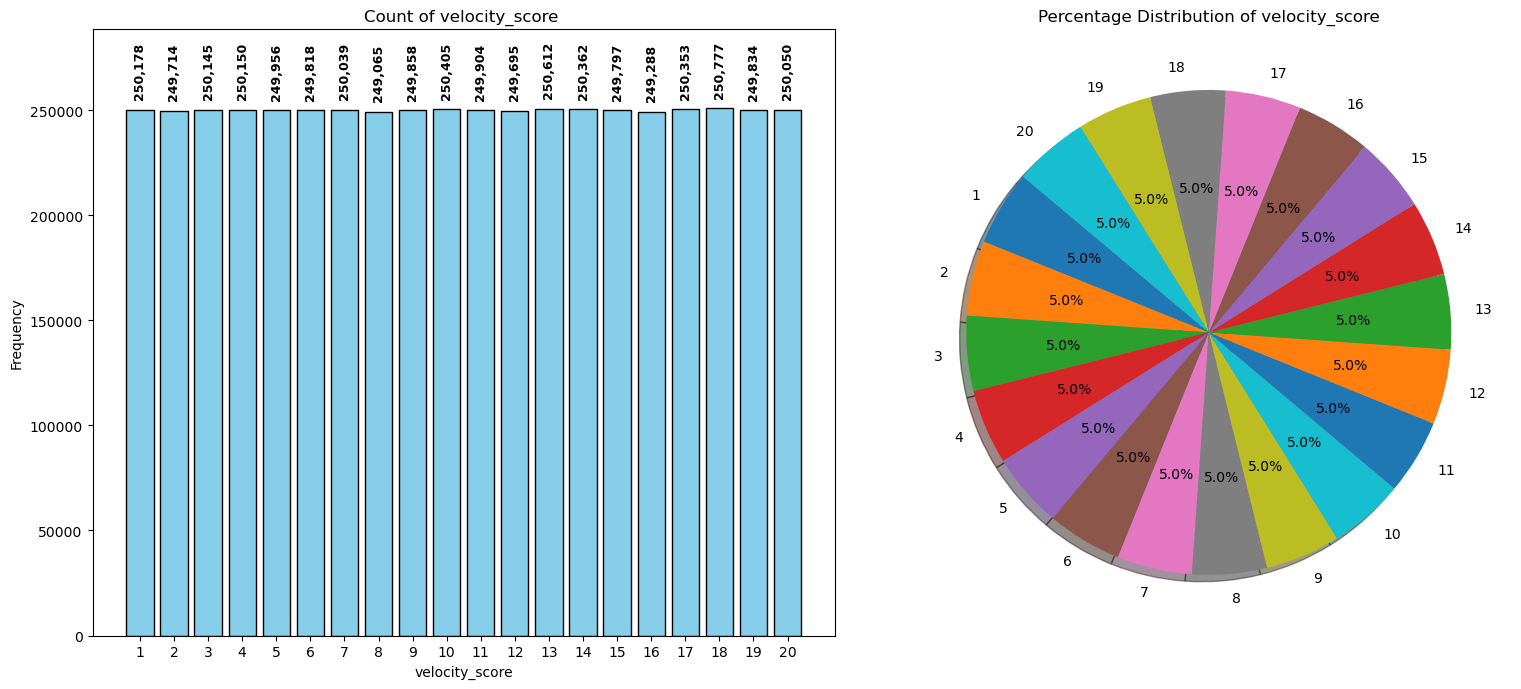

In [187]:
counts = finanical_data_process['velocity_score'].value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

positions = range(len(counts))
x_labels = counts.index.astype(str)

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of velocity_score ')
ax[0].set_xlabel('velocity_score')
ax[0].set_ylabel('Frequency')
ax[0].set_xticks(counts.index)
ax[0].set_xticklabels(counts.index)

# Add text labels on top of bars
max_val = counts.values.max()
for bar in bars:
    yval = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width()/2,
        yval + (max_val * 0.02),        
        f"{int(yval):,}",
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=9,
        rotation=90
    )
ax[0].set_ylim(0, max_val * 1.15)

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of velocity_score')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, each type of `velocity_score` is evenly distributed given that this is system generated data.

#### 5.1.10 payment_channel

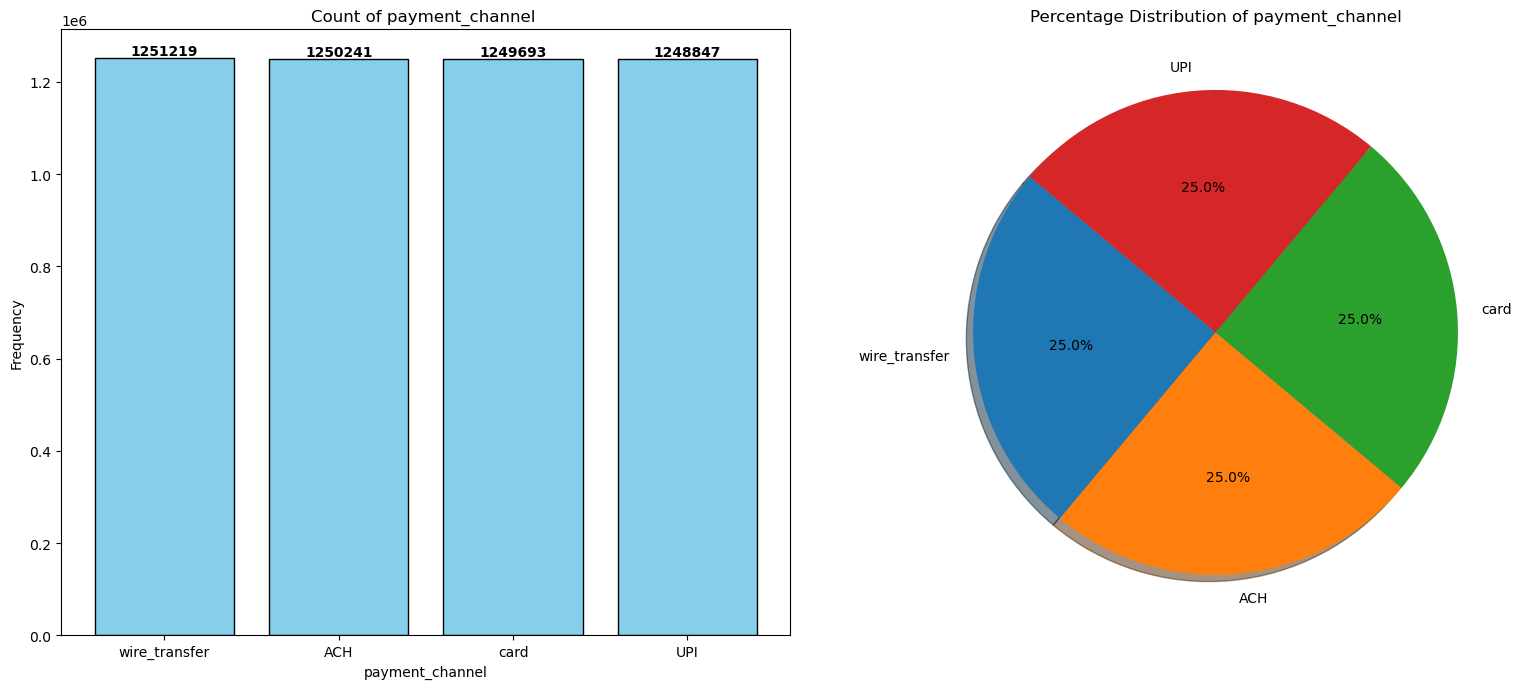

In [188]:
counts = finanical_data_process['payment_channel'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of payment_channel ')
ax[0].set_xlabel('payment_channel')
ax[0].set_ylabel('Frequency')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of payment_channel')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, each type of `payment_channel` is evenly distributed given that this is system generated data.

### 5.2 Data Set 2

#### 5.2.1 Transaction_DateTime

In [189]:
# 1. Monthly components
banking_data_process['Month'] = banking_data_process['Transaction_DateTime'].dt.to_period('M').astype(str)
# 2. Daily components (Day Name ensures a clean order: Monday, Tuesday, etc.)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
banking_data_process['Day_of_Week'] = banking_data_process['Transaction_DateTime'].dt.day_name()
banking_data_process['Day_of_Week'] = pd.Categorical(banking_data_process['Day_of_Week'], categories=day_order, ordered=True)
banking_data_process["txn_day_of_week"] = banking_data_process["Transaction_DateTime"].dt.dayofweek.astype('Int64')
banking_data_process["is_weekend"] = banking_data_process["txn_day_of_week"].isin([5, 6]).astype('Int64')
# 3. Hourly components
banking_data_process['Hour'] = banking_data_process['Transaction_DateTime'].dt.hour.astype('Int64')
banking_data_process["is_night"] = banking_data_process["Hour"].between(0, 5).astype('Int64')

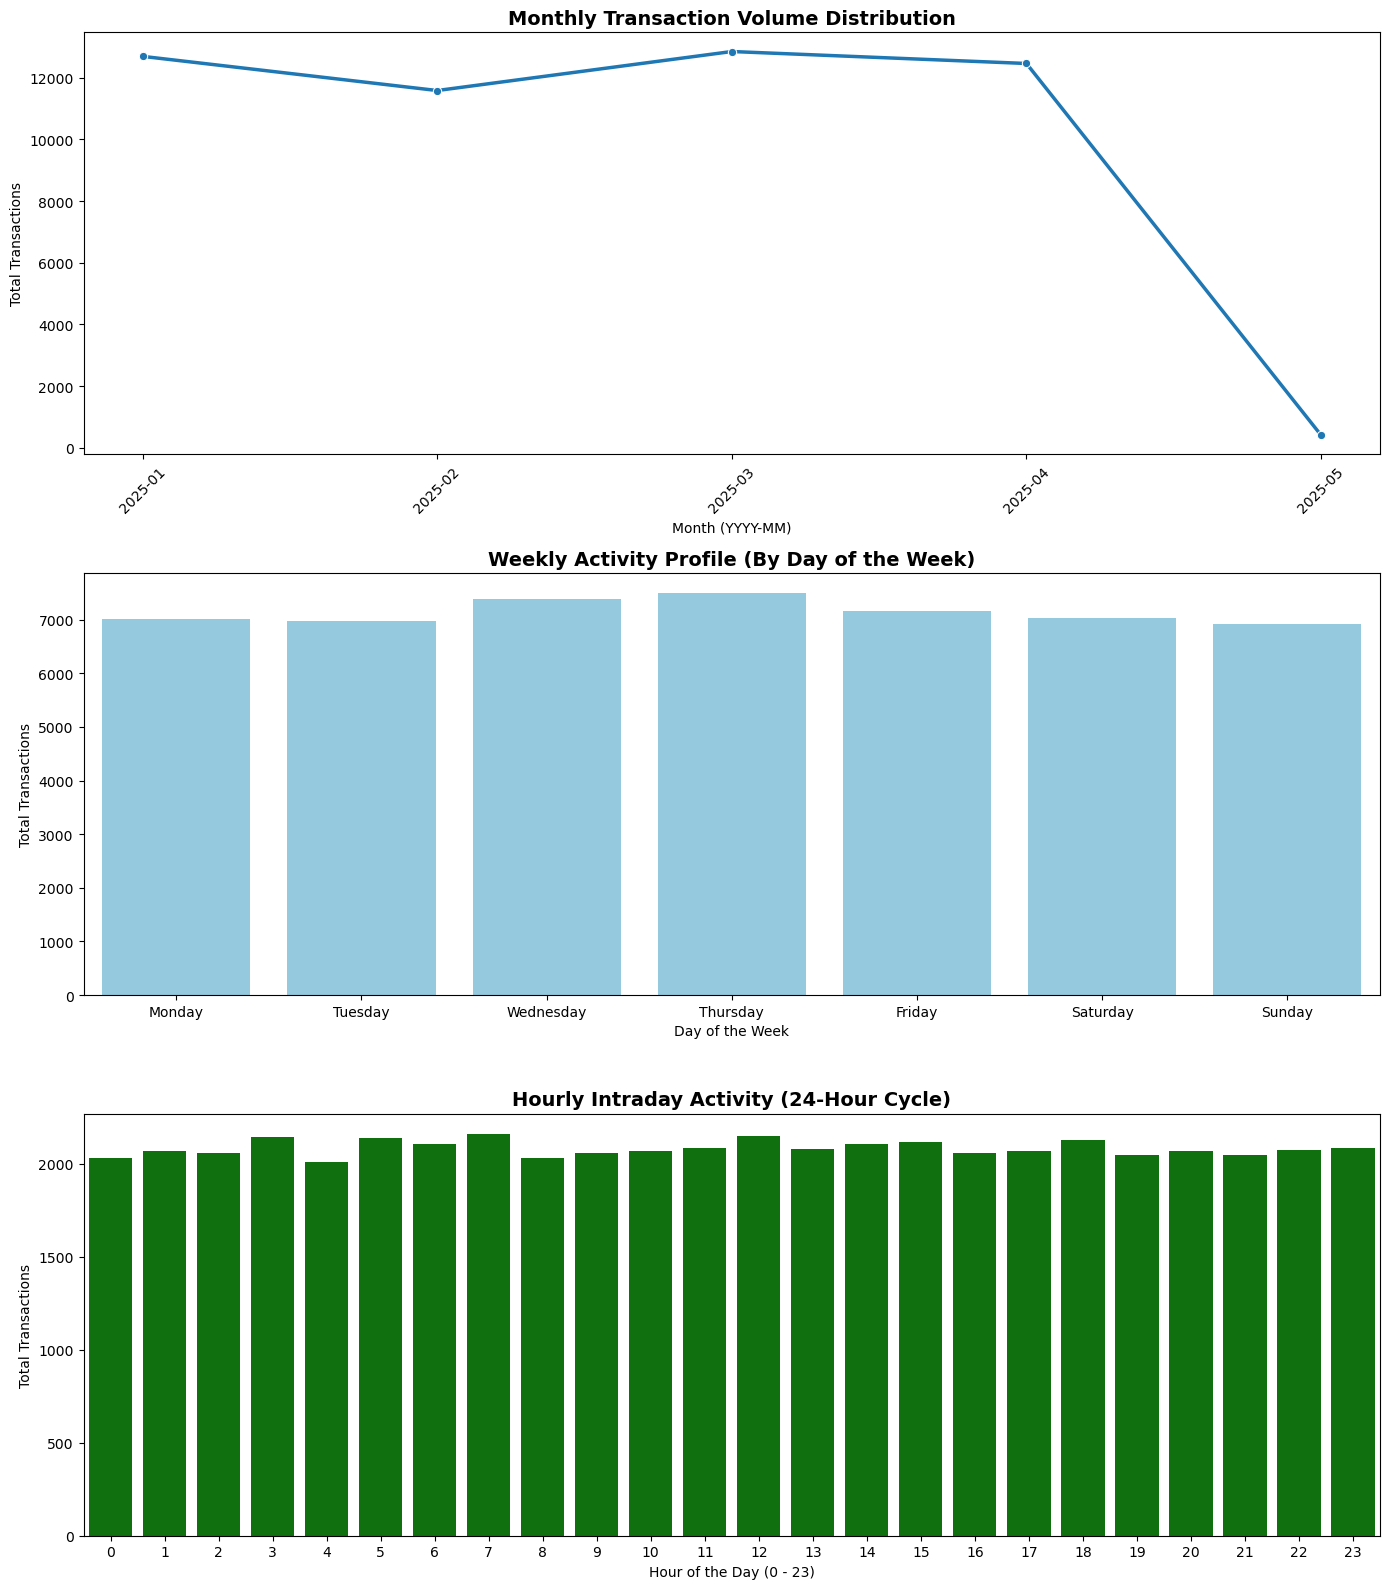

In [190]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# Monthly Trends (Line Chart)
monthly_counts = banking_data_process.groupby('Month').size().reset_index(name='Count')
sns.lineplot(ax=axes[0], data=monthly_counts, x='Month', y='Count', marker='o', color='#1f77b4', linewidth=2.5)
axes[0].set_title('Monthly Transaction Volume Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month (YYYY-MM)')
axes[0].set_ylabel('Total Transactions')
axes[0].tick_params(axis='x', rotation=45)

# Daily Trends (Bar Chart) 
daily_counts = banking_data_process.groupby('Day_of_Week', observed=False).size().reset_index(name='Count')
sns.barplot(ax=axes[1], data=daily_counts, x='Day_of_Week', y='Count', color='skyblue')
axes[1].set_title('Weekly Activity Profile (By Day of the Week)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day of the Week')
axes[1].set_ylabel('Total Transactions')

# ---- Panel 3: Hourly Trends (Bar Chart) ----
hourly_counts = banking_data_process.groupby('Hour').size().reset_index(name='Count')
sns.barplot(ax=axes[3 if False else 2], data=hourly_counts, x='Hour', y='Count', color='green')
axes[2].set_title('Hourly Intraday Activity (24-Hour Cycle)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Hour of the Day (0 - 23)')
axes[2].set_ylabel('Total Transactions')

plt.tight_layout()
plt.show()


Prelim insight:

- Transaction volume remains stable and consistent from January 2025 through April 2025 from both monthly, weekly and hourly basis.
- There is a severe and near-vertical drop-off in transaction volume in May 2025. This likely indicates incomplete data for that month (e.g., pulling data on Jan 1st or 2nd) rather than a real business crash.
- There is zero drop-off on Saturday and Sunday, probably due to an automated system with 24-hours global service, or e-commerce processing that also works over weekends.
- Human behavior naturally creates peaks during daytime hours and drops during sleep hours (1 AM – 5 AM). Yet, this hourly chart is perfectly uniform given that this is a system generated data.

#### 5.2.2 Transaction_Amount (in Million)

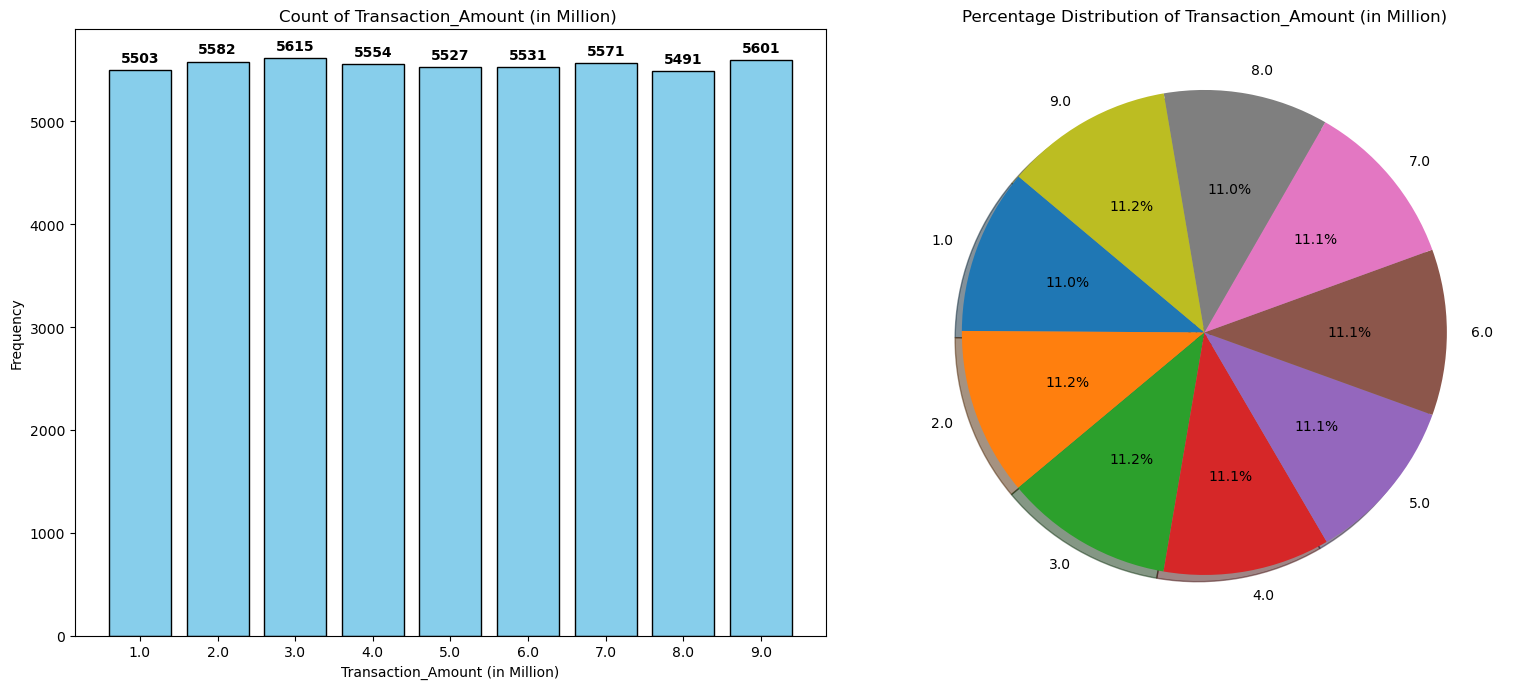

In [191]:
counts = banking_data_process['Transaction_Amount (in Million)'].value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Transaction_Amount (in Million) ')
ax[0].set_xlabel('Transaction_Amount (in Million)')
ax[0].set_ylabel('Frequency')
ax[0].set_xticks(counts.index)
ax[0].set_xticklabels(counts.index)

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Transaction_Amount (in Million)')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Transaction_Amount (in Million)` ranges from 1 to 9 with evenly distributed given that this is system generated data.

#### 5.2.3 Distance_From_Home

<Figure size 640x480 with 0 Axes>

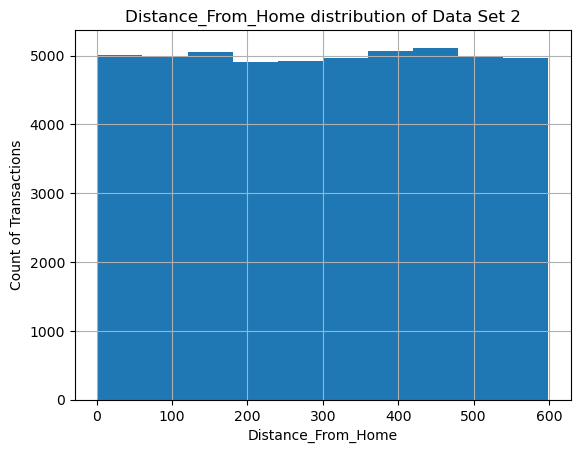

In [192]:
# Histogram of the Distance_From_Home
fig = plt.figure()
banking_data_process.hist('Distance_From_Home', bins = 10)
plt.title('Distance_From_Home distribution of Data Set 2')
plt.xlabel('Distance_From_Home')
plt.ylabel('Count of Transactions')
plt.show()

<b>Results</b><br>
Per inspected, `Distance_From_Home (in Million)` shows a uniform distribution given that this is system generated data.

#### 5.2.4 Daily_Transaction_Count

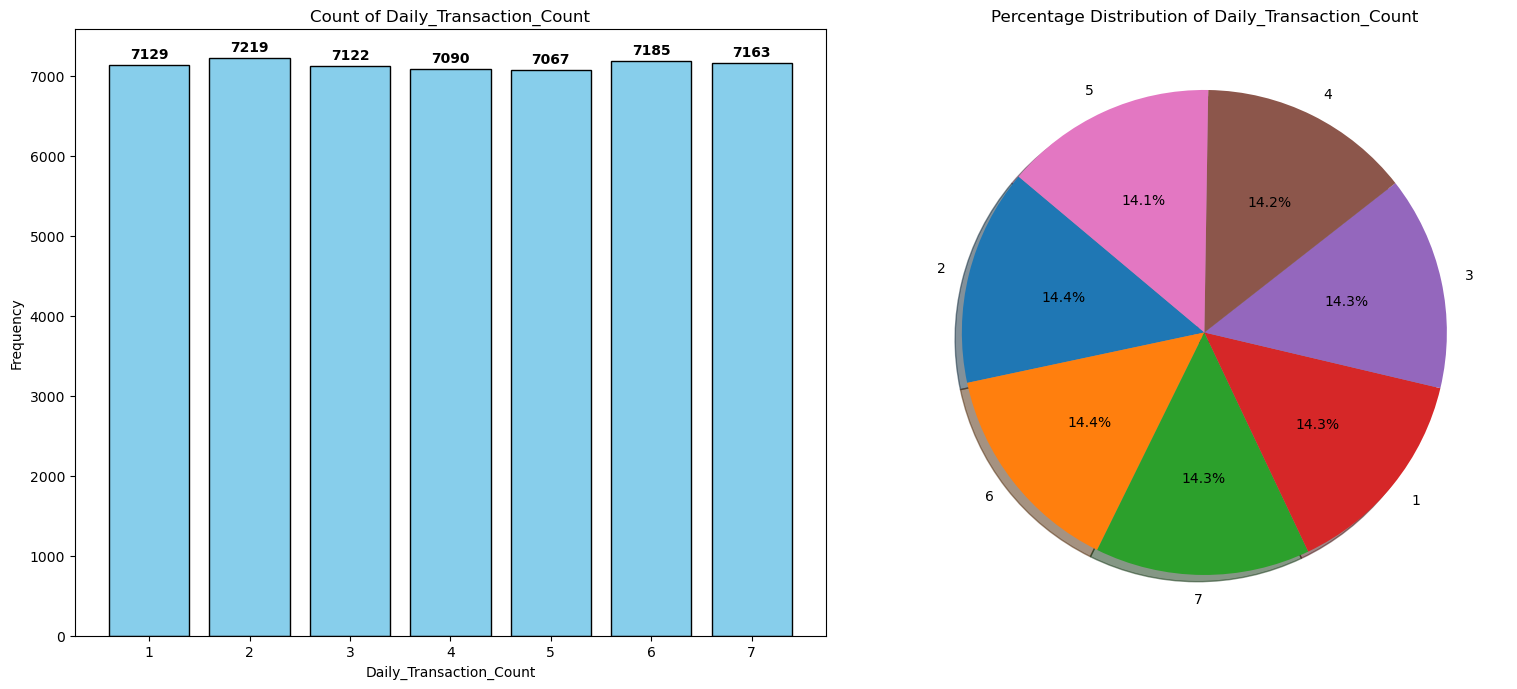

In [193]:
counts = banking_data_process['Daily_Transaction_Count'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Daily_Transaction_Count')
ax[0].set_xlabel('Daily_Transaction_Count')
ax[0].set_ylabel('Frequency')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Daily_Transaction_Count')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Daily_Transaction_Count` ranges from 1 to 7 with evenly distributed given that this is system generated data.

#### 5.2.5 Weekly_Transaction_Count

<Figure size 640x480 with 0 Axes>

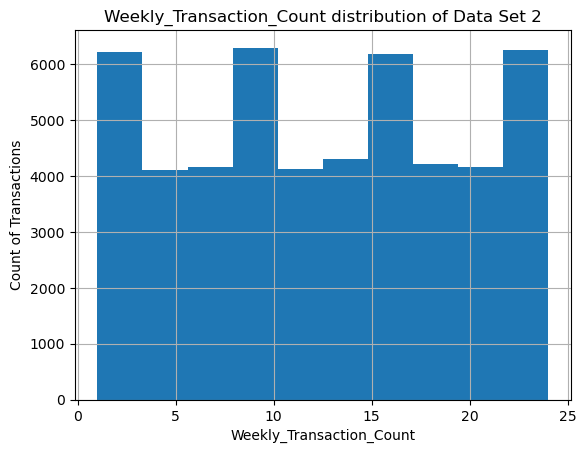

In [194]:
# Histogram of the Weekly_Transaction_Count
fig = plt.figure()
banking_data_process.hist('Weekly_Transaction_Count', bins = 10)
plt.title('Weekly_Transaction_Count distribution of Data Set 2')
plt.xlabel('Weekly_Transaction_Count')
plt.ylabel('Count of Transactions')
plt.show()

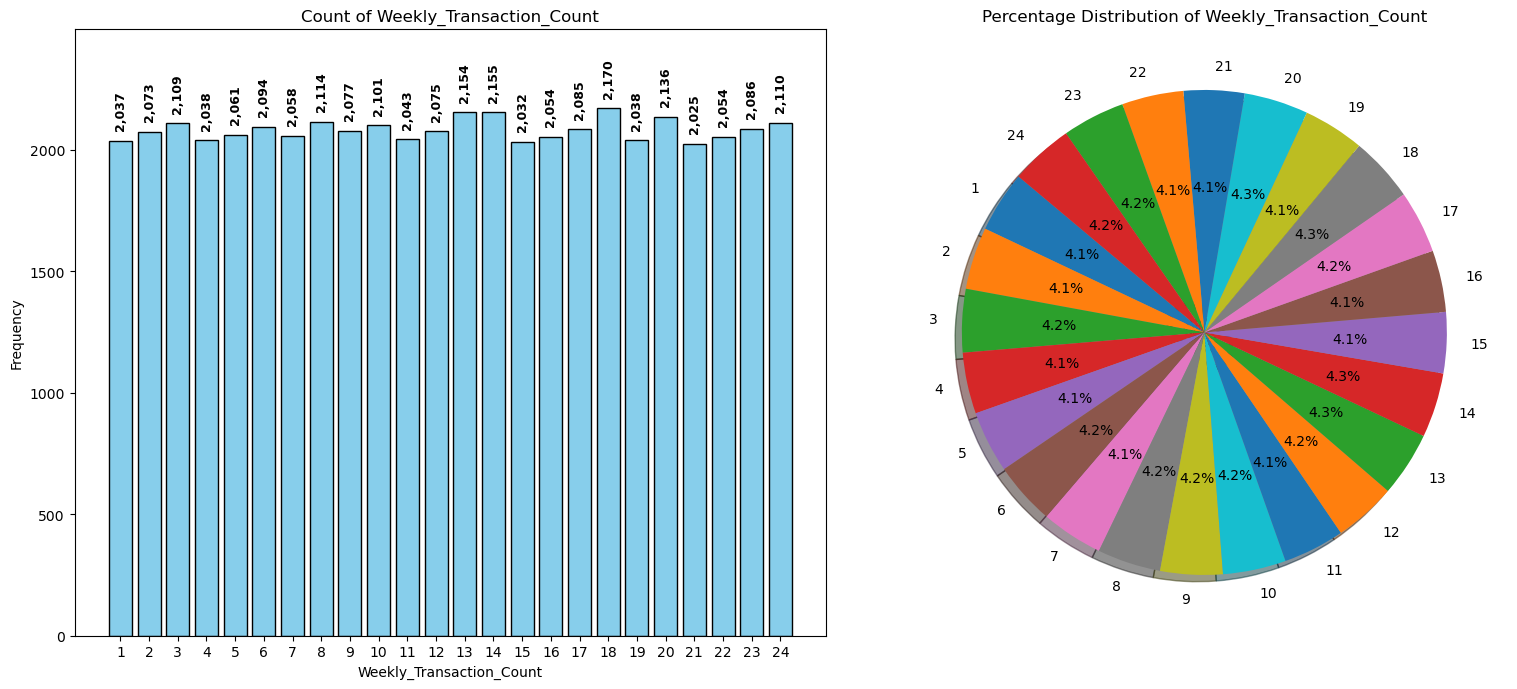

In [195]:
counts = banking_data_process['Weekly_Transaction_Count'].value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

positions = range(len(counts))
x_labels = counts.index.astype(str)

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Weekly_Transaction_Count')
ax[0].set_xlabel('Weekly_Transaction_Count')
ax[0].set_ylabel('Frequency')
ax[0].set_xticks(counts.index)
ax[0].set_xticklabels(counts.index)

# Add text labels on top of bars
max_val = counts.values.max()
for bar in bars:
    yval = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width()/2,
        yval + (max_val * 0.02),        
        f"{int(yval):,}",
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=9,
        rotation=90
    )
ax[0].set_ylim(0, max_val * 1.15)

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Weekly_Transaction_Count')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Weekly_Transaction_Count` ranges from 1 to 24 with almost evenly distributed given that this is system generated data.

#### 5.2.6 Avg_Transaction_Amount (in Million)

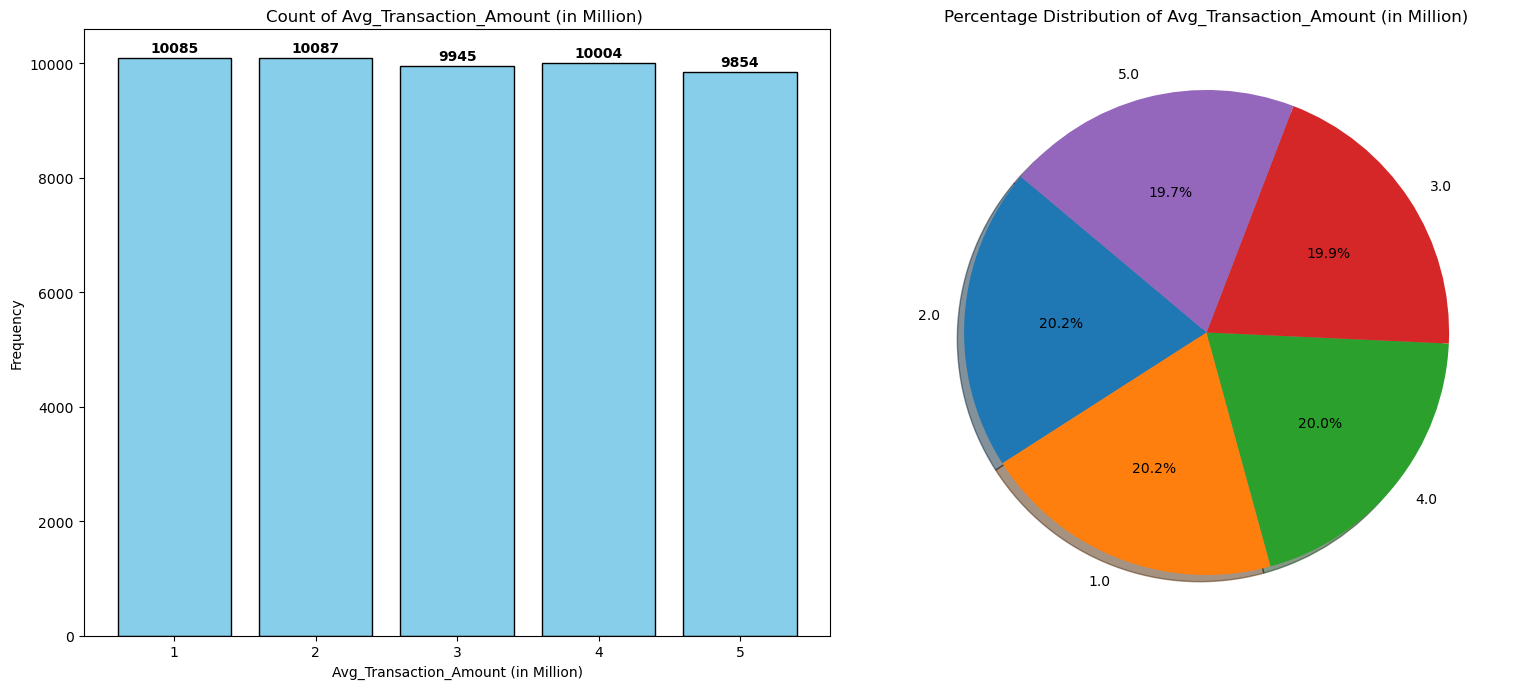

In [196]:
counts = banking_data_process['Avg_Transaction_Amount (in Million)'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Avg_Transaction_Amount (in Million) ')
ax[0].set_xlabel('Avg_Transaction_Amount (in Million)')
ax[0].set_ylabel('Frequency')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Avg_Transaction_Amount (in Million)')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Avg_Transaction_Amount (in Million)` ranges from 1 to 5 with almost evenly distributed given that this is system generated data.

#### 5.2.7 Max_Transaction_Last_24h (in Million)

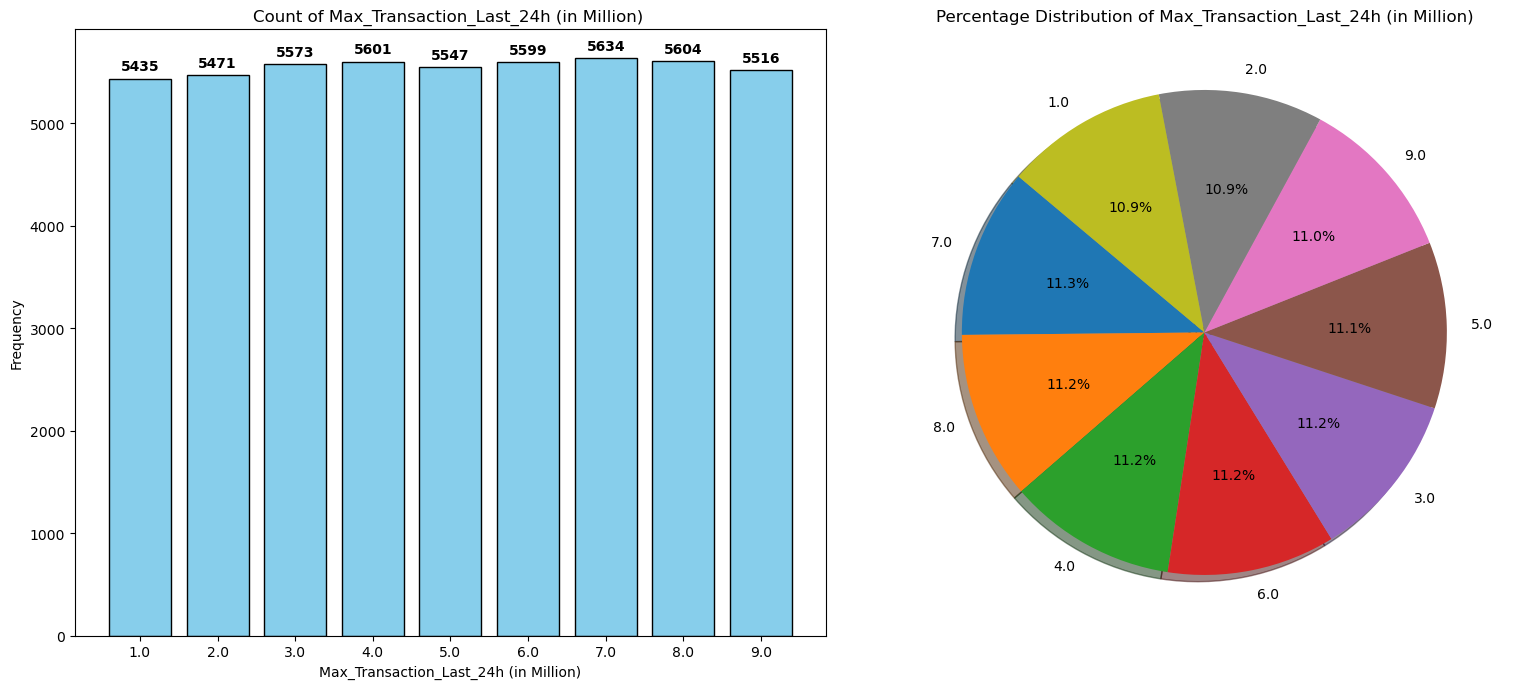

In [197]:
counts = banking_data_process['Max_Transaction_Last_24h (in Million)'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Max_Transaction_Last_24h (in Million) ')
ax[0].set_xlabel('Max_Transaction_Last_24h (in Million)')
ax[0].set_ylabel('Frequency')
ax[0].set_xticks(counts.index)
ax[0].set_xticklabels(counts.index)
# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Max_Transaction_Last_24h (in Million)')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Max_Transaction_Last_24h (in Million)` ranges from 1 to 9 with evenly distributed given that this is system generated data.

#### 5.2.8 Failed_Transaction_Count

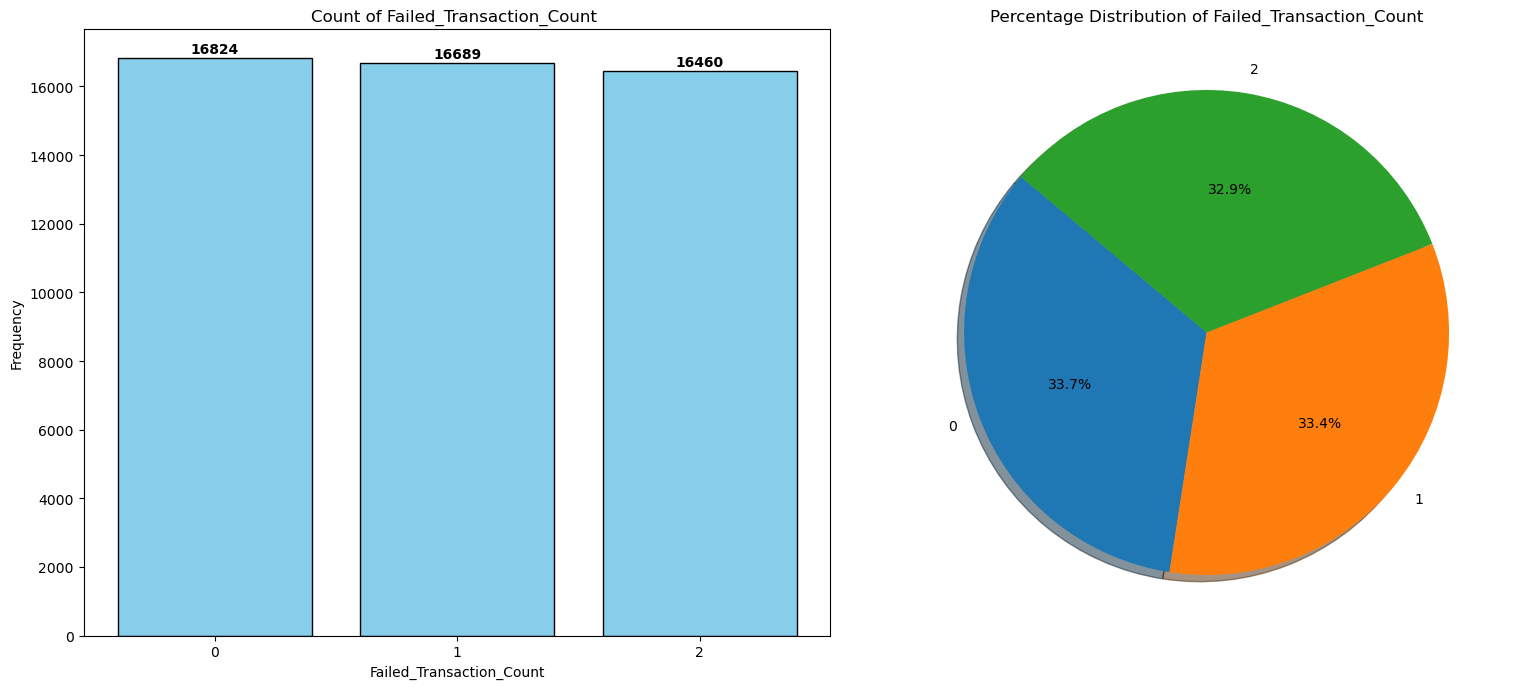

In [198]:
counts = banking_data_process['Failed_Transaction_Count'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Failed_Transaction_Count ')
ax[0].set_xlabel('Failed_Transaction_Count')
ax[0].set_ylabel('Frequency')
ax[0].set_xticks(counts.index)
ax[0].set_xticklabels(counts.index)

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Failed_Transaction_Count')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Failed_Transaction_Count` ranges from 0 to 2 with evenly distributed given that this is system generated data.

#### 5.2.9 Previous_Fraud_Count

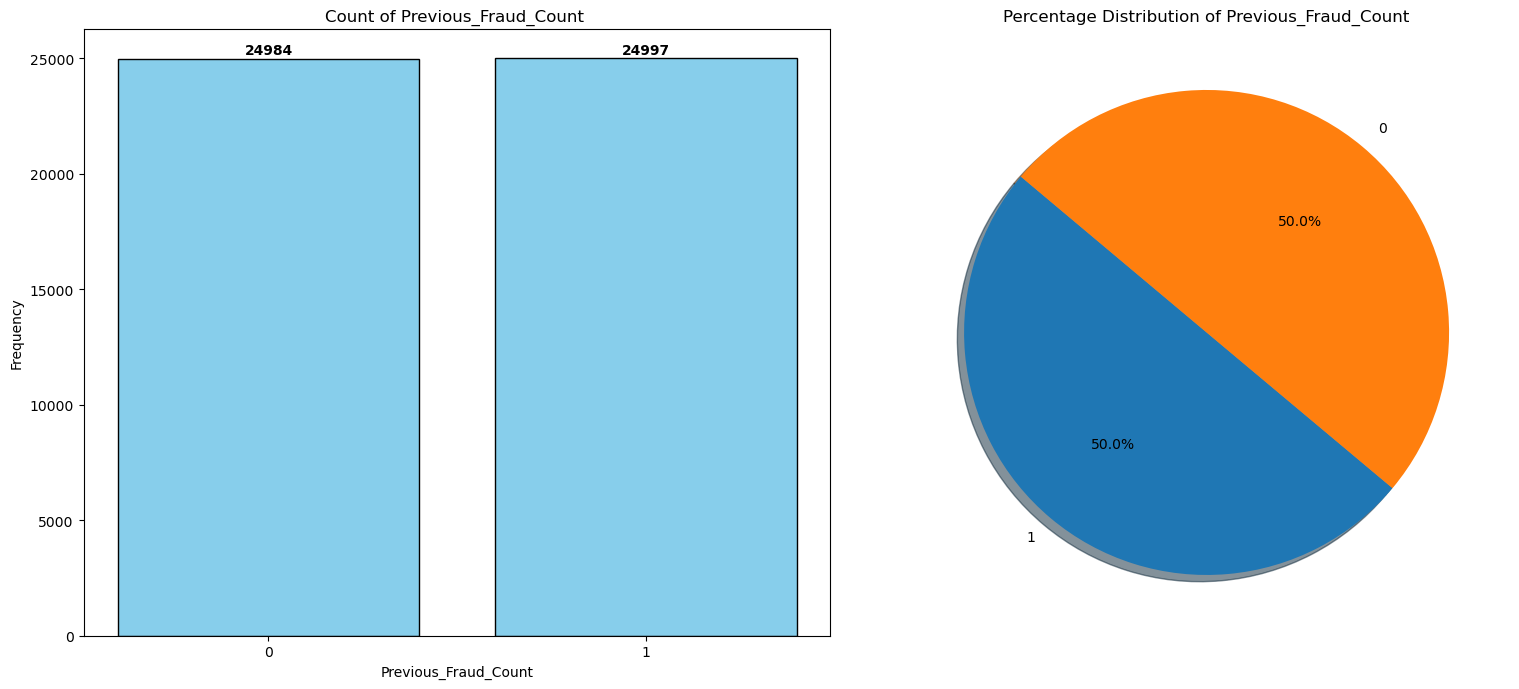

In [199]:
counts = banking_data_process['Previous_Fraud_Count'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Previous_Fraud_Count ')
ax[0].set_xlabel('Previous_Fraud_Count')
ax[0].set_ylabel('Frequency')
ax[0].set_xticks(counts.index)
ax[0].set_xticklabels(counts.index)
# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Previous_Fraud_Count')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Previous_Fraud_Count` ranges from 0 to 1 with evenly distributed given that this is system generated data.

#### 5.2.10 Transaction_Type

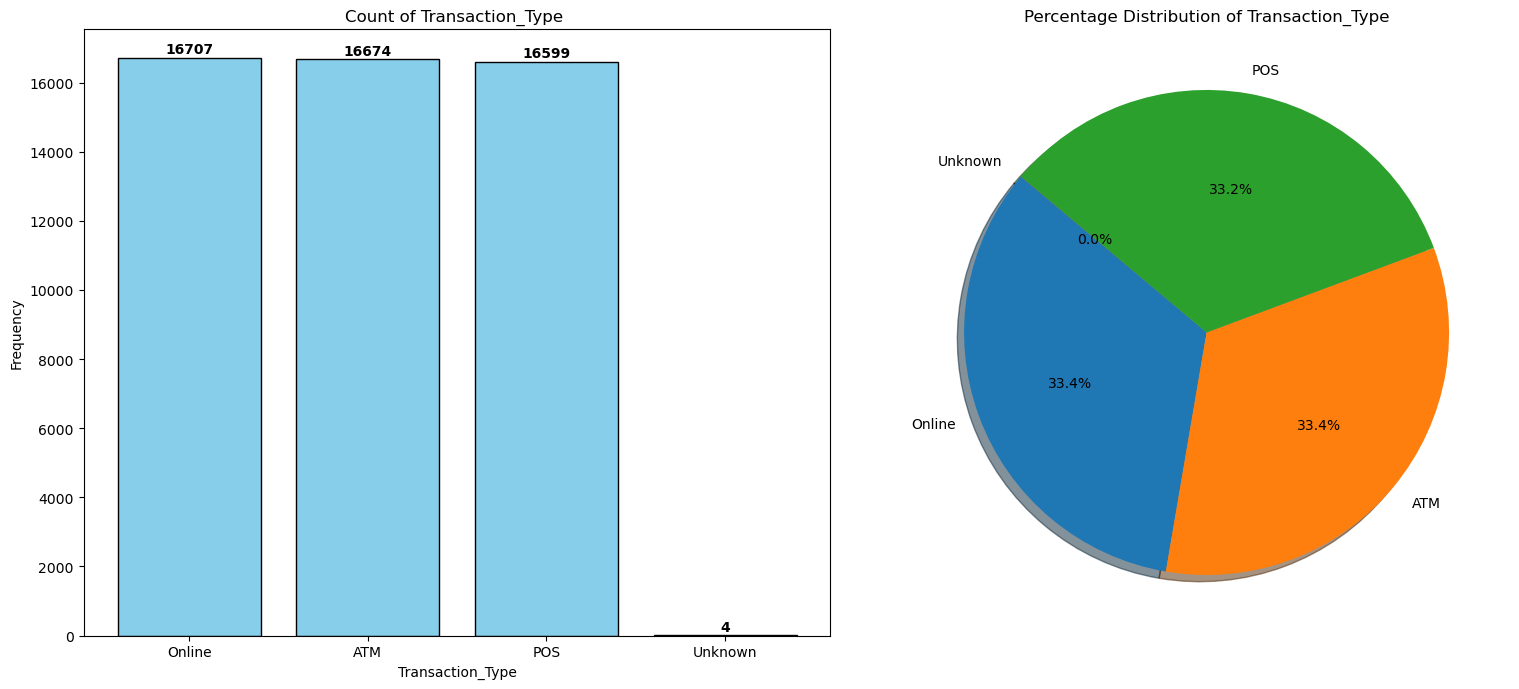

In [200]:
counts = banking_data_process['Transaction_Type'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Transaction_Type ')
ax[0].set_xlabel('Transaction_Type')
ax[0].set_ylabel('Frequency')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Transaction_Type')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Transaction_Type` includes 3 types with evenly distributed given that this is system generated data while Unknown is converted from missing value with minimal

#### 5.2.11 Merchant_Category

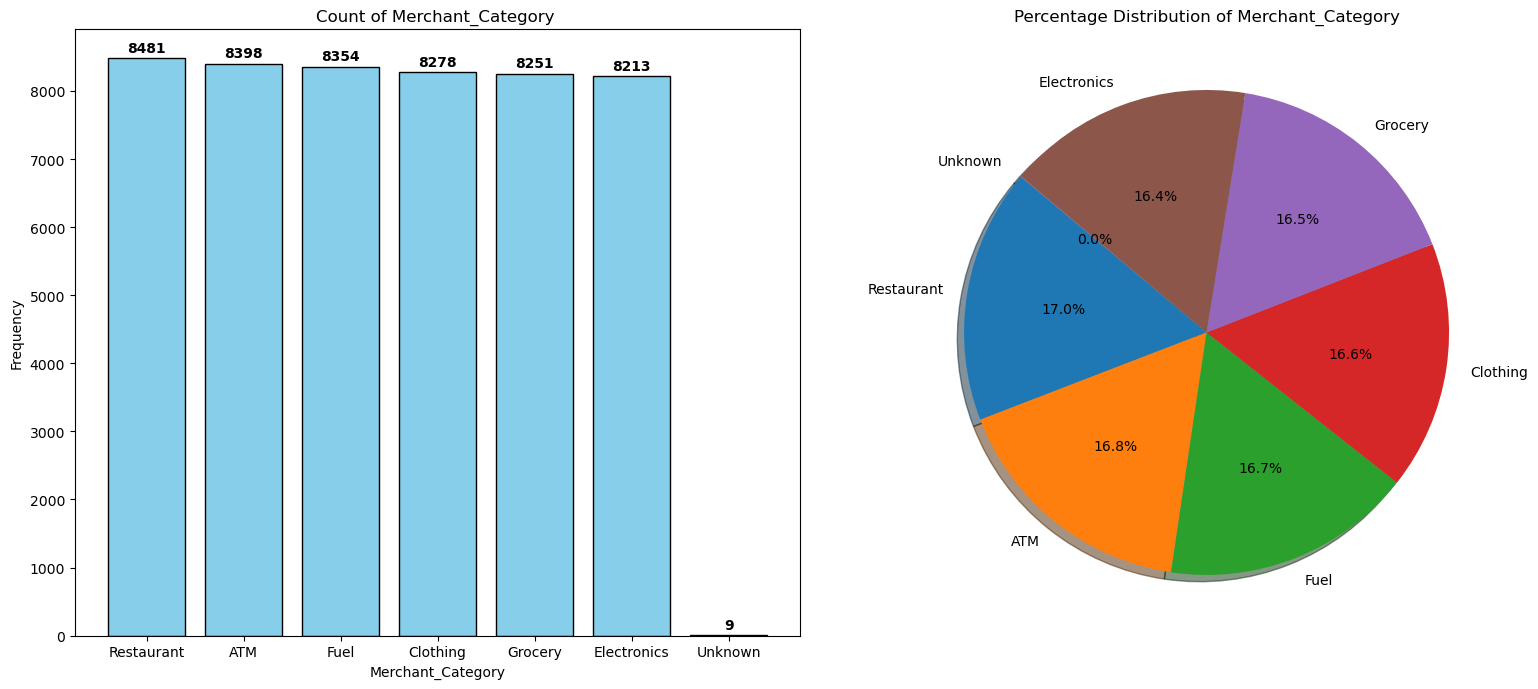

In [201]:
counts = banking_data_process['Merchant_Category'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Merchant_Category ')
ax[0].set_xlabel('Merchant_Category')
ax[0].set_ylabel('Frequency')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Merchant_Category')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Merchant_Category` includes 6 types with evenly distributed given that this is system generated data while Unknown is converted from missing value with minimal

#### 5.2.12 Transaction_Location

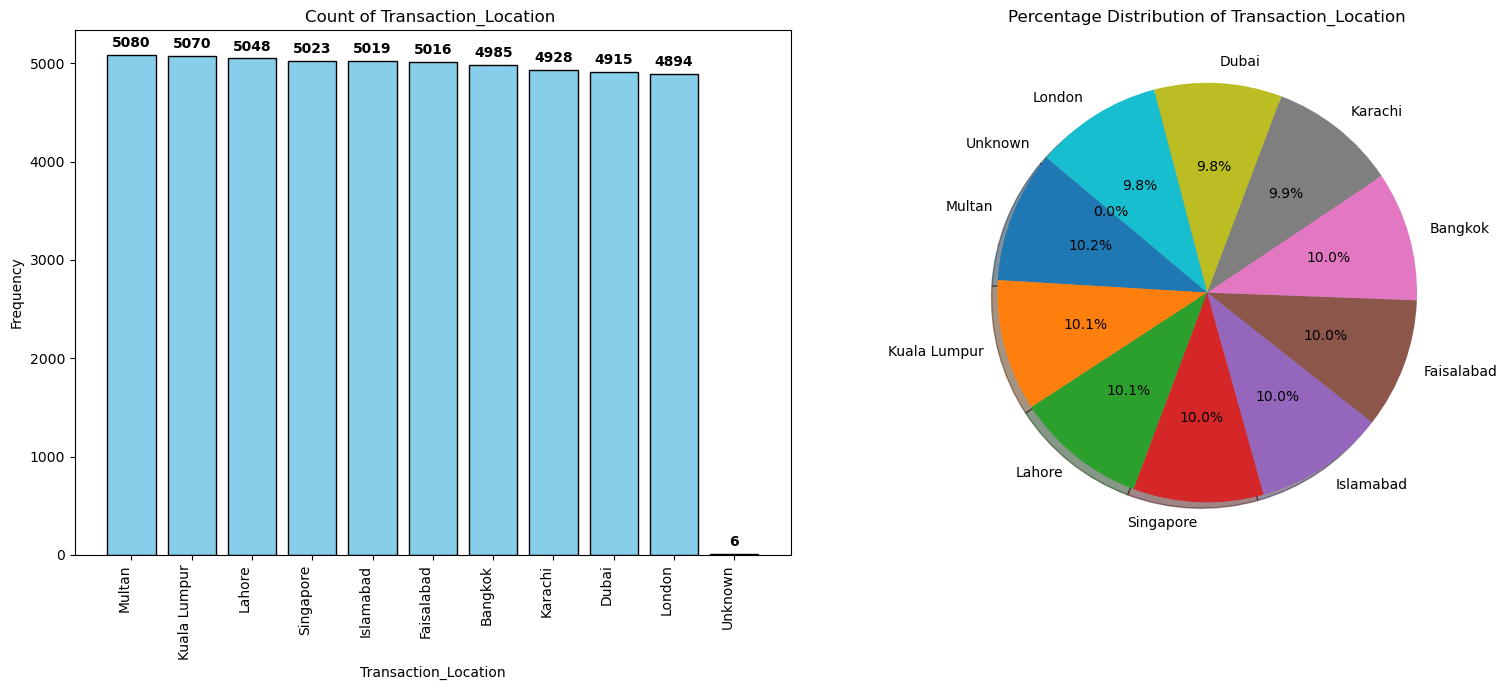

In [202]:
counts = banking_data_process['Transaction_Location'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Transaction_Location ')
ax[0].set_xlabel('Transaction_Location')
ax[0].set_ylabel('Frequency')
ax[0].set_xticks(range(len(counts)))
ax[0].set_xticklabels(counts.index, rotation=90, ha='right')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Transaction_Location')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Transaction_Location` includes 10 types with almost evenly distributed given that this is system generated data while Unknown is converted from missing value with minimal

#### 5.2.13 Customer_Home_Location

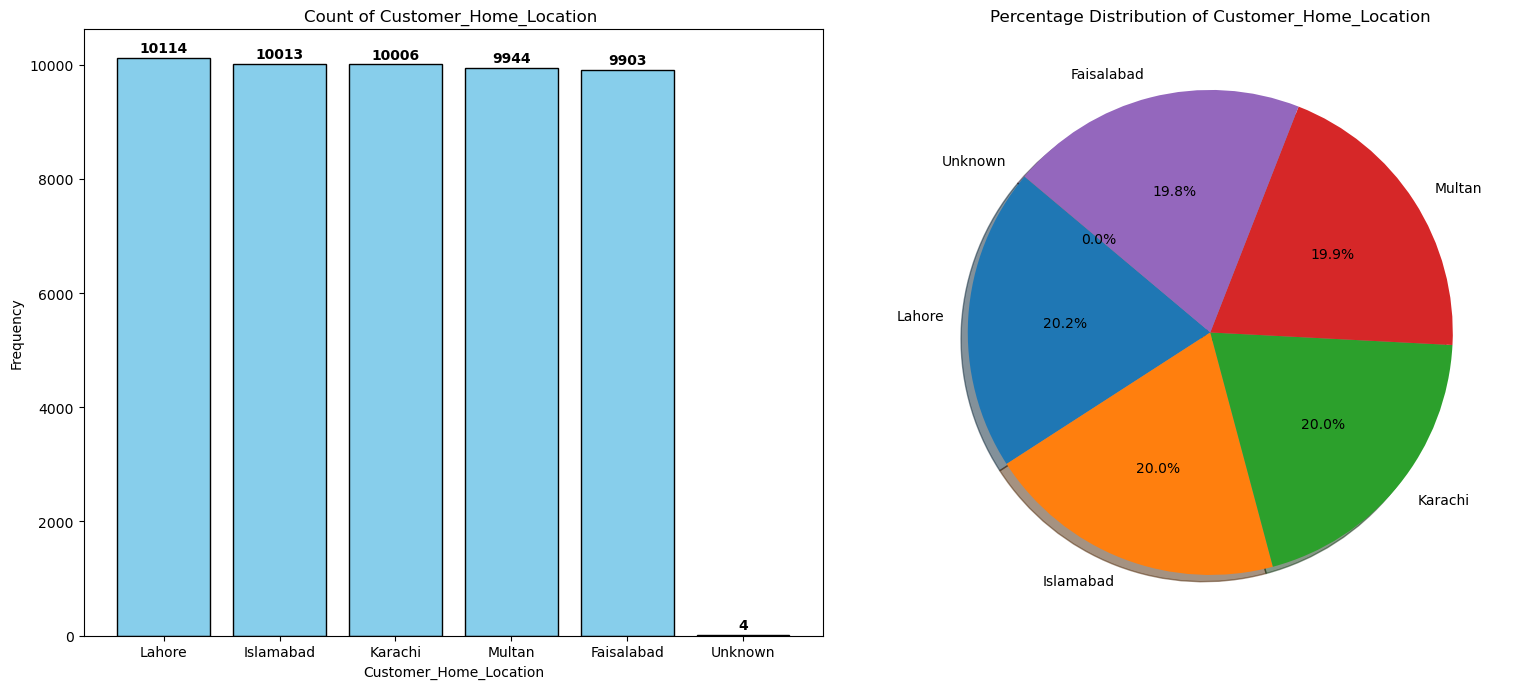

In [203]:
counts = banking_data_process['Customer_Home_Location'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Customer_Home_Location ')
ax[0].set_xlabel('Customer_Home_Location')
ax[0].set_ylabel('Frequency')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Customer_Home_Location')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Customer_Home_Location` includes 5 types with almost evenly distributed given that this is system generated data while Unknown is converted from missing value with minimal

#### 5.2.14 Card_Type

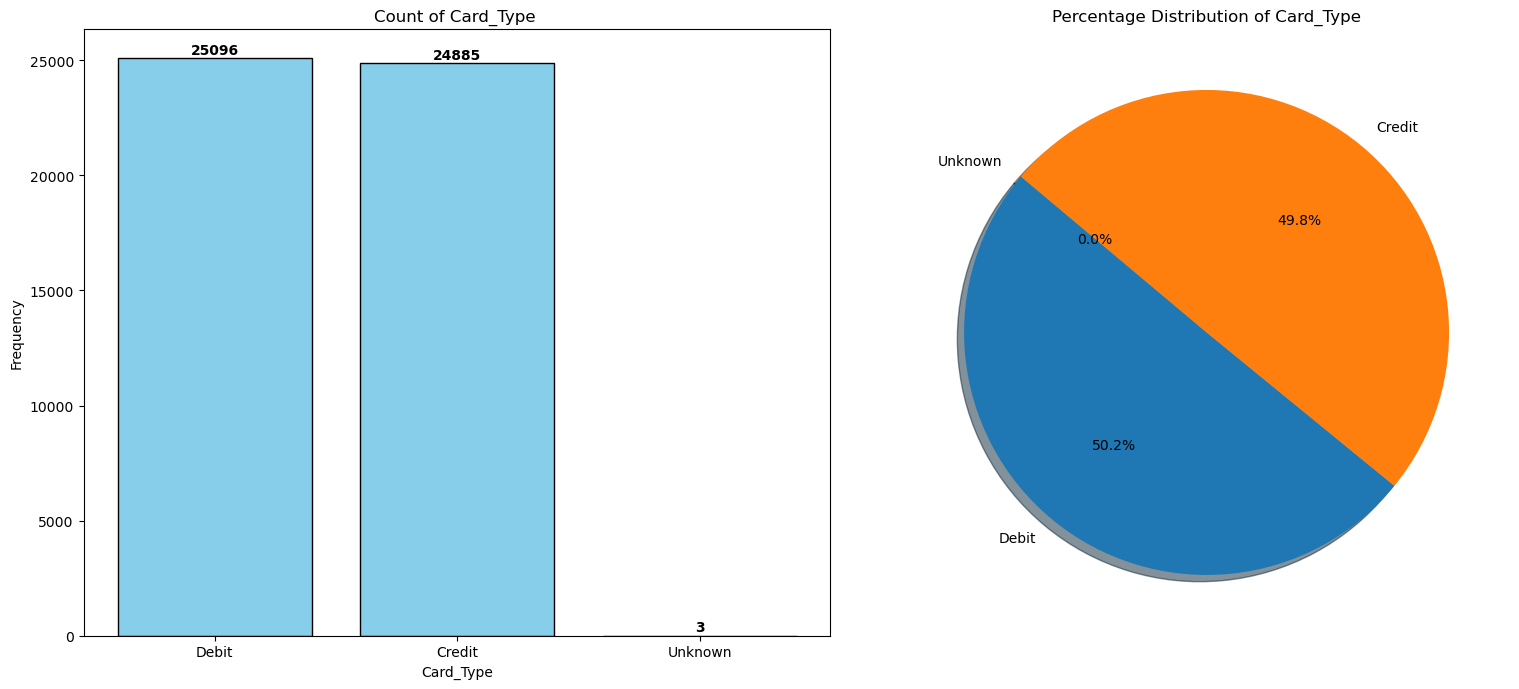

In [204]:
counts = banking_data_process['Card_Type'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Card_Type ')
ax[0].set_xlabel('Card_Type')
ax[0].set_ylabel('Frequency')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Card_Type')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Card_Type` includes 2 types with almost evenly distributed given that this is system generated data while Unknown is converted from missing value with minimal

#### 5.2.15 Is_International_Transaction

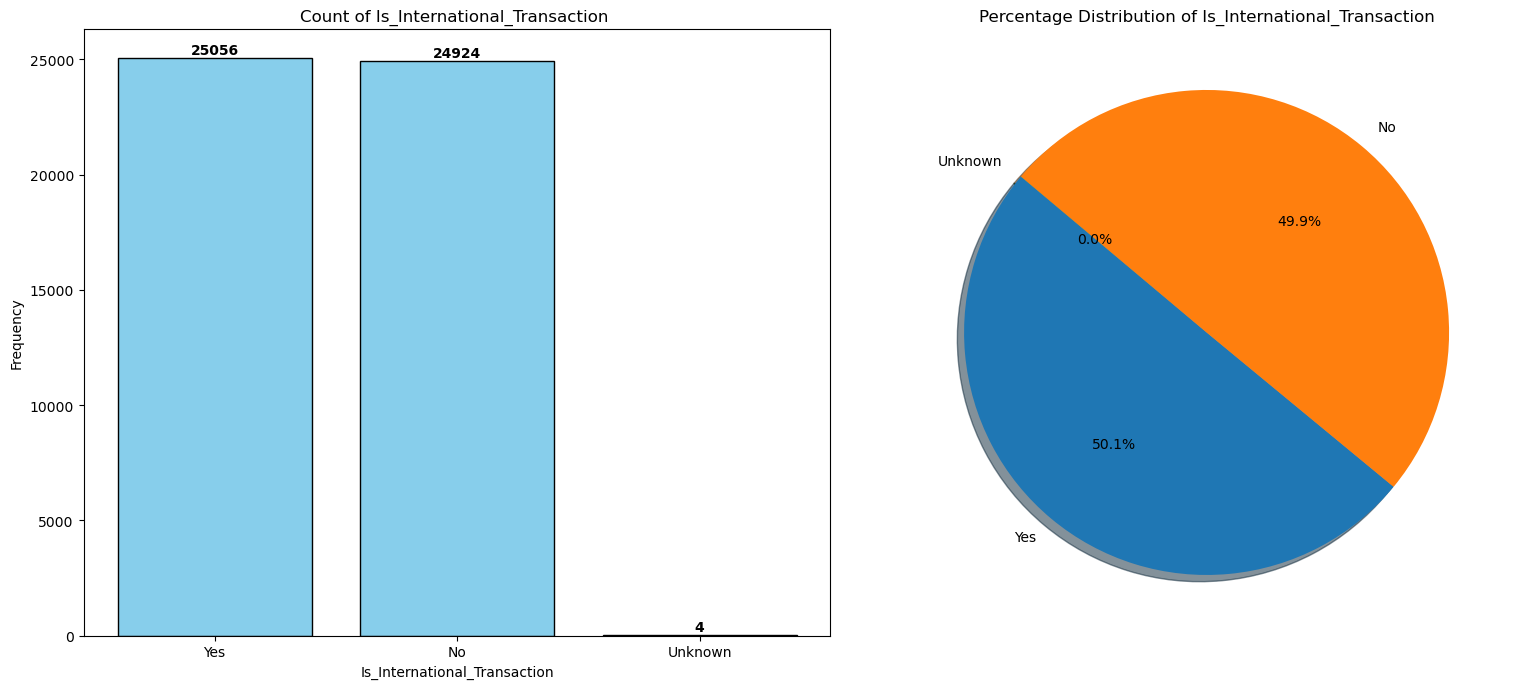

In [205]:
counts = banking_data_process['Is_International_Transaction'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Is_International_Transaction ')
ax[0].set_xlabel('Is_International_Transaction')
ax[0].set_ylabel('Frequency')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Is_International_Transaction')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Is_International_Transaction` includes Yes and No with almost evenly distributed given that this is system generated data while Unknown is converted from missing value with minimal

#### 5.2.16 Is_New_Merchant

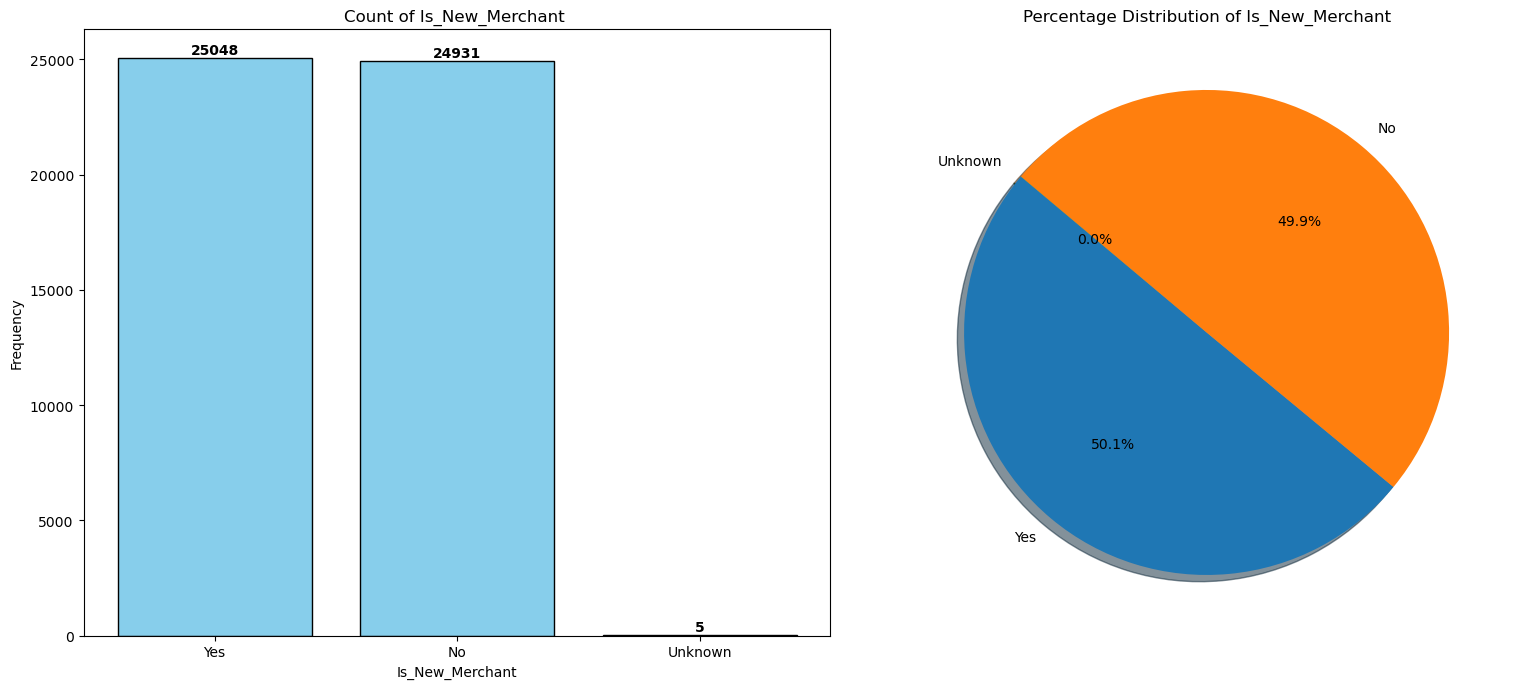

In [206]:
counts = banking_data_process['Is_New_Merchant'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Is_New_Merchant ')
ax[0].set_xlabel('Is_New_Merchant')
ax[0].set_ylabel('Frequency')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Is_New_Merchant')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Is_New_Merchant` includes Yes and No with almost evenly distributed given that this is system generated data while Unknown is converted from missing value with minimal

#### 5.2.17 Unusual_Time_Transaction

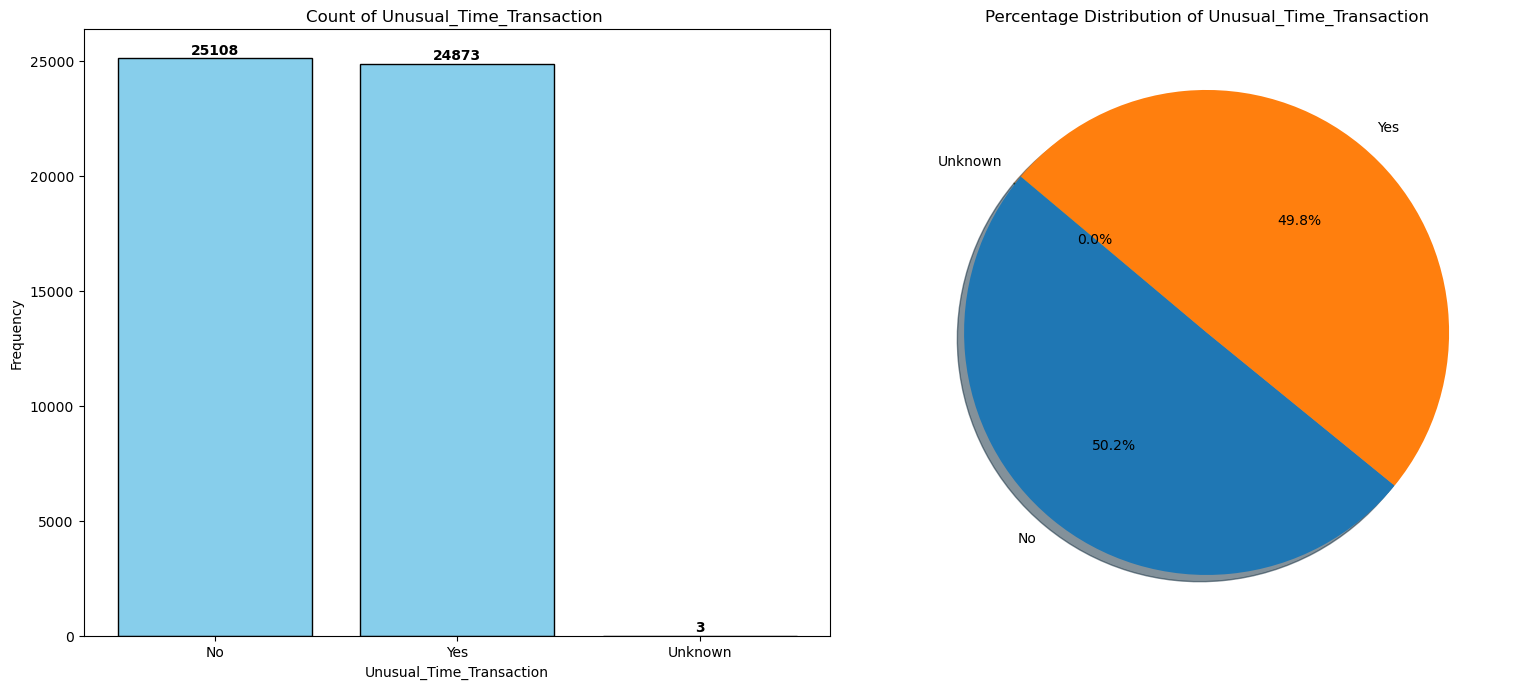

In [207]:
counts = banking_data_process['Unusual_Time_Transaction'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Unusual_Time_Transaction ')
ax[0].set_xlabel('Unusual_Time_Transaction')
ax[0].set_ylabel('Frequency')

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Unusual_Time_Transaction')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Unusual_Time_Transaction` includes Yes and No with almost evenly distributed given that this is system generated data while Unknown is converted from missing value with minimal

#### 5.2.18 Fraud_Label

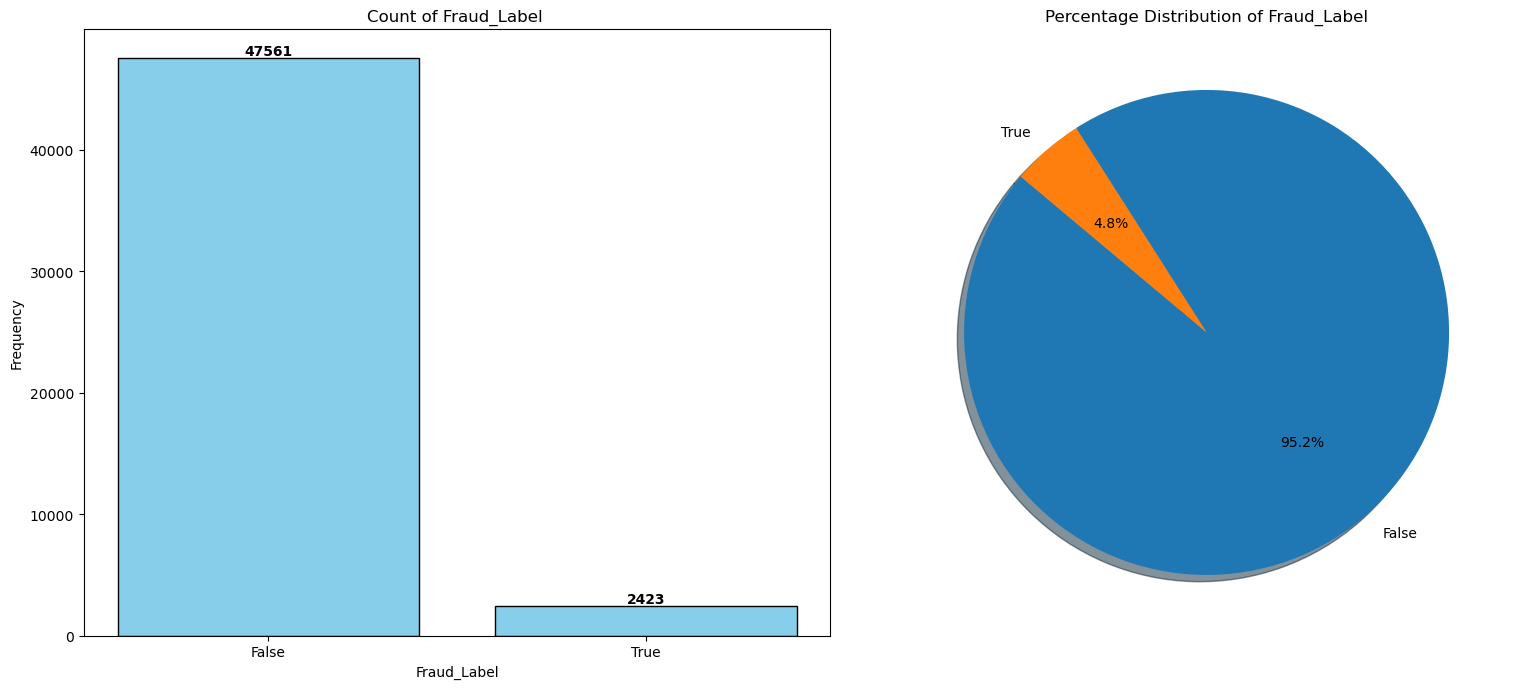

In [208]:
counts = banking_data_process['Fraud_Label'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Bar Chart in terms of Count
bars = ax[0].bar(counts.index, counts.values, color='skyblue', edgecolor='black')
ax[0].set_title('Count of Fraud_Label ')
ax[0].set_xlabel('Fraud_Label')
ax[0].set_ylabel('Frequency')
ax[0].set_xticks(range(len(counts)))
ax[0].set_xticklabels(counts.index.astype(str))

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

# Plot Pie Chart in terms of Percentange
counts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', startangle=140, shadow=True)
ax[1].set_title('Percentage Distribution of Fraud_Label')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

<b>Results</b><br>
Per inspected, `Fraud_Label` shows the class imbalance situation that only 4.8% of data is Fraud transactions while 95.2% of data is Normal transaction.

## 6. Data Modeling 


### 6.1 Feature Selection

#### 6.1.1 Data Set 1 - finanical_data

In [209]:
finanical_data_process.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 26 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   transaction_id               object        
 1   timestamp                    datetime64[ns]
 2   sender_account               object        
 3   receiver_account             object        
 4   amount                       float64       
 5   transaction_type             object        
 6   merchant_category            object        
 7   location                     object        
 8   device_used                  object        
 9   is_fraud                     bool          
 10  fraud_type                   object        
 11  time_since_last_transaction  float64       
 12  spending_deviation_score     float64       
 13  velocity_score               int64         
 14  geo_anomaly_score            float64       
 15  payment_channel              object        
 16  

In [210]:
# Copy one set for feature selection
finanical_data_features = finanical_data_process.copy()

#### 6.1.1.1 Excluding Target label and correesponding columns

`is_fraud` is the target label, which is dropped from the feature selection. Besides, `fraud_type` has values when `is_fraud` is True and hence this dependent field is dropped from feature selection

In [211]:
# Drop the columns for the target label
finanical_data_features = finanical_data_features.drop(columns=['is_fraud'])

In [212]:
# Drop the columns for the value populated based on the target label
finanical_data_features = finanical_data_features.drop(columns=['fraud_type'])

#### 6.1.1.2 Excluding identifiers

Given that there are no generalizable signal for identifiers, below identifiers columms are excluded from feature selection

* `transaction_id`
* `sender_account`
* `receiver_account`
* `ip_address`
* `device_hash`

In [213]:
# Drop the columns for the identifiers
finanical_data_features = finanical_data_features.drop(columns=['transaction_id', 'sender_account','receiver_account', 'ip_address', 'device_hash'])

#### 6.1.1.3 Excluding the timestamp and corresponding columns

Given that `timestamp` has been decomposed into `Hour`, `txn_day_of_week`, `is_weekend` and `is_night`, `timestamp`, `Month` and `Day_of_Week` with diuplicated meaning can be excluded

In [214]:
# Drop the columns for the timestamp since it is decomposed into Hour, txn_day_of_week, is_weekend, is_night and removed duplicated category variables
finanical_data_features = finanical_data_features.drop(columns=['Month', 'Day_of_Week', 'timestamp'])

In [215]:
finanical_data_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 16 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   amount                       float64
 1   transaction_type             object 
 2   merchant_category            object 
 3   location                     object 
 4   device_used                  object 
 5   time_since_last_transaction  float64
 6   spending_deviation_score     float64
 7   velocity_score               int64  
 8   geo_anomaly_score            float64
 9   payment_channel              object 
 10  time_since_last_txn_missing  Int64  
 11  txn_day_of_week              Int64  
 12  is_weekend                   Int64  
 13  Hour                         Int64  
 14  is_night                     Int64  
 15  log_amount                   float64
dtypes: Int64(5), float64(5), int64(1), object(5)
memory usage: 634.2+ MB


<b>Results</b><br>
Per checked, 10 columns are dropped and 16 columns are kept as feature.

#### 6.1.1.4 Turning each category into a single integer column

Each category from categrocal string is converted into a single integer. After that, trees can handle this fine with doing multiple threshold splits to isolate groups, so there is no real accuracy penalty.

In [216]:
# Turn each category into a single integer column
categorical_cols = ["transaction_type", "merchant_category", "location", "device_used", "payment_channel"]
enc = OrdinalEncoder()
finanical_data_features[categorical_cols] = enc.fit_transform(finanical_data_features[categorical_cols])

In [217]:
finanical_data_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 16 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   amount                       float64
 1   transaction_type             float64
 2   merchant_category            float64
 3   location                     float64
 4   device_used                  float64
 5   time_since_last_transaction  float64
 6   spending_deviation_score     float64
 7   velocity_score               int64  
 8   geo_anomaly_score            float64
 9   payment_channel              float64
 10  time_since_last_txn_missing  Int64  
 11  txn_day_of_week              Int64  
 12  is_weekend                   Int64  
 13  Hour                         Int64  
 14  is_night                     Int64  
 15  log_amount                   float64
dtypes: Int64(5), float64(10), int64(1)
memory usage: 634.2 MB


<b>Results</b><br>
`is_fraud` is the target label while below 16 columns are features from Data Set 1 for data modelling

* amount
* transaction_type
* merchant_category
* locatio
* device_used
* time_since_last_transaction
* spending_deviation_score
* velocity_score
* geo_anomaly_score
* payment_channel
* time_since_last_txn_missing
* txn_day_of_week
* is_weekend
* Hour
* is_night
* log_amount

In [218]:
finanical_data_y = finanical_data_process["is_fraud"].astype('Int64')
finanical_data_X = finanical_data_features

#### 6.1.2 Data Set 2 - banking_data

In [219]:
banking_data_process.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49984 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Transaction_ID                         49981 non-null  object        
 1   Customer_ID                            49974 non-null  object        
 2   Transaction_Amount (in Million)        49975 non-null  float64       
 3   Transaction_Type                       49984 non-null  object        
 4   Merchant_ID                            49977 non-null  object        
 5   Merchant_Category                      49984 non-null  object        
 6   Transaction_Location                   49984 non-null  object        
 7   Customer_Home_Location                 49984 non-null  object        
 8   Distance_From_Home                     49982 non-null  float64       
 9   Device_ID                              49975 non-null  object     

In [220]:
# Copy one set for feature selection
banking_data_features = banking_data_process.copy()

#### 6.1.2.1 Excluding Target label

`Fraud_Label` is the target label, which is dropped from the feature selection.

In [221]:
# Drop the columns for the target label
banking_data_features = banking_data_features.drop(columns=['Fraud_Label'])

#### 6.1.2.2 Excluding identifiers

Given that there are no generalizable signal for identifiers, below identifiers columms are excluded from feature selection

* `Transaction_ID`
* `Customer_ID`
* `Merchant_ID`
* `Device_ID`
* `IP_Address`

In [222]:
# Drop the columns for the identifiers
banking_data_features = banking_data_features.drop(columns=['Transaction_ID', 'Customer_ID','Merchant_ID', 'Device_ID', 'IP_Address'])

#### 6.1.2.3 Excluding the Transaction_DateTime and corresponding columns

Given that `timestamp` has been decomposed into `Hour`, `txn_day_of_week`, `is_weekend` and `is_night`, `Transaction_DateTime`, `Month` and `Day_of_Week` with diuplicated meaning can be excluded

In [223]:
# Drop the columns for the timestamp since it is decomposed into Hour, txn_day_of_week, is_weekend, is_night and removed duplicated category variables
banking_data_features = banking_data_features.drop(columns=['Month', 'Day_of_Week', 'Transaction_DateTime'])

#### 6.1.2.4 Turning each category into a single integer column

Each category from categrocal string is converted into a single integer. After that, trees can handle this fine with doing multiple threshold splits to isolate groups, so there is no real accuracy penalty.

In [224]:
# Turn turns each category into a single integer column
categorical_cols = [
    "Transaction_Type", "Merchant_Category", "Transaction_Location",
    "Customer_Home_Location", "Card_Type", "Is_International_Transaction",
    "Is_New_Merchant", "Unusual_Time_Transaction",
]
enc = OrdinalEncoder()
banking_data_features[categorical_cols] = enc.fit_transform(banking_data_features[categorical_cols])

In [225]:
banking_data_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49984 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Transaction_Amount (in Million)        49975 non-null  float64
 1   Transaction_Type                       49984 non-null  float64
 2   Merchant_Category                      49984 non-null  float64
 3   Transaction_Location                   49984 non-null  float64
 4   Customer_Home_Location                 49984 non-null  float64
 5   Distance_From_Home                     49982 non-null  float64
 6   Card_Type                              49984 non-null  float64
 7   Account_Balance (in Million)           49975 non-null  float64
 8   Daily_Transaction_Count                49975 non-null  Int64  
 9   Weekly_Transaction_Count               49979 non-null  Int64  
 10  Avg_Transaction_Amount (in Million)    49975 non-null  float64
 11  Max_Tra

<b>Results</b><br>
`Fraud_Label` is the target label while below 21 columns are features from Data Set 2 for data modelling

* Transaction_Amount (in Million) 
* Transaction_Type
* Merchant_Category                      
* Transaction_Location                   
* Distance_From_Home                     
* Card_Type
* Account_Balance (in Million)           
* Daily_Transaction_Count                
* Weekly_Transaction_Count               
* Avg_Transaction_Amount (in Million)
* Max_Transaction_Last_24h (in Million)
* Is_International_Transaction           
* Is_New_Merchant                        
* Failed_Transaction_Count
* Unusual_Time_Transaction               
* Previous_Fraud_Count
* txn_day_of_week
* is_weekend
* Hour
* is_night                               

In [226]:
banking_data_y = banking_data_process["Fraud_Label"].astype('Int64')
banking_data_X = banking_data_features

### 6.2 Train / Test Split

split_data function splits the features (X) and labels (y) into training and testing subsets using train_test_split.stratify=y. Since both  datasets are highly imbalanced, stratification forces both the training set and testing set to contain the exact same percentage of fraud cases as the original dataset. This prevents the model from missing out on fraud examples during training. Also, 20% of the dataset will be saved for evaluating the model, leaving 80% to train it.

In [227]:
# Train / Test Split
RANDOM_STATE = 42
TEST_SIZE = 0.2

def split_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train):,} rows ({y_train.mean():.4%} fraud) | "
          f"Test: {len(X_test):,} rows ({y_test.mean():.4%} fraud)")
    return X_train, X_test, y_train, y_test

Hyperparameter tuning trains a model dozens or hundreds of times, which can take hours on massive datasets. 'get_tuning_subsample' function extracts a smaller and manageable subset from the main training data. It uses stratify=y_train again to make sure this downsized sample still preserves the correct ratio of fraud transactions, making the tuning results statistically accurate but significantly faster to run.

150,000 rows are target tune_sample_size since the volumne can be covered for both data sets and sufficient enough.

In [228]:
# Hyperparameter Tuning on a stratified subsample for tractability
def get_tuning_subsample(X_train, y_train, tune_sample_size):
    if tune_sample_size >= len(X_train):
        return X_train, y_train
    X_sub, _, y_sub, _ = train_test_split(
        X_train, y_train, train_size=tune_sample_size, stratify=y_train, random_state=RANDOM_STATE
    )
    return X_sub, y_sub

#### 6.2.1 Data Set 1

In [229]:
fd_X_train, fd_X_test, fd_y_train, fd_y_test = split_data(finanical_data_X, finanical_data_y)
# tuning runs on a 150k-row stratified subsample
fd_X_sub, fd_y_sub = get_tuning_subsample(fd_X_train, fd_y_train, 150000)

Train: 4,000,000 rows (3.5910% fraud) | Test: 1,000,000 rows (3.5911% fraud)


#### 6.2.2 Data Set 2

In [230]:
bd_X_train, bd_X_test, bd_y_train, bd_y_test = split_data(banking_data_X, banking_data_y)
# tuning runs on a 150k-row stratified subsample
bd_X_sub, bd_y_sub = get_tuning_subsample(bd_X_train, bd_y_train, 150000)

Train: 39,987 rows (4.8466% fraud) | Test: 9,997 rows (4.8515% fraud)


### 6.3 Train / Test Split

In [231]:
CV_FOLDS = 5
N_TUNE_ITER = 20 
SAMPLE_FRAC = None 

In [232]:
def tune_decision_tree(X_sub, y_sub):
    print("\nTuning Decision Tree (RandomizedSearchCV on subsample)...")
    param_dist = {
        "max_depth": [4, 6, 8, 10, 12, 16, None],
        "min_samples_split": [2, 5, 10, 20, 50],
        "min_samples_leaf": [1, 2, 5, 10, 20],
        "criterion": ["gini", "entropy"],
        "class_weight": ["balanced"],   # handles extreme imbalance
    }
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    search = RandomizedSearchCV(
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        param_distributions=param_dist, n_iter=N_TUNE_ITER, scoring="average_precision",
        cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
    )
    search.fit(X_sub, y_sub)
    print(f"Best DT params: {search.best_params_}  |  best PR-AUC: {search.best_score_:.4f}")
    return search.best_params_

In [233]:
def tune_xgboost(X_sub, y_sub):
    print("\nTuning XGBoost (RandomizedSearchCV on subsample)...")
    scale_pos_weight = (y_sub == 0).sum() / (y_sub == 1).sum()   # handles extreme imbalance
    param_dist = {
        "max_depth": [3, 4, 5, 6, 8],
        "n_estimators": [100, 200, 300, 500],
        "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "min_child_weight": [1, 3, 5],
    }
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    search = RandomizedSearchCV(
        XGBClassifier(
            objective="binary:logistic", eval_metric="aucpr",
            scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
            tree_method="hist", n_jobs=-1,
        ),
        param_distributions=param_dist, n_iter=N_TUNE_ITER, scoring="average_precision",
        cv=cv, random_state=RANDOM_STATE, n_jobs=1, verbose=1,
    )
    search.fit(X_sub, y_sub)
    print(f"Best XGB params: {search.best_params_}  |  best PR-AUC: {search.best_score_:.4f}")
    return search.best_params_, scale_pos_weight

In [234]:
fd_dt_best_params = tune_decision_tree(fd_X_sub, fd_y_sub)
fd_xgb_best_params, fd_scale_pos_weight = tune_xgboost(fd_X_sub, fd_y_sub)


Tuning Decision Tree (RandomizedSearchCV on subsample)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best DT params: {'min_samples_split': 50, 'min_samples_leaf': 5, 'max_depth': 6, 'criterion': 'gini', 'class_weight': 'balanced'}  |  best PR-AUC: 0.0447

Tuning XGBoost (RandomizedSearchCV on subsample)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGB params: {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.8}  |  best PR-AUC: 0.0456


In [235]:
bd_dt_best_params = tune_decision_tree(bd_X_sub, bd_y_sub)
bd_xgb_best_params, bd_scale_pos_weight = tune_xgboost(bd_X_sub, bd_y_sub)


Tuning Decision Tree (RandomizedSearchCV on subsample)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best DT params: {'min_samples_split': 2, 'min_samples_leaf': 5, 'max_depth': 4, 'criterion': 'entropy', 'class_weight': 'balanced'}  |  best PR-AUC: 0.0642

Tuning XGBoost (RandomizedSearchCV on subsample)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGB params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}  |  best PR-AUC: 0.0685


In [236]:
# 5. FINAL FIT ON FULL TRAINING SET + TIMING
# ==============================================================================
def fit_and_time(model, X_train, y_train, X_test):
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0
 
    t0 = time.perf_counter()
    y_pred = model.predict(X_test)
    inference_time = time.perf_counter() - t0
 
    y_proba = model.predict_proba(X_test)[:, 1]
    return model, y_pred, y_proba, train_time, inference_time

In [237]:
# ==============================================================================
# 6. EVALUATION
# ==============================================================================
def evaluate(name, y_test, y_pred, y_proba, train_time, inference_time, n_test):
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
        "train_time_sec": train_time,
        "inference_time_sec": inference_time,
        "inference_ms_per_1000_txn": (inference_time / n_test) * 1000 * 1000,
    }
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["legit", "fraud"], digits=4))
    print(f"ROC-AUC: {metrics['roc_auc']:.4f} | PR-AUC: {metrics['pr_auc']:.4f}")
    print(f"Train time: {train_time:.2f}s | Inference time (full test set): {inference_time:.4f}s")
    return metrics

In [238]:
# -- Final Decision Tree, fit on full training set --
fd_dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE, **fd_dt_best_params)
fd_dt_model, fd_dt_pred, fd_dt_proba, fd_dt_train_t, fd_dt_inf_t = fit_and_time(fd_dt_model, fd_X_train, fd_y_train, fd_X_test)
fd_dt_metrics = evaluate("Decision Tree", fd_y_test, fd_dt_pred, fd_dt_proba, fd_dt_train_t, fd_dt_inf_t, len(fd_X_test))


--- Decision Tree ---
              precision    recall  f1-score   support

       legit     0.9995    0.1877    0.3161    964089
       fraud     0.0437    0.9974    0.0838     35911

    accuracy                         0.2168   1000000
   macro avg     0.5216    0.5925    0.1999   1000000
weighted avg     0.9652    0.2168    0.3077   1000000

ROC-AUC: 0.5932 | PR-AUC: 0.0439
Train time: 40.64s | Inference time (full test set): 0.2070s


In [239]:
# -- Final XGBoost, fit on full training set --
fd_xgb_model = XGBClassifier(
    objective="binary:logistic", eval_metric="aucpr",
    scale_pos_weight=fd_scale_pos_weight, random_state=RANDOM_STATE,
    tree_method="hist", n_jobs=-1, **fd_xgb_best_params,
)
fd_xgb_model, fd_xgb_pred, fd_xgb_proba, fd_xgb_train_t, fd_xgb_inf_t = fit_and_time(fd_xgb_model, fd_X_train, fd_y_train, fd_X_test)
fd_xgb_metrics = evaluate("XGBoost", fd_y_test, fd_xgb_pred, fd_xgb_proba, fd_xgb_train_t, fd_xgb_inf_t, len(fd_X_test))


--- XGBoost ---
              precision    recall  f1-score   support

       legit     1.0000    0.1855    0.3129    964089
       fraud     0.0437    1.0000    0.0838     35911

    accuracy                         0.2147   1000000
   macro avg     0.5219    0.5927    0.1984   1000000
weighted avg     0.9657    0.2147    0.3047   1000000

ROC-AUC: 0.5939 | PR-AUC: 0.0439
Train time: 18.38s | Inference time (full test set): 0.5720s


In [240]:
results_df = pd.DataFrame([fd_dt_metrics, fd_xgb_metrics])
print("\n================ FINAL COMPARISON TABLE ================")
print(results_df.to_string(index=False))


================ FINAL COMPARISON TABLE ================
        model  accuracy  precision   recall       f1  roc_auc   pr_auc  train_time_sec  inference_time_sec  inference_ms_per_1000_txn
Decision Tree  0.216789   0.043736 0.997382 0.083798 0.593193 0.043892       40.641900            0.206987                   0.206987
      XGBoost  0.214745   0.043732 1.000000 0.083799 0.593920 0.043912       18.376293            0.571990                   0.571990


In [241]:
# ==============================================================================
# 7. COMPARISON PLOTS
# ==============================================================================
def plot_comparison(results_df, curves, out_prefix):
    # -- Efficiency vs accuracy bar chart --
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
    axes[0].bar(results_df["model"], results_df["train_time_sec"], color=["#4C72B0", "#DD8452"])
    axes[0].set_title("Training Time (s)")
    axes[0].set_ylabel("seconds")
 
    axes[1].bar(results_df["model"], results_df["inference_time_sec"], color=["#4C72B0", "#DD8452"])
    axes[1].set_title("Inference Time on Test Set (s)")
    axes[1].set_ylabel("seconds")
 
    axes[2].bar(results_df["model"], results_df["pr_auc"], color=["#4C72B0", "#DD8452"])
    axes[2].set_title("PR-AUC (accuracy under imbalance)")
    axes[2].set_ylim(0, 1)
 
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_efficiency_vs_accuracy.png", dpi=150)
    plt.show()
    plt.close()
 
    # -- ROC and PR curves --
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for name, (fpr, tpr, precision, recall) in curves.items():
        axes[0].plot(fpr, tpr, label=name)
        axes[1].plot(recall, precision, label=name)
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
    axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve"); axes[0].legend()
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve"); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"{out_prefix}_roc_pr_curves.png", dpi=150)
    plt.show()
    plt.close()


================ Data Set 1 Results ================


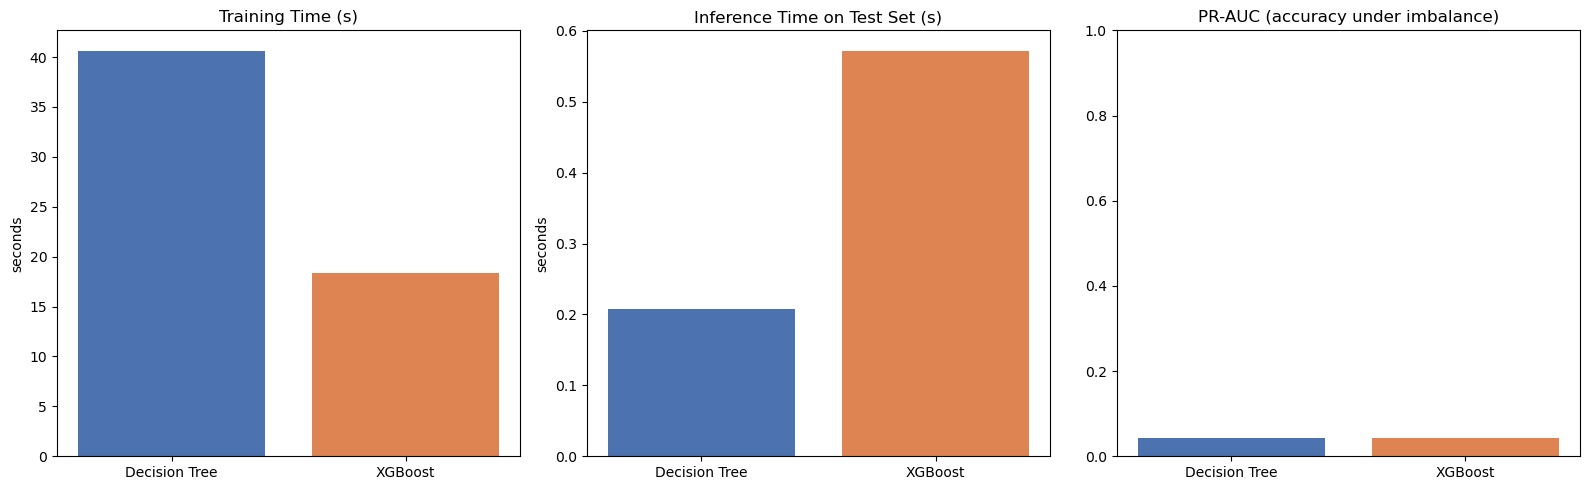

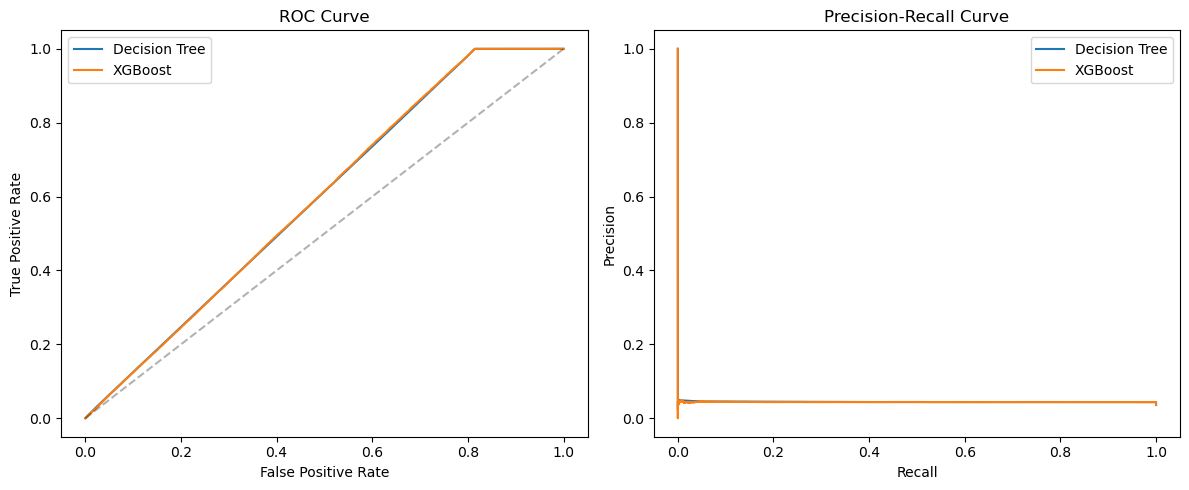

In [242]:
curves = {}
print("\n================ Data Set 1 Results ================")
for name, proba in [("Decision Tree", fd_dt_proba), ("XGBoost", fd_xgb_proba)]:
    fpr, tpr, _ = roc_curve(fd_y_test, proba)
    precision, recall, _ = precision_recall_curve(fd_y_test, proba)
    curves[name] = (fpr, tpr, precision, recall)
plot_comparison(results_df, curves, "fraud_dt_vs_xgb")

In [243]:
# -- Final Decision Tree, fit on full training set --
bd_dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE, **bd_dt_best_params)
bd_dt_model, bd_dt_pred, bd_dt_proba, bd_dt_train_t, bd_dt_inf_t = fit_and_time(bd_dt_model, bd_X_train, bd_y_train, bd_X_test)
bd_dt_metrics = evaluate("Decision Tree", bd_y_test, bd_dt_pred, bd_dt_proba, bd_dt_train_t, bd_dt_inf_t, len(bd_X_test))


--- Decision Tree ---
              precision    recall  f1-score   support

       legit     0.9624    0.5196    0.6748      9512
       fraud     0.0601    0.6021    0.1092       485

    accuracy                         0.5236      9997
   macro avg     0.5112    0.5608    0.3920      9997
weighted avg     0.9186    0.5236    0.6474      9997

ROC-AUC: 0.5906 | PR-AUC: 0.0623
Train time: 0.15s | Inference time (full test set): 0.0133s


In [244]:
# -- Final XGBoost, fit on full training set --
bd_xgb_model = XGBClassifier(
    objective="binary:logistic", eval_metric="aucpr",
    scale_pos_weight=fd_scale_pos_weight, random_state=RANDOM_STATE,
    tree_method="hist", n_jobs=-1, **bd_xgb_best_params,
)
bd_xgb_model, bd_xgb_pred, bd_xgb_proba, bd_xgb_train_t, bd_xgb_inf_t = fit_and_time(bd_xgb_model, bd_X_train, bd_y_train, bd_X_test)
bd_xgb_metrics = evaluate("XGBoost", bd_y_test, bd_xgb_pred, bd_xgb_proba, bd_xgb_train_t, bd_xgb_inf_t, len(bd_X_test))


--- XGBoost ---
              precision    recall  f1-score   support

       legit     0.9754    0.2875    0.4441      9512
       fraud     0.0578    0.8577    0.1084       485

    accuracy                         0.3152      9997
   macro avg     0.5166    0.5726    0.2762      9997
weighted avg     0.9309    0.3152    0.4278      9997

ROC-AUC: 0.5969 | PR-AUC: 0.0681
Train time: 1.88s | Inference time (full test set): 0.0169s


In [245]:
bd_results_df = pd.DataFrame([bd_dt_metrics, bd_xgb_metrics])
print("\n================ FINAL COMPARISON TABLE ================")
print(bd_results_df.to_string(index=False))


================ FINAL COMPARISON TABLE ================
        model  accuracy  precision   recall       f1  roc_auc   pr_auc  train_time_sec  inference_time_sec  inference_ms_per_1000_txn
Decision Tree  0.523557   0.060058 0.602062 0.109220 0.590606 0.062349        0.152692            0.013253                   1.325668
      XGBoost  0.315195   0.057834 0.857732 0.108362 0.596913 0.068109        1.875441            0.016932                   1.693708



================ Data Set 2 Results ================


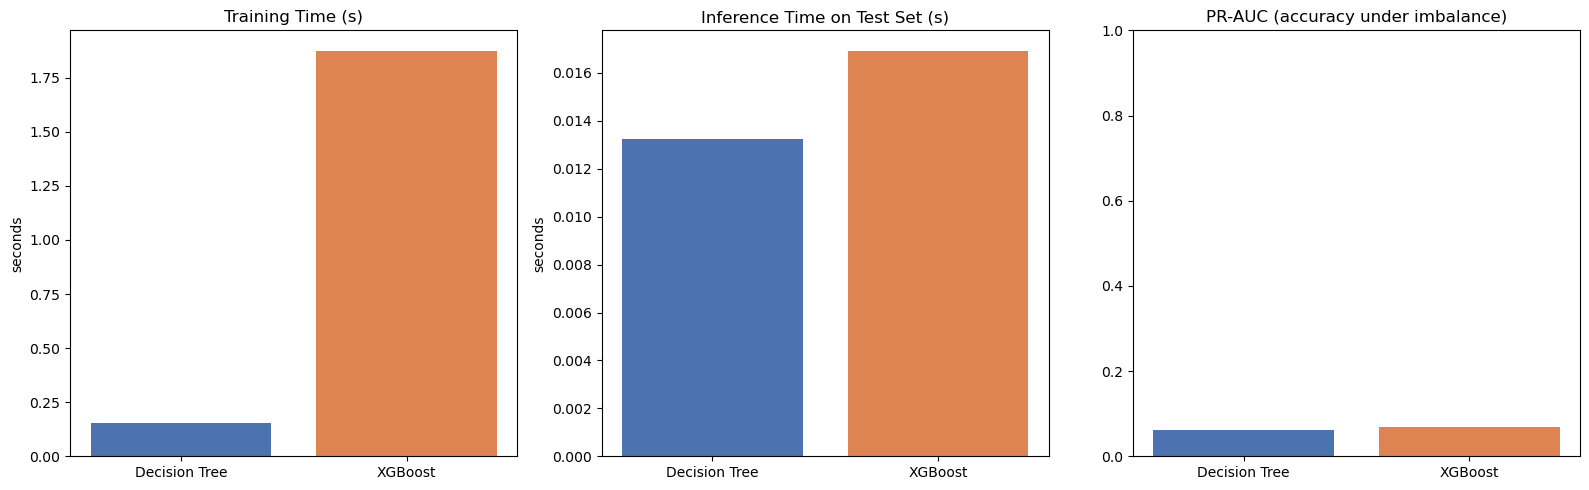

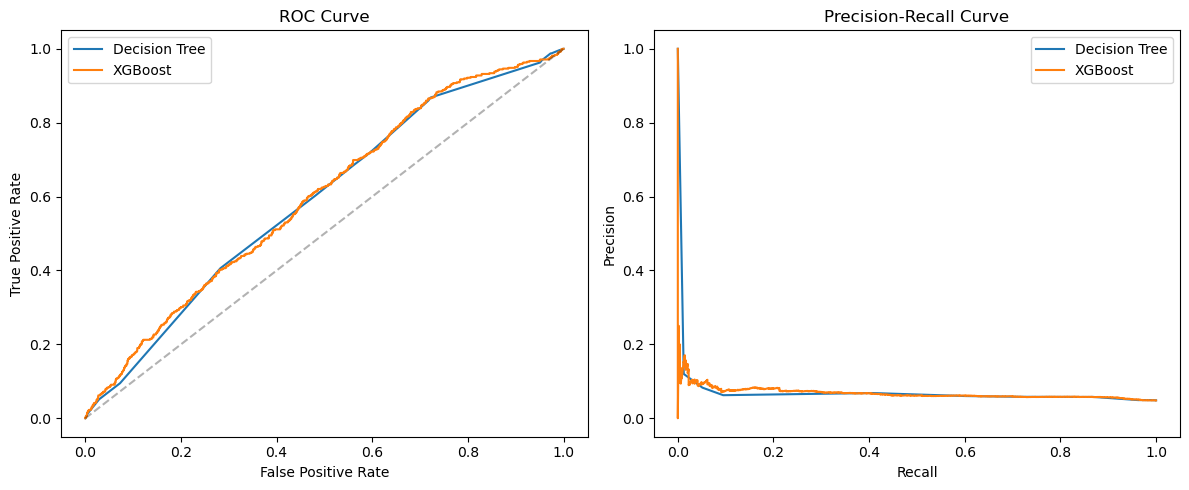

In [246]:
bd_curves = {}
print("\n================ Data Set 2 Results ================")
for name, proba in [("Decision Tree", bd_dt_proba), ("XGBoost", bd_xgb_proba)]:
    fpr, tpr, _ = roc_curve(bd_y_test, proba)
    precision, recall, _ = precision_recall_curve(bd_y_test, proba)
    bd_curves[name] = (fpr, tpr, precision, recall)
plot_comparison(bd_results_df, bd_curves, "fraud_dt_vs_xgb")